# Island fMRI Semester Project  
## Hippocampal modulation by spatial memory quality during post-viewing

**Main hypothesis**  
During post-viewing, hippocampal activity is positively modulated by spatial memory quality. Images whose locations are remembered with lower spatial error and higher confidence should evoke stronger hippocampal responses.

**Goal-relevance hypothesis**  
The positive memory-quality modulation should be stronger for goal-relevant than for goal-irrelevant images.

**Analysis type**  
Item-wise parametric GLM. Each post-viewing image trial receives a continuous memory-quality value. This is not a simple high-memory > low-memory contrast.

**Primary models**
1. All-image memory-quality parametric modulation.
2. Goal-relevance split model:
   - relevant image onset
   - irrelevant image onset
   - relevant memory-quality modulation
   - irrelevant memory-quality modulation

**Main contrasts**
1. all memory-quality > 0  
2. relevant memory-quality > 0  
3. irrelevant memory-quality > 0  
4. relevant memory-quality > irrelevant memory-quality  

**Important caution**  
A significant effect for relevant trials and a non-significant effect for irrelevant trials is not enough to claim goal relevance. The interaction contrast is required.

## 0. Notebook setup and analysis principles
- State hypotheses.
- State primary vs sensitivity analyses.
- State that exclusions and transformations are documented before testing neural effects.

## 1. Imports and paths
- Import scientific Python, neuroimaging, plotting, and utility packages.
- Define base paths.
- Check that all key paths exist.
- Create output directories.

## 2. Data discovery
- Find subjects.
- Find BOLD files.
- Find confounds files.
- Find event files.
- Find behavioral memory files.
- Build subject-level availability table.

## 3. Participant inclusion and QC plan
- Identify subjects with complete data.
- Add known high-motion subjects from prior validation.
- Add known inattentive subjects once confirmed.
- Keep a table separating:
  - missing data exclusion
  - behavioral exclusion
  - motion sensitivity exclusion
  - final primary inclusion

## 4. Behavioral data construction
- One row per subject × image/trial.
- Merge post-viewing events with memory test data.
- Compute spatial error.
- Add confidence and goal relevance.
- Validate image ID matching.
- Validate trial counts.
- Validate relevant/irrelevant balance.

## 5. Behavioral sanity checks
- Spatial error distributions.
- Confidence distributions.
- Confidence vs spatial error.
- Goal relevance vs spatial error.
- Flag suspicious participants.

## 6. Memory-quality variable construction
- spatial_accuracy = -spatial_error
- within-subject z-score spatial accuracy
- within-subject z-score confidence
- memory_quality_raw = z_accuracy + z_confidence
- within-subject z-score final memory quality
- secondary robustness variable: z_accuracy × z_confidence

## 7. Create first-level GLM event files
- All-image model events.
- Goal-relevance model events.
- Check pmods are centered.
- Check relevant + irrelevant = total modeled trials.

## 8. First-level GLM
- fMRIPrep BOLD + confounds.
- Confound cleaning.
- Design matrix creation.
- Model fitting.
- Save design matrices and QC figures.

## 9. First-level contrasts
- all memory-quality positive
- relevant memory-quality positive
- irrelevant memory-quality positive
- relevant > irrelevant memory-quality
- optional accuracy/confidence separate effects

## 10. Group-level ROI analysis
- Hippocampus-first analysis.
- All valid subjects.
- Sensitivity excluding high-motion subjects.
- Corrected and uncorrected summaries.

## 11. Exploratory whole-brain analysis
- Secondary, clearly labeled exploratory.
- Thresholding and multiple-comparison notes.

## 12. Subject-level support and robustness
- Extract subject-level hippocampal contrast values.
- Plot individual values.
- Check outliers.
- Compare full vs sensitivity sample.

## 13. Final interpretation
- Behavioral validity.
- Hippocampal memory-quality modulation.
- Goal-relevance interaction.
- Motion/inattention sensitivity.
- Cautious interpretation.

In [1]:
# ============================================================
# 1. Setup, paths, participant definitions
# ============================================================

from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("default")

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

# ----------------------------
# Project paths
# ----------------------------

PROJECT_ROOT = Path("/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project")

DATA_DIR = PROJECT_ROOT / "data"
BIDS_DIR = DATA_DIR / "bids_ackbar"
FMRIPREP_DIR = DATA_DIR / "fmriprep_output"

RAW_MEMORY_PATH = DATA_DIR / "raw" / "final_merged_data.csv"

ANALYSIS_NAME = "memory_quality_post_viewing_parametric"

OUT_DIR = DATA_DIR / "processed" / "glm" / ANALYSIS_NAME
EVENTS_OUT_DIR = DATA_DIR / "preprocessed" / "events_memory_quality_post_viewing_parametric"

FIG_DIR = OUT_DIR / "figures"
TABLE_DIR = OUT_DIR / "tables"
QC_DIR = OUT_DIR / "qc"

for path in [OUT_DIR, EVENTS_OUT_DIR, FIG_DIR, TABLE_DIR, QC_DIR]:
    path.mkdir(parents=True, exist_ok=True)

required_paths = {
    "PROJECT_ROOT": PROJECT_ROOT,
    "DATA_DIR": DATA_DIR,
    "BIDS_DIR": BIDS_DIR,
    "FMRIPREP_DIR": FMRIPREP_DIR,
    "RAW_MEMORY_PATH": RAW_MEMORY_PATH,
}

for name, path in required_paths.items():
    print(f"{name:18s} {path.exists()}  {path}")

if not all(path.exists() for path in required_paths.values()):
    raise FileNotFoundError("At least one required path is missing.")

# ----------------------------
# Post-viewing fMRI target
# ----------------------------

POST_SESSION = "ses-05"
POST_TASK = "viewing"
POST_RUN = "01"
BOLD_SPACE = "MNI152NLin2009cAsym"

# ----------------------------
# Participant definitions
# ----------------------------

previous_student_subjects = [
    "sub-P10", "sub-P12", "sub-P13", "sub-P14", "sub-P15",
    "sub-P16", "sub-P17", "sub-P18", "sub-P19",
    "sub-P21", "sub-P22", "sub-P23", "sub-P25",
    "sub-P27", "sub-P31", "sub-P34", "sub-P35",
    "sub-P36", "sub-P37", "sub-P41", "sub-P42",
    "sub-P43", "sub-P44", "sub-P45", "sub-P47",
    "sub-P48", "sub-P50", "sub-P51",
]

excluded_inattentive = {
    "sub-P20": "Likely asleep or severely disengaged during POST: 35.9% non-responses, low accuracy.",
    "sub-P49": "Likely asleep during PRE: 42.7% non-responses; POST still elevated at 16.7%.",
}

known_missing_or_incomplete = {
    "sub-P26": "Missing post-viewing event file according to previous project notes.",
    "sub-P30": "Incomplete data according to previous project notes.",
}

caution_subjects = {
    "sub-P37": "High PRE non-response, 25.3%, and no POST data reported in previous notes.",
}

known_high_motion = {
    "sub-P19": "High-motion subject from previous GLM validation.",
    "sub-P21": "High-motion subject from previous GLM validation.",
}

def natural_sort_key(text):
    return [
        int(part) if part.isdigit() else part.lower()
        for part in re.split(r"(\d+)", str(text))
    ]

def expected_post_events_file(subject):
    return (
        BIDS_DIR
        / subject
        / POST_SESSION
        / "func"
        / f"{subject}_{POST_SESSION}_task-{POST_TASK}_run-{POST_RUN}_events.tsv"
    )

def expected_post_bold_file(subject, space=BOLD_SPACE):
    return (
        FMRIPREP_DIR
        / subject
        / POST_SESSION
        / "func"
        / f"{subject}_{POST_SESSION}_task-{POST_TASK}_run-{POST_RUN}_space-{space}_desc-preproc_bold.nii.gz"
    )

def expected_post_confounds_file(subject):
    return (
        FMRIPREP_DIR
        / subject
        / POST_SESSION
        / "func"
        / f"{subject}_{POST_SESSION}_task-{POST_TASK}_run-{POST_RUN}_desc-confounds_timeseries.tsv"
    )

print("\nParticipant definitions:")
print("Previous-student reference subjects:", len(previous_student_subjects))
print("Excluded inattentive:", list(excluded_inattentive))
print("Known missing/incomplete:", list(known_missing_or_incomplete))
print("Caution subjects:", list(caution_subjects))
print("High-motion sensitivity subjects:", list(known_high_motion))



PROJECT_ROOT       True  /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project
DATA_DIR           True  /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data
BIDS_DIR           True  /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/bids_ackbar
FMRIPREP_DIR       True  /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output
RAW_MEMORY_PATH    True  /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/raw/final_merged_data.csv

Participant definitions:
Previous-student reference subjects: 28
Excluded inattentive: ['sub-P20', 'sub-P49']
Known missing/incomplete: ['sub-P26', 'sub-P30']
Caution subjects: ['sub-P37']
High-motion sensitivity subjects: ['sub-P19', 'sub-P21']


In [2]:
# ============================================================
# 2. Data preprocessing and preparation
# ============================================================

# ------------------------------------------------------------
# 2.1 Participant post-viewing data availability
# ------------------------------------------------------------

candidate_subjects = sorted(
    set(previous_student_subjects)
    | set(excluded_inattentive)
    | set(known_missing_or_incomplete)
    | set(caution_subjects)
    | set(known_high_motion),
    key=natural_sort_key,
)

availability_rows = []

for subject in candidate_subjects:
    events_file = expected_post_events_file(subject)
    bold_file = expected_post_bold_file(subject)
    confounds_file = expected_post_confounds_file(subject)

    availability_rows.append({
        "subject": subject,
        "in_previous_student_list": subject in previous_student_subjects,
        "post_events_file": events_file,
        "has_post_events": events_file.exists(),
        "post_bold_file": bold_file,
        "has_post_bold": bold_file.exists(),
        "post_confounds_file": confounds_file,
        "has_post_confounds": confounds_file.exists(),
        "excluded_inattentive": subject in excluded_inattentive,
        "known_missing_or_incomplete": subject in known_missing_or_incomplete,
        "caution_subject": subject in caution_subjects,
        "known_high_motion": subject in known_high_motion,
    })

availability = pd.DataFrame(availability_rows)

availability["has_required_post_data"] = (
    availability["has_post_events"]
    & availability["has_post_bold"]
    & availability["has_post_confounds"]
)

availability["primary_include_before_behavior_qc"] = (
    availability["has_required_post_data"]
    & ~availability["excluded_inattentive"]
    & ~availability["known_missing_or_incomplete"]
)

availability["sensitivity_include_no_high_motion"] = (
    availability["primary_include_before_behavior_qc"]
    & ~availability["known_high_motion"]
)

availability_path = TABLE_DIR / "participant_post_viewing_data_availability.csv"
availability.to_csv(availability_path, index=False)

print("Participant availability:")
print("Candidate subjects:", len(availability))
print("With required post data:", int(availability["has_required_post_data"].sum()))
print("Primary include before behavior QC:", int(availability["primary_include_before_behavior_qc"].sum()))
print(
    "Sensitivity include excluding high motion:",
    int(availability["sensitivity_include_no_high_motion"].sum())
)

display(
    availability[
        [
            "subject",
            "has_post_events",
            "has_post_bold",
            "has_post_confounds",
            "primary_include_before_behavior_qc",
            "sensitivity_include_no_high_motion",
            "excluded_inattentive",
            "known_missing_or_incomplete",
            "caution_subject",
            "known_high_motion",
        ]
    ]
)

# ------------------------------------------------------------
# 2.2 Load post-viewing events
# ------------------------------------------------------------

subjects_with_post_data = availability.loc[
    availability["has_required_post_data"],
    "subject"
].tolist()

post_event_tables = []

for subject in subjects_with_post_data:
    events_file = expected_post_events_file(subject)
    events = pd.read_csv(events_file, sep="\t")
    events["subject"] = subject
    events["source_file"] = str(events_file)
    post_event_tables.append(events)

post_events = pd.concat(post_event_tables, ignore_index=True)

post_events["image_file"] = post_events["event"].astype(str)
post_events["is_old_image"] = post_events["image_file"].str.endswith("_old.jpg")
post_events["is_new_image"] = post_events["image_file"].str.endswith("_new.jpg")

post_event_summary = (
    post_events
    .groupby("subject")
    .agg(
        n_events=("image_file", "count"),
        n_old=("is_old_image", "sum"),
        n_new=("is_new_image", "sum"),
        n_other=(
            "image_file",
            lambda x: (
                ~x.str.endswith("_old.jpg")
                & ~x.str.endswith("_new.jpg")
            ).sum()
        ),
    )
    .reset_index()
)

print("\nPost-viewing event summary:")
display(post_event_summary)

assert post_event_summary["n_events"].eq(384).all(), (
    "Unexpected number of post-viewing events for at least one subject."
)
assert post_event_summary["n_old"].eq(288).all(), (
    "Unexpected number of old-image events for at least one subject."
)
assert post_event_summary["n_new"].eq(96).all(), (
    "Unexpected number of new-image events for at least one subject."
)
assert post_event_summary["n_other"].eq(0).all(), (
    "Some post-viewing events are neither old nor new images."
)

old_post_events = post_events.loc[post_events["is_old_image"]].copy()

old_post_events = old_post_events.merge(
    availability[
        [
            "subject",
            "primary_include_before_behavior_qc",
            "sensitivity_include_no_high_motion",
            "excluded_inattentive",
            "known_missing_or_incomplete",
            "caution_subject",
            "known_high_motion",
        ]
    ],
    on="subject",
    how="left",
    validate="many_to_one",
)

# ------------------------------------------------------------
# 2.3 Parse final_merged_data.csv into memory trials
# ------------------------------------------------------------

raw_memory = pd.read_csv(RAW_MEMORY_PATH)

memory_events = raw_memory.loc[
    raw_memory["V3"].astype(str).str.contains(r"\[ S3_Memory \]", na=False)
].copy()

memory_events = memory_events.rename(
    columns={
        "Participant": "participant_id",
        "V1": "timestamp",
        "V2": "event_index",
        "V3": "event_type",
        "V4": "value_1",
        "V5": "value_2",
        "V6": "value_3",
        "V7": "value_4",
        "V8": "value_5",
        "V9": "value_6",
        "V10": "value_7",
    }
)

memory_events["subject"] = "sub-" + memory_events["participant_id"].astype(str)

trial_start_mask = memory_events["event_type"].eq("[ S3_Memory ] Stimuli Presentation")
trial_starts = memory_events.loc[trial_start_mask].copy()

trials = []

for participant_id, starts_sub in trial_starts.groupby("participant_id"):
    starts_sub = starts_sub.sort_values("event_index").copy()

    for i, (_, start_row) in enumerate(starts_sub.iterrows()):
        subject = start_row["subject"]
        start_index = start_row["event_index"]
        end_index = (
            starts_sub.iloc[i + 1]["event_index"]
            if i < len(starts_sub) - 1
            else np.inf
        )

        window = memory_events.loc[
            (memory_events["participant_id"] == participant_id)
            & (memory_events["event_index"] >= start_index)
            & (memory_events["event_index"] < end_index)
        ].copy()

        def first_value(event_type, column="value_1"):
            vals = window.loc[window["event_type"].eq(event_type), column].dropna()
            return vals.iloc[0] if len(vals) > 0 else np.nan

        placed_rows = window.loc[
            window["event_type"].eq("[ S3_Memory ] Stimuli Placed")
        ]

        if len(placed_rows) > 0:
            placed_row = placed_rows.iloc[0]
            checkpoint_raw = placed_row["value_4"]
            checkpoint_pos_raw = placed_row["value_5"]
            stimulus_pos_raw = placed_row["value_6"]
            distance_raw = placed_row["value_7"]
        else:
            checkpoint_raw = np.nan
            checkpoint_pos_raw = np.nan
            stimulus_pos_raw = np.nan
            distance_raw = np.nan

        trials.append({
            "subject": subject,
            "participant_id": participant_id,
            "stimulus_id": start_row["value_1"],
            "stim_cat_raw": start_row["value_2"],
            "relevance_raw": start_row["value_3"],
            "recognition_response": first_value("[ S3_Memory ] Memory Quiz Response"),
            "placement_confidence": first_value("[ S3_Memory ] Memory Placement confidence"),
            "temporal_response": first_value("[ S3_Memory ] Memory Quiz2 Response"),
            "temporal_confidence": first_value("[ S3_Memory ] Memory Quiz2 confidence"),
            "checkpoint_raw": checkpoint_raw,
            "checkpoint_pos_raw": checkpoint_pos_raw,
            "stimulus_pos_raw": stimulus_pos_raw,
            "distance_raw": distance_raw,
            "n_rows_in_trial_window": len(window),
        })

memory_trials_raw = pd.DataFrame(trials)

assert memory_trials_raw.groupby("subject").size().eq(64).all(), (
    "Not all subjects have 64 memory trials."
)

# ------------------------------------------------------------
# 2.4 Parse coordinates and build behavioral table
# ------------------------------------------------------------

def extract_number(text):
    if pd.isna(text):
        return np.nan

    match = re.search(r"[-+]?\d*\.?\d+", str(text))
    return float(match.group(0)) if match else np.nan


def extract_xyz(text):
    if pd.isna(text):
        return (np.nan, np.nan, np.nan)

    nums = re.findall(r"[-+]?\d*\.?\d+", str(text))
    nums = [float(x) for x in nums]

    if len(nums) >= 3:
        return tuple(nums[:3])

    return (np.nan, np.nan, np.nan)


memory_trials = memory_trials_raw.copy()

memory_trials["is_old_image"] = (
    memory_trials["stimulus_id"].astype(str).str.endswith("_old")
)
memory_trials["is_memo_image"] = (
    memory_trials["stimulus_id"].astype(str).str.endswith("_memo")
)

memory_trials["image_file"] = np.where(
    memory_trials["is_old_image"],
    memory_trials["stimulus_id"].astype(str) + ".jpg",
    np.nan,
)

memory_trials["recognized_seen"] = memory_trials["recognition_response"].eq("seen")

memory_trials["goal_relevant"] = memory_trials["relevance_raw"].eq("re")
memory_trials["goal_irrelevant"] = memory_trials["relevance_raw"].eq("nr")

memory_trials["spatial_error"] = memory_trials["distance_raw"].apply(extract_number)
memory_trials["confidence"] = pd.to_numeric(
    memory_trials["placement_confidence"],
    errors="coerce",
)
memory_trials["temporal_confidence"] = pd.to_numeric(
    memory_trials["temporal_confidence"],
    errors="coerce",
)

memory_trials["checkpoint"] = memory_trials["checkpoint_raw"].apply(extract_number)

checkpoint_xyz = memory_trials["checkpoint_pos_raw"].apply(extract_xyz)
recalled_xyz = memory_trials["stimulus_pos_raw"].apply(extract_xyz)

memory_trials[["checkpoint_x", "checkpoint_y", "checkpoint_z"]] = pd.DataFrame(
    checkpoint_xyz.tolist(),
    index=memory_trials.index,
)

memory_trials[["recalled_x", "recalled_y", "recalled_z"]] = pd.DataFrame(
    recalled_xyz.tolist(),
    index=memory_trials.index,
)

behav = memory_trials.loc[
    memory_trials["is_old_image"] & memory_trials["recognized_seen"]
].copy()

behav["spatial_accuracy"] = -behav["spatial_error"]

behav_cols = [
    "subject",
    "participant_id",
    "stimulus_id",
    "image_file",
    "stim_cat_raw",
    "relevance_raw",
    "goal_relevant",
    "goal_irrelevant",
    "recognition_response",
    "recognized_seen",
    "temporal_response",
    "spatial_error",
    "spatial_accuracy",
    "confidence",
    "temporal_confidence",
    "checkpoint",
    "checkpoint_x",
    "checkpoint_y",
    "checkpoint_z",
    "recalled_x",
    "recalled_y",
    "recalled_z",
]

behav = behav[behav_cols].copy()

behav = behav.merge(
    availability[
        [
            "subject",
            "has_required_post_data",
            "primary_include_before_behavior_qc",
            "sensitivity_include_no_high_motion",
            "excluded_inattentive",
            "known_missing_or_incomplete",
            "caution_subject",
            "known_high_motion",
        ]
    ],
    on="subject",
    how="left",
    validate="many_to_one",
)

flag_cols = [
    "has_required_post_data",
    "primary_include_before_behavior_qc",
    "sensitivity_include_no_high_motion",
    "excluded_inattentive",
    "known_missing_or_incomplete",
    "caution_subject",
    "known_high_motion",
]

for col in flag_cols:
    behav[col] = behav[col].astype("boolean").fillna(False).astype(bool)

behav["complete_behavior"] = (
    behav["spatial_error"].notna()
    & behav["spatial_accuracy"].notna()
    & behav["confidence"].notna()
    & behav["checkpoint"].notna()
    & behav["recalled_x"].notna()
    & behav["recalled_y"].notna()
    & behav["recalled_z"].notna()
)

behav["primary_include"] = (
    behav["primary_include_before_behavior_qc"]
    & behav["complete_behavior"]
)

behav["sensitivity_include"] = (
    behav["sensitivity_include_no_high_motion"]
    & behav["complete_behavior"]
)

# ------------------------------------------------------------
# 2.5 Merge behavioral memory variables onto repeated post-viewing events
# ------------------------------------------------------------

# Rename behavioral sensitivity flag to avoid ambiguity after merging with post-event flags.
behav_for_merge = behav.rename(
    columns={
        "sensitivity_include_no_high_motion": "subject_sensitivity_include_no_high_motion",
        "sensitivity_include": "behavior_sensitivity_include",
    }
)

glm_events_base = old_post_events.merge(
    behav_for_merge,
    on=["subject", "image_file"],
    how="left",
    validate="many_to_one",
    suffixes=("_post", "_behav"),
)

glm_events_base["has_behavior_match"] = glm_events_base["spatial_error"].notna()

glm_events_base["usable_for_primary_glm"] = (
    glm_events_base["primary_include"].fillna(False)
    & glm_events_base["has_behavior_match"]
)

glm_events_base["usable_for_sensitivity_glm"] = (
    glm_events_base["behavior_sensitivity_include"].fillna(False)
    & glm_events_base["has_behavior_match"]
)

# ------------------------------------------------------------
# 2.6 QC summaries and saved outputs
# ------------------------------------------------------------

behavior_qc = (
    behav
    .groupby("subject")
    .agg(
        n_recognized_old=("image_file", "count"),
        n_complete_behavior=("complete_behavior", "sum"),
        n_primary_include=("primary_include", "sum"),
        n_sensitivity_include=("sensitivity_include", "sum"),
        n_relevant=("goal_relevant", "sum"),
        n_irrelevant=("goal_irrelevant", "sum"),
        n_missing_spatial_error=("spatial_error", lambda x: x.isna().sum()),
        n_missing_confidence=("confidence", lambda x: x.isna().sum()),
        mean_spatial_error=("spatial_error", "mean"),
        median_spatial_error=("spatial_error", "median"),
        mean_confidence=("confidence", "mean"),
        sd_confidence=("confidence", "std"),
        has_required_post_data=("has_required_post_data", "first"),
        primary_include_before_behavior_qc=("primary_include_before_behavior_qc", "first"),
        excluded_inattentive=("excluded_inattentive", "first"),
        known_missing_or_incomplete=("known_missing_or_incomplete", "first"),
        caution_subject=("caution_subject", "first"),
        known_high_motion=("known_high_motion", "first"),
    )
    .reset_index()
)

post_match_qc = (
    glm_events_base
    .groupby("subject")
    .agg(
        n_old_post_events=("image_file", "count"),
        n_with_behavior_match=("has_behavior_match", "sum"),
        n_usable_primary_events=("usable_for_primary_glm", "sum"),
        n_usable_sensitivity_events=("usable_for_sensitivity_glm", "sum"),
    )
    .reset_index()
)

behavior_qc_path = TABLE_DIR / "behavior_qc_from_raw_logs.csv"
post_match_qc_path = TABLE_DIR / "post_event_behavior_match_qc.csv"
behav_path = TABLE_DIR / "behavior_item_level_from_raw_logs.csv"
glm_events_base_path = TABLE_DIR / "post_events_with_behavior_memory_quality_base.csv"

behavior_qc.to_csv(behavior_qc_path, index=False)
post_match_qc.to_csv(post_match_qc_path, index=False)
behav.to_csv(behav_path, index=False)
glm_events_base.to_csv(glm_events_base_path, index=False)

print("\nBehavioral reconstruction summary:")
print("Raw memory trials:", len(memory_trials_raw))
print("Subjects in raw memory trials:", memory_trials_raw["subject"].nunique())
print("Old recognized behavioral rows:", len(behav))
print("Complete behavioral rows:", int(behav["complete_behavior"].sum()))
print("Primary behavioral rows:", int(behav["primary_include"].sum()))
print("Sensitivity behavioral rows:", int(behav["sensitivity_include"].sum()))

print("\nPost-event / behavior merge summary:")
print("Old post-viewing events:", len(old_post_events))
print("Events with behavior match:", int(glm_events_base["has_behavior_match"].sum()))
print("Usable primary GLM events:", int(glm_events_base["usable_for_primary_glm"].sum()))
print("Usable sensitivity GLM events:", int(glm_events_base["usable_for_sensitivity_glm"].sum()))

print("\nBehavior QC by subject:")
display(behavior_qc)

print("\nPost-event behavior-match QC:")
display(post_match_qc)

print("\nSaved:")
print(behavior_qc_path)
print(post_match_qc_path)
print(behav_path)
print(glm_events_base_path)

Participant availability:
Candidate subjects: 32
With required post data: 31
Primary include before behavior QC: 28
Sensitivity include excluding high motion: 26


,subject,has_post_events,has_post_bold,has_post_confounds,primary_include_before_behavior_qc,sensitivity_include_no_high_motion,excluded_inattentive,known_missing_or_incomplete,caution_subject,known_high_motion
0,sub-P10,True,True,True,True,True,False,False,False,False
1,sub-P12,True,True,True,True,True,False,False,False,False
2,sub-P13,True,True,True,True,True,False,False,False,False
3,sub-P14,True,True,True,True,True,False,False,False,False
4,sub-P15,True,True,True,True,True,False,False,False,False
5,sub-P16,True,True,True,True,True,False,False,False,False
6,sub-P17,True,True,True,True,True,False,False,False,False
7,sub-P18,True,True,True,True,True,False,False,False,False
8,sub-P19,True,True,True,True,False,False,False,False,True
9,sub-P20,True,True,True,False,False,True,False,False,False



Post-viewing event summary:


,subject,n_events,n_old,n_new,n_other
0,sub-P10,384,288,96,0
1,sub-P12,384,288,96,0
2,sub-P13,384,288,96,0
3,sub-P14,384,288,96,0
4,sub-P15,384,288,96,0
5,sub-P16,384,288,96,0
6,sub-P17,384,288,96,0
7,sub-P18,384,288,96,0
8,sub-P19,384,288,96,0
9,sub-P20,384,288,96,0


/tmp/ipykernel_71309/1222014008.py:436: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  glm_events_base["primary_include"].fillna(False)
/tmp/ipykernel_71309/1222014008.py:441: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  glm_events_base["behavior_sensitivity_include"].fillna(False)



Behavioral reconstruction summary:
Raw memory trials: 2240
Subjects in raw memory trials: 35
Old recognized behavioral rows: 1422
Complete behavioral rows: 1422
Primary behavioral rows: 1155
Sensitivity behavioral rows: 1083

Post-event / behavior merge summary:
Old post-viewing events: 8928
Events with behavior match: 7326
Usable primary GLM events: 6630
Usable sensitivity GLM events: 6198

Behavior QC by subject:


,subject,n_recognized_old,n_complete_behavior,n_primary_include,n_sensitivity_include,n_relevant,n_irrelevant,n_missing_spatial_error,n_missing_confidence,mean_spatial_error,median_spatial_error,mean_confidence,sd_confidence,has_required_post_data,primary_include_before_behavior_qc,excluded_inattentive,known_missing_or_incomplete,caution_subject,known_high_motion
0,sub-P10,28,28,28,28,16,12,0,0,395.021510,347.49970,37.571429,23.946590,True,True,False,False,False,False
1,sub-P11,28,28,0,0,13,15,0,0,456.988853,397.38935,32.428571,18.498105,False,False,False,False,False,False
2,sub-P12,30,30,30,30,18,12,0,0,478.744470,427.04845,43.900000,14.798299,True,True,False,False,False,False
3,sub-P13,42,42,42,42,21,21,0,0,448.063057,357.68455,42.642857,16.866508,True,True,False,False,False,False
4,sub-P14,47,47,47,47,23,24,0,0,399.082326,344.93130,13.085106,8.477155,True,True,False,False,False,False
5,sub-P15,48,48,48,48,24,24,0,0,762.113838,560.68050,38.375000,15.576339,True,True,False,False,False,False
6,sub-P16,48,48,48,48,24,24,0,0,438.074465,404.83760,43.104167,14.462335,True,True,False,False,False,False
7,sub-P17,37,37,37,37,19,18,0,0,456.772010,420.95470,18.756757,18.438193,True,True,False,False,False,False
8,sub-P18,44,44,44,44,22,22,0,0,427.457139,409.93525,46.931818,16.568951,True,True,False,False,False,False
9,sub-P19,37,37,37,0,18,19,0,0,489.169799,444.84210,23.081081,10.404001,True,True,False,False,False,True



Post-event behavior-match QC:


,subject,n_old_post_events,n_with_behavior_match,n_usable_primary_events,n_usable_sensitivity_events
0,sub-P10,288,168,168,168
1,sub-P12,288,180,180,180
2,sub-P13,288,252,252,252
3,sub-P14,288,282,282,282
4,sub-P15,288,288,288,288
5,sub-P16,288,246,246,246
6,sub-P17,288,186,186,186
7,sub-P18,288,264,264,264
8,sub-P19,288,222,222,0
9,sub-P20,288,276,0,0



Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/behavior_qc_from_raw_logs.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/post_event_behavior_match_qc.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/behavior_item_level_from_raw_logs.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/post_events_with_behavior_memory_quality_base.csv


In [3]:
# ============================================================
# 3. Check behavioral image matching to post-viewing events
# ============================================================

primary_behav = behav.loc[behav["primary_include"]].copy()

post_old_keys = (
    old_post_events[["subject", "image_file"]]
    .drop_duplicates()
    .assign(present_in_post_viewing=True)
)

behav_post_match = primary_behav.merge(
    post_old_keys,
    on=["subject", "image_file"],
    how="left",
    validate="many_to_one",
)

behav_post_match["present_in_post_viewing"] = (
    behav_post_match["present_in_post_viewing"]
    .fillna(False)
    .astype(bool)
)

missing_from_post = behav_post_match.loc[
    ~behav_post_match["present_in_post_viewing"]
].copy()

match_qc = (
    behav_post_match
    .groupby("subject")
    .agg(
        n_primary_behavior_images=("image_file", "count"),
        n_present_in_post_viewing=("present_in_post_viewing", "sum"),
        n_missing_from_post_viewing=("present_in_post_viewing", lambda x: (~x).sum()),
    )
    .reset_index()
)

print("Primary behavioral image to post-viewing match QC:")
display(match_qc)

print("\nImages present in behavior but missing from post-viewing events:")
display(
    missing_from_post[
        [
            "subject",
            "image_file",
            "goal_relevant",
            "spatial_error",
            "confidence",
            "checkpoint",
            "recalled_x",
            "recalled_y",
            "recalled_z",
        ]
    ].sort_values(["subject", "image_file"])
)

match_qc_path = TABLE_DIR / "behavior_images_missing_from_post_viewing_qc.csv"
missing_from_post_path = TABLE_DIR / "behavior_images_missing_from_post_viewing_rows.csv"

match_qc.to_csv(match_qc_path, index=False)
missing_from_post.to_csv(missing_from_post_path, index=False)

print("\nSaved:")
print(match_qc_path)
print(missing_from_post_path)

Primary behavioral image to post-viewing match QC:


/tmp/ipykernel_71309/2942772963.py:22: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


,subject,n_primary_behavior_images,n_present_in_post_viewing,n_missing_from_post_viewing
0,sub-P10,28,28,0
1,sub-P12,30,30,0
2,sub-P13,42,42,0
3,sub-P14,47,47,0
4,sub-P15,48,48,0
5,sub-P16,48,41,7
6,sub-P17,37,31,6
7,sub-P18,44,44,0
8,sub-P19,37,37,0
9,sub-P21,35,35,0



Images present in behavior but missing from post-viewing events:


,subject,image_file,goal_relevant,spatial_error,confidence,checkpoint,recalled_x,recalled_y,recalled_z
242,sub-P16,food_12_e1_1_r_o_v4_old.jpg,True,136.616400,59,1.0,-280.0,107.1,66.4
224,sub-P16,food_14_e3_10_nr_o_v4_old.jpg,False,415.481400,41,10.0,-139.0,95.2,142.6
216,sub-P16,maya_12_e1_8_r_h_v4_old.jpg,True,359.224000,28,8.0,-111.5,91.3,257.6
209,sub-P16,maya_13_e2_3_nr_h_v4_old.jpg,False,503.910100,61,3.0,292.0,133.6,636.8
220,sub-P16,maya_14_e3_3_nr_h_v4_old.jpg,False,474.583200,36,3.0,-419.4,133.6,129.6
215,sub-P16,pirate_11_e1_14_nr_h_v4_old.jpg,False,67.094780,32,14.0,-228.1,120.7,254.4
231,sub-P16,pirate_12_e3_5_r_h_v4_old.jpg,True,356.630300,42,5.0,-121.2,116.4,235.0
279,sub-P17,food_12_e1_1_r_o_v4_old.jpg,True,251.417500,13,1.0,34.4,107.1,239.8
265,sub-P17,food_14_e3_10_nr_o_v4_old.jpg,False,596.399900,12,10.0,-9.4,95.2,-3.2
258,sub-P17,maya_12_e1_8_r_h_v4_old.jpg,True,474.760300,55,8.0,37.6,91.3,225.2



Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/behavior_images_missing_from_post_viewing_qc.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/behavior_images_missing_from_post_viewing_rows.csv


In [4]:
# ============================================================
# 4. Diagnose version-label mismatches between behavior and post-viewing events
# ============================================================

def strip_version_suffix(image_file):
    """
    Remove version marker before '_old.jpg', e.g.
    food_12_e1_1_r_o_v4_old.jpg -> food_12_e1_1_r_o_old.jpg
    """
    if pd.isna(image_file):
        return np.nan
    return re.sub(r"_v\d+_old\.jpg$", "_old.jpg", str(image_file))

primary_behav = behav.loc[behav["primary_include"]].copy()
primary_behav["image_file_no_version"] = primary_behav["image_file"].apply(strip_version_suffix)

post_old_unique = old_post_events[["subject", "image_file"]].drop_duplicates().copy()
post_old_unique["image_file_no_version"] = post_old_unique["image_file"].apply(strip_version_suffix)

# Exact match
exact_match = primary_behav.merge(
    post_old_unique[["subject", "image_file"]].assign(exact_post_match=True),
    on=["subject", "image_file"],
    how="left",
    validate="many_to_one",
)

exact_match["exact_post_match"] = (
    exact_match["exact_post_match"]
    .fillna(False)
    .astype(bool)
)

# Version-insensitive match
versionless_match = primary_behav.merge(
    post_old_unique[["subject", "image_file_no_version"]].drop_duplicates().assign(versionless_post_match=True),
    on=["subject", "image_file_no_version"],
    how="left",
    validate="many_to_one",
)

versionless_match["versionless_post_match"] = (
    versionless_match["versionless_post_match"]
    .fillna(False)
    .astype(bool)
)

version_qc = primary_behav[["subject", "image_file", "goal_relevant", "spatial_error", "confidence"]].copy()
version_qc["image_file_no_version"] = primary_behav["image_file_no_version"].values
version_qc["exact_post_match"] = exact_match["exact_post_match"].values
version_qc["versionless_post_match"] = versionless_match["versionless_post_match"].values

version_qc["match_type"] = np.select(
    [
        version_qc["exact_post_match"],
        ~version_qc["exact_post_match"] & version_qc["versionless_post_match"],
    ],
    [
        "exact_match",
        "version_only_mismatch",
    ],
    default="no_match_even_without_version",
)

version_summary = (
    version_qc
    .groupby(["subject", "match_type"])
    .size()
    .reset_index(name="n")
    .pivot(index="subject", columns="match_type", values="n")
    .fillna(0)
    .astype(int)
    .reset_index()
)

print("Version-matching summary:")
display(version_summary)

print("\nRows with version-only mismatch:")
display(
    version_qc.loc[
        version_qc["match_type"].eq("version_only_mismatch")
    ].sort_values(["subject", "image_file"])
)

print("\nRows with no match even after removing version:")
display(
    version_qc.loc[
        version_qc["match_type"].eq("no_match_even_without_version")
    ].sort_values(["subject", "image_file"])
)

version_qc_path = TABLE_DIR / "behavior_post_viewing_version_match_qc.csv"
version_qc.to_csv(version_qc_path, index=False)

print("\nSaved:")
print(version_qc_path)

Version-matching summary:


/tmp/ipykernel_71309/723689379.py:30: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/tmp/ipykernel_71309/723689379.py:44: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


match_type,subject,exact_match,no_match_even_without_version
0,sub-P10,28,0
1,sub-P12,30,0
2,sub-P13,42,0
3,sub-P14,47,0
4,sub-P15,48,0
5,sub-P16,41,7
6,sub-P17,31,6
7,sub-P18,44,0
8,sub-P19,37,0
9,sub-P21,35,0



Rows with version-only mismatch:


,subject,image_file,goal_relevant,spatial_error,confidence,image_file_no_version,exact_post_match,versionless_post_match,match_type



Rows with no match even after removing version:


,subject,image_file,goal_relevant,spatial_error,confidence,image_file_no_version,exact_post_match,versionless_post_match,match_type
270,sub-P16,food_12_e1_1_r_o_v4_old.jpg,True,136.616400,59,food_12_e1_1_r_o_old.jpg,False,False,no_match_even_without_version
252,sub-P16,food_14_e3_10_nr_o_v4_old.jpg,False,415.481400,41,food_14_e3_10_nr_o_old.jpg,False,False,no_match_even_without_version
244,sub-P16,maya_12_e1_8_r_h_v4_old.jpg,True,359.224000,28,maya_12_e1_8_r_h_old.jpg,False,False,no_match_even_without_version
237,sub-P16,maya_13_e2_3_nr_h_v4_old.jpg,False,503.910100,61,maya_13_e2_3_nr_h_old.jpg,False,False,no_match_even_without_version
248,sub-P16,maya_14_e3_3_nr_h_v4_old.jpg,False,474.583200,36,maya_14_e3_3_nr_h_old.jpg,False,False,no_match_even_without_version
243,sub-P16,pirate_11_e1_14_nr_h_v4_old.jpg,False,67.094780,32,pirate_11_e1_14_nr_h_old.jpg,False,False,no_match_even_without_version
259,sub-P16,pirate_12_e3_5_r_h_v4_old.jpg,True,356.630300,42,pirate_12_e3_5_r_h_old.jpg,False,False,no_match_even_without_version
307,sub-P17,food_12_e1_1_r_o_v4_old.jpg,True,251.417500,13,food_12_e1_1_r_o_old.jpg,False,False,no_match_even_without_version
293,sub-P17,food_14_e3_10_nr_o_v4_old.jpg,False,596.399900,12,food_14_e3_10_nr_o_old.jpg,False,False,no_match_even_without_version
286,sub-P17,maya_12_e1_8_r_h_v4_old.jpg,True,474.760300,55,maya_12_e1_8_r_h_old.jpg,False,False,no_match_even_without_version



Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/behavior_post_viewing_version_match_qc.csv


Primary matched behavioral images: 1105
Subjects: 28


,subject,n_images
0,sub-P10,28
1,sub-P12,30
2,sub-P13,42
3,sub-P14,47
4,sub-P15,48
5,sub-P16,41
6,sub-P17,31
7,sub-P18,44
8,sub-P19,37
9,sub-P21,35



Coordinate summary:


,checkpoint_x,checkpoint_z,recalled_x,recalled_z
count,1105.000000,1105.000000,1105.000000,1105.000000
mean,-164.993575,192.339276,-179.663620,81.173756
std,247.223444,262.536386,226.383989,406.771216
min,-524.800000,-201.500000,-628.400000,-1395.100000
25%,-402.400000,46.900000,-357.800000,-188.000000
50%,-242.100000,194.400000,-211.900000,66.400000
75%,-10.700000,376.100000,-15.900000,299.800000
max,333.100000,701.500000,478.300000,1328.700000



Plot limits:
xlim: (np.float64(-716.9359999999999), np.float64(566.836))
zlim: (np.float64(-1613.004), np.float64(1546.604))


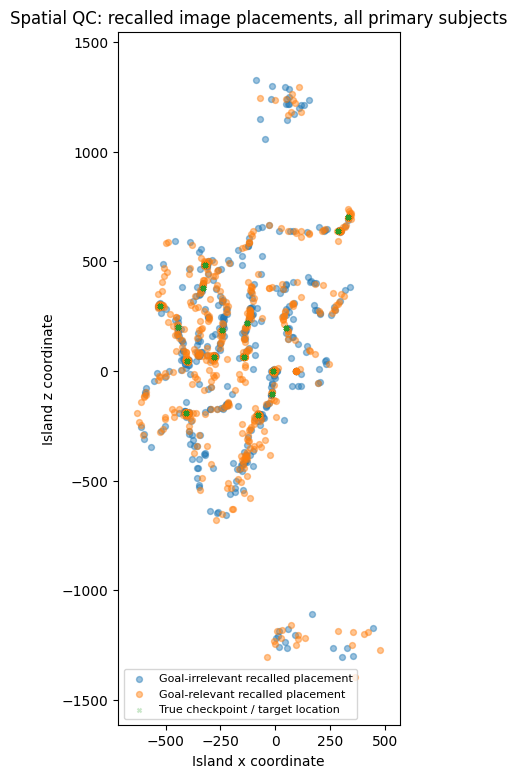

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/spatial_qc_recalled_placements_all_subjects.png
Saved subject-level plots to:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/spatial_qc_by_subject


In [5]:
# ============================================================
# 5. Spatial QC: recalled image placements on island coordinates
# ============================================================

primary_behavior_matched = (
    glm_events_base
    .loc[glm_events_base["usable_for_primary_glm"]]
    [
        [
            "subject",
            "image_file",
            "goal_relevant",
            "goal_irrelevant",
            "spatial_error",
            "confidence",
            "checkpoint_x",
            "checkpoint_z",
            "recalled_x",
            "recalled_z",
        ]
    ]
    .drop_duplicates(["subject", "image_file"])
    .copy()
)

# Make relevance flags proper booleans
primary_behavior_matched["goal_relevant"] = (
    primary_behavior_matched["goal_relevant"]
    .astype("boolean")
    .fillna(False)
    .astype(bool)
)

primary_behavior_matched["goal_irrelevant"] = (
    primary_behavior_matched["goal_irrelevant"]
    .astype("boolean")
    .fillna(False)
    .astype(bool)
)

print("Primary matched behavioral images:", len(primary_behavior_matched))
print("Subjects:", primary_behavior_matched["subject"].nunique())

display(
    primary_behavior_matched
    .groupby("subject")
    .size()
    .reset_index(name="n_images")
)

# ------------------------------------------------------------
# Global coordinate range
# ------------------------------------------------------------

coord_summary = primary_behavior_matched[
    ["checkpoint_x", "checkpoint_z", "recalled_x", "recalled_z"]
].describe()

print("\nCoordinate summary:")
display(coord_summary)

x_min = min(
    primary_behavior_matched["checkpoint_x"].min(),
    primary_behavior_matched["recalled_x"].min(),
)
x_max = max(
    primary_behavior_matched["checkpoint_x"].max(),
    primary_behavior_matched["recalled_x"].max(),
)
z_min = min(
    primary_behavior_matched["checkpoint_z"].min(),
    primary_behavior_matched["recalled_z"].min(),
)
z_max = max(
    primary_behavior_matched["checkpoint_z"].max(),
    primary_behavior_matched["recalled_z"].max(),
)

x_margin = 0.08 * (x_max - x_min)
z_margin = 0.08 * (z_max - z_min)

xlim = (x_min - x_margin, x_max + x_margin)
zlim = (z_min - z_margin, z_max + z_margin)

print("\nPlot limits:")
print("xlim:", xlim)
print("zlim:", zlim)

# ------------------------------------------------------------
# Plot all subjects together
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 9))

relevant = primary_behavior_matched["goal_relevant"].astype(bool)
irrelevant = ~relevant

ax.scatter(
    primary_behavior_matched.loc[irrelevant, "recalled_x"],
    primary_behavior_matched.loc[irrelevant, "recalled_z"],
    s=18,
    alpha=0.45,
    label="Goal-irrelevant recalled placement",
)

ax.scatter(
    primary_behavior_matched.loc[relevant, "recalled_x"],
    primary_behavior_matched.loc[relevant, "recalled_z"],
    s=18,
    alpha=0.45,
    label="Goal-relevant recalled placement",
)

ax.scatter(
    primary_behavior_matched["checkpoint_x"],
    primary_behavior_matched["checkpoint_z"],
    s=8,
    alpha=0.25,
    marker="x",
    label="True checkpoint / target location",
)

ax.set_title("Spatial QC: recalled image placements, all primary subjects")
ax.set_xlabel("Island x coordinate")
ax.set_ylabel("Island z coordinate")
ax.set_xlim(xlim)
ax.set_ylim(zlim)
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="best", fontsize=8)

global_spatial_qc_path = FIG_DIR / "spatial_qc_recalled_placements_all_subjects.png"
fig.savefig(global_spatial_qc_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", global_spatial_qc_path)

# ------------------------------------------------------------
# One plot per subject
# ------------------------------------------------------------

subject_plot_dir = FIG_DIR / "spatial_qc_by_subject"
subject_plot_dir.mkdir(parents=True, exist_ok=True)

for subject, sub_df in primary_behavior_matched.groupby("subject"):
    sub_df = sub_df.copy()
    
    fig, ax = plt.subplots(figsize=(7, 7))
    
    relevant = sub_df["goal_relevant"].astype(bool)
    irrelevant = ~relevant
    
    ax.scatter(
        sub_df.loc[irrelevant, "recalled_x"],
        sub_df.loc[irrelevant, "recalled_z"],
        s=35,
        alpha=0.75,
        label="Goal-irrelevant recalled",
    )
    
    ax.scatter(
        sub_df.loc[relevant, "recalled_x"],
        sub_df.loc[relevant, "recalled_z"],
        s=35,
        alpha=0.75,
        label="Goal-relevant recalled",
    )
    
    ax.scatter(
        sub_df["checkpoint_x"],
        sub_df["checkpoint_z"],
        s=25,
        alpha=0.7,
        marker="x",
        label="Target checkpoint",
    )
    
    for _, row in sub_df.iterrows():
        ax.plot(
            [row["checkpoint_x"], row["recalled_x"]],
            [row["checkpoint_z"], row["recalled_z"]],
            linewidth=0.5,
            alpha=0.25,
        )
    
    ax.set_title(f"{subject}: recalled placements")
    ax.set_xlabel("Island x coordinate")
    ax.set_ylabel("Island z coordinate")
    ax.set_xlim(xlim)
    ax.set_ylim(zlim)
    ax.set_aspect("equal", adjustable="box")
    ax.legend(loc="best", fontsize=7)
    
    out_path = subject_plot_dir / f"{subject}_spatial_qc_recalled_placements.png"
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.close(fig)

print("Saved subject-level plots to:")
print(subject_plot_dir)

In [6]:
# ============================================================
# 6. Spatial QC: remove top/bottom water placements
# ============================================================

# Participants were instructed to place images in the water if they did not remember
# the spatial location. In the coordinate plots, these placements form two clear
# clusters far above and below the island trajectory.

WATER_Z_ABS_THRESHOLD = 1000

spatial_qc = primary_behavior_matched.copy()

spatial_qc["likely_water_placement"] = (
    spatial_qc["recalled_z"].abs() >= WATER_Z_ABS_THRESHOLD
)

spatial_qc["valid_spatial_placement"] = ~spatial_qc["likely_water_placement"]

print("Spatial placement QC:")
print("Primary matched behavioral images:", len(spatial_qc))
print("Likely water placements:", int(spatial_qc["likely_water_placement"].sum()))
print("Valid spatial placements:", int(spatial_qc["valid_spatial_placement"].sum()))

print("\nWater placements by subject:")
water_qc_by_subject = (
    spatial_qc
    .groupby("subject")
    .agg(
        n_matched_images=("image_file", "count"),
        n_water_placements=("likely_water_placement", "sum"),
        n_valid_spatial_placements=("valid_spatial_placement", "sum"),
    )
    .reset_index()
)

display(water_qc_by_subject)

print("\nLikely water-placement trials:")
water_placement_rows = spatial_qc.loc[
    spatial_qc["likely_water_placement"]
].copy()

display(
    water_placement_rows[
        [
            "subject",
            "image_file",
            "goal_relevant",
            "spatial_error",
            "confidence",
            "checkpoint_x",
            "checkpoint_z",
            "recalled_x",
            "recalled_z",
        ]
    ].sort_values(["subject", "image_file"])
)

# Save item-level spatial QC
spatial_qc_path = TABLE_DIR / "spatial_qc_water_placement_flags.csv"
water_placement_rows_path = TABLE_DIR / "spatial_qc_water_placement_rows.csv"

spatial_qc.to_csv(spatial_qc_path, index=False)
water_placement_rows.to_csv(water_placement_rows_path, index=False)

print("\nSaved spatial QC files:")
print(spatial_qc_path)
print(water_placement_rows_path)

Spatial placement QC:
Primary matched behavioral images: 1105
Likely water placements: 60
Valid spatial placements: 1045

Water placements by subject:


,subject,n_matched_images,n_water_placements,n_valid_spatial_placements
0,sub-P10,28,0,28
1,sub-P12,30,0,30
2,sub-P13,42,0,42
3,sub-P14,47,0,47
4,sub-P15,48,13,35
5,sub-P16,41,1,40
6,sub-P17,31,0,31
7,sub-P18,44,1,43
8,sub-P19,37,2,35
9,sub-P21,35,1,34



Likely water-placement trials:


,subject,image_file,goal_relevant,spatial_error,confidence,checkpoint_x,checkpoint_z,recalled_x,recalled_z
1161,sub-P15,drink_11_e3_15_nr_o_v3_old.jpg,False,1898.7710,71.0,287.9,636.1,327.6,-1262.3
1168,sub-P15,drink_2_e1_14_nr_o_v3_old.jpg,False,1091.4400,50.0,-242.1,188.8,133.2,1213.7
1182,sub-P15,food_13_e3_3_nr_o_v3_old.jpg,False,1020.9530,22.0,50.8,194.4,60.3,1215.3
1176,sub-P15,food_2_e3_13_nr_o_v3_old.jpg,False,1434.4030,69.0,-280.4,64.3,261.2,-1263.9
1198,sub-P15,food_8_e2_15_nr_o_v3_old.jpg,False,1812.7550,50.0,287.9,636.1,444.3,-1169.9
1186,sub-P15,maya_13_e3_6_nr_h_v3_old.jpg,False,1447.3260,50.0,-78.5,-201.5,55.4,1239.6
1162,sub-P15,maya_3_e1_7_r_h_v3_old.jpg,True,1471.2060,50.0,-407.7,-193.2,117.0,1181.3
1191,sub-P15,maya_5_e2_13_nr_h_v3_old.jpg,False,1250.0360,63.0,-280.4,64.3,154.3,1236.3
1154,sub-P15,pirate_8_e1_10_nr_h_v3_old.jpg,False,1149.2380,50.0,-524.8,296.8,61.9,1285.0
1163,sub-P15,viking_13_e2_16_r_h_v3_old.jpg,True,1894.5930,24.0,333.1,701.5,423.2,-1191.0



Saved spatial QC files:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/spatial_qc_water_placement_flags.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/spatial_qc_water_placement_rows.csv


In [7]:
# ============================================================
# 7. Final GLM-ready event base after water-placement exclusion
# ============================================================

# Add valid_spatial_placement flag back to repeated post-viewing events.
valid_spatial_flags = spatial_qc[
    [
        "subject",
        "image_file",
        "likely_water_placement",
        "valid_spatial_placement",
    ]
].copy()

glm_events_final_base = glm_events_base.merge(
    valid_spatial_flags,
    on=["subject", "image_file"],
    how="left",
    validate="many_to_one",
)

glm_events_final_base["likely_water_placement"] = (
    glm_events_final_base["likely_water_placement"]
    .astype("boolean")
    .fillna(False)
    .astype(bool)
)

glm_events_final_base["valid_spatial_placement"] = (
    glm_events_final_base["valid_spatial_placement"]
    .astype("boolean")
    .fillna(False)
    .astype(bool)
)

glm_events_final_base["usable_for_final_primary_glm"] = (
    glm_events_final_base["usable_for_primary_glm"]
    & glm_events_final_base["valid_spatial_placement"]
)

glm_events_final_base["usable_for_final_sensitivity_glm"] = (
    glm_events_final_base["usable_for_sensitivity_glm"]
    & glm_events_final_base["valid_spatial_placement"]
)

print("Final GLM event-base summary:")
print("Old post-viewing events:", len(glm_events_final_base))
print("Usable primary events before water exclusion:", int(glm_events_final_base["usable_for_primary_glm"].sum()))
print("Usable final primary events:", int(glm_events_final_base["usable_for_final_primary_glm"].sum()))
print("Removed primary events due to water placement:", int(
    glm_events_final_base["usable_for_primary_glm"].sum()
    - glm_events_final_base["usable_for_final_primary_glm"].sum()
))

print("\nItem-level final sample:")
final_item_qc = (
    glm_events_final_base
    .loc[glm_events_final_base["usable_for_final_primary_glm"]]
    .drop_duplicates(["subject", "image_file"])
    .groupby("subject")
    .agg(
        n_final_images=("image_file", "count"),
        n_final_relevant=("goal_relevant", "sum"),
        n_final_irrelevant=("goal_irrelevant", "sum"),
        mean_spatial_error=("spatial_error", "mean"),
        mean_confidence=("confidence", "mean"),
    )
    .reset_index()
)

display(final_item_qc)

print("\nRepeated event-level final sample:")
final_event_qc = (
    glm_events_final_base
    .groupby("subject")
    .agg(
        n_old_post_events=("image_file", "count"),
        n_usable_primary_before_water=("usable_for_primary_glm", "sum"),
        n_usable_final_primary=("usable_for_final_primary_glm", "sum"),
        n_usable_final_sensitivity=("usable_for_final_sensitivity_glm", "sum"),
    )
    .reset_index()
)

display(final_event_qc)

# Save final GLM base files
glm_events_final_base_path = TABLE_DIR / "post_events_final_base_after_water_exclusion.csv"
final_item_qc_path = TABLE_DIR / "final_item_qc_after_water_exclusion.csv"
final_event_qc_path = TABLE_DIR / "final_event_qc_after_water_exclusion.csv"

glm_events_final_base.to_csv(glm_events_final_base_path, index=False)
final_item_qc.to_csv(final_item_qc_path, index=False)
final_event_qc.to_csv(final_event_qc_path, index=False)

print("\nSaved:")
print(glm_events_final_base_path)
print(final_item_qc_path)
print(final_event_qc_path)

Final GLM event-base summary:
Old post-viewing events: 8928
Usable primary events before water exclusion: 6630
Usable final primary events: 6270
Removed primary events due to water placement: 360

Item-level final sample:


,subject,n_final_images,n_final_relevant,n_final_irrelevant,mean_spatial_error,mean_confidence
0,sub-P10,28,16,12,395.021510,37.571429
1,sub-P12,30,18,12,478.744470,43.900000
2,sub-P13,42,21,21,448.063057,42.642857
3,sub-P14,47,23,24,399.082326,13.085106
4,sub-P15,35,20,15,502.137577,35.285714
5,sub-P16,40,20,20,435.482228,42.300000
6,sub-P17,31,16,15,468.253644,18.967742
7,sub-P18,43,21,22,423.052814,45.697674
8,sub-P19,35,17,18,444.491473,23.142857
9,sub-P21,34,18,16,518.016341,59.558824



Repeated event-level final sample:


,subject,n_old_post_events,n_usable_primary_before_water,n_usable_final_primary,n_usable_final_sensitivity
0,sub-P10,288,168,168,168
1,sub-P12,288,180,180,180
2,sub-P13,288,252,252,252
3,sub-P14,288,282,282,282
4,sub-P15,288,288,210,210
5,sub-P16,288,246,240,240
6,sub-P17,288,186,186,186
7,sub-P18,288,264,258,258
8,sub-P19,288,222,210,0
9,sub-P20,288,0,0,0



Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/post_events_final_base_after_water_exclusion.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/final_item_qc_after_water_exclusion.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/final_event_qc_after_water_exclusion.csv


In [8]:
# ============================================================
# 8. Compute final memory-quality variables after water exclusion
#    + condition-centered GLM modulator
# ============================================================

glm_events_final = glm_events_final_base.loc[
    glm_events_final_base["usable_for_final_primary_glm"]
].copy()

# Compute item-level memory quality first, so repeated post-viewing events
# do not bias the within-subject z-scoring.
final_behavior_for_quality = (
    glm_events_final[
        [
            "subject",
            "image_file",
            "spatial_error",
            "spatial_accuracy",
            "confidence",
            "goal_relevant",
            "goal_irrelevant",
            "recalled_x",
            "recalled_z",
            "checkpoint_x",
            "checkpoint_z",
        ]
    ]
    .drop_duplicates(["subject", "image_file"])
    .copy()
)

# Ensure boolean relevance flags
final_behavior_for_quality["goal_relevant"] = (
    final_behavior_for_quality["goal_relevant"]
    .astype("boolean")
    .fillna(False)
    .astype(bool)
)

final_behavior_for_quality["goal_irrelevant"] = (
    final_behavior_for_quality["goal_irrelevant"]
    .astype("boolean")
    .fillna(False)
    .astype(bool)
)

def zscore_within_subject(df, col, out_col):
    def zscore(x):
        sd = x.std(ddof=0)
        if sd == 0 or np.isnan(sd):
            return np.nan
        return (x - x.mean()) / sd
    
    df[out_col] = df.groupby("subject")[col].transform(zscore)
    return df

# Lower spatial error = better memory.
final_behavior_for_quality["spatial_accuracy"] = -final_behavior_for_quality["spatial_error"]

final_behavior_for_quality = zscore_within_subject(
    final_behavior_for_quality,
    "spatial_accuracy",
    "spatial_accuracy_z",
)

final_behavior_for_quality = zscore_within_subject(
    final_behavior_for_quality,
    "confidence",
    "confidence_z",
)

final_behavior_for_quality["memory_quality_raw"] = (
    final_behavior_for_quality["spatial_accuracy_z"]
    + final_behavior_for_quality["confidence_z"]
) / 2

final_behavior_for_quality = zscore_within_subject(
    final_behavior_for_quality,
    "memory_quality_raw",
    "memory_quality_z",
)

# ------------------------------------------------------------
# Condition-centered modulator for the GLM
# ------------------------------------------------------------
# memory_quality_z is standardized within subject across all valid images.
# memory_quality_condition_centered is additionally centered within:
# subject × relevance condition.
#
# This reduces collinearity between:
# old_relevant_valid_main and old_relevant_memory_quality
# old_irrelevant_valid_main and old_irrelevant_memory_quality

final_behavior_for_quality["relevance_condition"] = np.where(
    final_behavior_for_quality["goal_relevant"],
    "relevant",
    "irrelevant",
)

final_behavior_for_quality["memory_quality_condition_centered"] = (
    final_behavior_for_quality["memory_quality_z"]
    - final_behavior_for_quality.groupby(
        ["subject", "relevance_condition"]
    )["memory_quality_z"].transform("mean")
)

# Merge memory-quality variables back onto repeated post-viewing events.
glm_events_final = glm_events_final.merge(
    final_behavior_for_quality[
        [
            "subject",
            "image_file",
            "spatial_accuracy_z",
            "confidence_z",
            "memory_quality_raw",
            "memory_quality_z",
            "memory_quality_condition_centered",
            "relevance_condition",
        ]
    ],
    on=["subject", "image_file"],
    how="left",
    validate="many_to_one",
)

quality_cols = [
    "spatial_accuracy_z",
    "confidence_z",
    "memory_quality_raw",
    "memory_quality_z",
    "memory_quality_condition_centered",
]

print("Final memory-quality GLM events:")
print("Rows:", len(glm_events_final))
print("Subjects:", glm_events_final["subject"].nunique())

print("\nMissing values:")
display(glm_events_final[quality_cols].isna().sum().to_frame("n_missing"))

print("\nItem-level memory-quality QC:")
memory_quality_qc = (
    final_behavior_for_quality
    .groupby("subject")
    .agg(
        n_images=("image_file", "count"),
        n_relevant=("goal_relevant", "sum"),
        n_irrelevant=("goal_irrelevant", "sum"),
        mean_spatial_error=("spatial_error", "mean"),
        mean_confidence=("confidence", "mean"),
        mean_memory_quality_z=("memory_quality_z", "mean"),
        sd_memory_quality_z=("memory_quality_z", "std"),
    )
    .reset_index()
)

display(memory_quality_qc)

print("\nCondition-centered memory-quality QC:")
condition_centering_qc = (
    final_behavior_for_quality
    .groupby(["subject", "relevance_condition"])
    .agg(
        n_images=("image_file", "count"),
        mean_memory_quality_z=("memory_quality_z", "mean"),
        mean_memory_quality_condition_centered=("memory_quality_condition_centered", "mean"),
        sd_memory_quality_condition_centered=("memory_quality_condition_centered", "std"),
    )
    .reset_index()
)

display(condition_centering_qc)

print("\nGlobal item-level correlations:")
display(
    final_behavior_for_quality[
        [
            "spatial_error",
            "spatial_accuracy",
            "confidence",
            "spatial_accuracy_z",
            "confidence_z",
            "memory_quality_z",
            "memory_quality_condition_centered",
        ]
    ].corr()
)

final_behavior_quality_path = TABLE_DIR / "final_behavior_item_level_memory_quality.csv"
glm_events_final_quality_path = TABLE_DIR / "final_post_events_memory_quality_only.csv"
memory_quality_qc_path = TABLE_DIR / "final_memory_quality_qc.csv"
condition_centering_qc_path = TABLE_DIR / "final_memory_quality_condition_centering_qc.csv"

final_behavior_for_quality.to_csv(final_behavior_quality_path, index=False)
glm_events_final.to_csv(glm_events_final_quality_path, index=False)
memory_quality_qc.to_csv(memory_quality_qc_path, index=False)
condition_centering_qc.to_csv(condition_centering_qc_path, index=False)

print("\nSaved:")
print(final_behavior_quality_path)
print(glm_events_final_quality_path)
print(memory_quality_qc_path)
print(condition_centering_qc_path)

Final memory-quality GLM events:
Rows: 6270
Subjects: 28

Missing values:


,n_missing
spatial_accuracy_z,0
confidence_z,0
memory_quality_raw,0
memory_quality_z,0
memory_quality_condition_centered,0



Item-level memory-quality QC:


,subject,n_images,n_relevant,n_irrelevant,mean_spatial_error,mean_confidence,mean_memory_quality_z,sd_memory_quality_z
0,sub-P10,28,16,12,395.021510,37.571429,2.379049e-17,1.018350
1,sub-P12,30,18,12,478.744470,43.900000,0.000000e+00,1.017095
2,sub-P13,42,21,21,448.063057,42.642857,-3.172066e-17,1.012122
3,sub-P14,47,23,24,399.082326,13.085106,-2.598394e-17,1.010811
4,sub-P15,35,20,15,502.137577,35.285714,1.110223e-17,1.014599
5,sub-P16,40,20,20,435.482228,42.300000,2.220446e-17,1.012739
6,sub-P17,31,16,15,468.253644,18.967742,1.432546e-17,1.016530
7,sub-P18,43,21,22,423.052814,45.697674,-5.163828e-18,1.011835
8,sub-P19,35,17,18,444.491473,23.142857,9.516197e-18,1.014599
9,sub-P21,34,18,16,518.016341,59.558824,-2.449021e-18,1.015038



Condition-centered memory-quality QC:


,subject,relevance_condition,n_images,mean_memory_quality_z,mean_memory_quality_condition_centered,sd_memory_quality_condition_centered
0,sub-P10,irrelevant,12,-0.043910,1.850372e-17,0.972223
1,sub-P10,relevant,16,0.032932,2.081668e-17,1.082039
2,sub-P12,irrelevant,12,-0.059209,-2.312965e-18,0.766147
3,sub-P12,relevant,18,0.039473,0.000000e+00,1.175062
4,sub-P13,irrelevant,21,-0.015895,2.907727e-17,0.996033
5,sub-P13,relevant,21,0.015895,1.057355e-17,1.052325
6,sub-P14,irrelevant,24,-0.138059,-1.850372e-17,0.916179
7,sub-P14,relevant,23,0.144062,3.861645e-17,1.102876
8,sub-P15,irrelevant,15,0.003614,-2.960595e-17,0.937095
9,sub-P15,relevant,20,-0.002711,1.387779e-17,1.093175



Global item-level correlations:


,spatial_error,spatial_accuracy,confidence,spatial_accuracy_z,confidence_z,memory_quality_z,memory_quality_condition_centered
spatial_error,1.000000,-1.000000,-0.004343,-0.983227,-0.060902,-0.713189,-0.702292
spatial_accuracy,-1.000000,1.000000,0.004343,0.983227,0.060902,0.713189,0.702292
confidence,-0.004343,0.004343,1.000000,0.043869,0.548555,0.401202,0.392418
spatial_accuracy_z,-0.983227,0.983227,0.043869,1.000000,0.062814,0.725695,0.715359
confidence_z,-0.060902,0.060902,0.548555,0.062814,1.000000,0.725695,0.711862
memory_quality_z,-0.713189,0.713189,0.401202,0.725695,0.725695,1.000000,0.984526
memory_quality_condition_centered,-0.702292,0.702292,0.392418,0.715359,0.711862,0.984526,1.000000



Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/final_behavior_item_level_memory_quality.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/final_post_events_memory_quality_only.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/final_memory_quality_qc.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/final_memory_quality_condition_centering_qc.csv


In [9]:
# ============================================================
# 9. Create final subject-level GLM event files
#    with separate main-effect and condition-centered memory-quality regressors
# ============================================================

final_quality_lookup = final_behavior_for_quality[
    [
        "subject",
        "image_file",
        "memory_quality_z",
        "memory_quality_condition_centered",
        "spatial_accuracy_z",
        "confidence_z",
        "goal_relevant",
        "goal_irrelevant",
        "relevance_condition",
    ]
].copy()

water_lookup = spatial_qc[
    [
        "subject",
        "image_file",
        "likely_water_placement",
        "valid_spatial_placement",
    ]
].copy()

events_base = post_events.copy()

events_base = events_base.merge(
    final_quality_lookup,
    on=["subject", "image_file"],
    how="left",
    validate="many_to_one",
)

events_base = events_base.merge(
    water_lookup,
    on=["subject", "image_file"],
    how="left",
    validate="many_to_one",
)

for col in ["goal_relevant", "goal_irrelevant", "likely_water_placement", "valid_spatial_placement"]:
    events_base[col] = (
        events_base[col]
        .astype("boolean")
        .fillna(False)
        .astype(bool)
    )

events_base["has_memory_quality"] = events_base["memory_quality_z"].notna()

glm_event_rows = []

for _, row in events_base.iterrows():
    base_info = {
        "subject": row["subject"],
        "onset": row["onset"],
        "duration": row["duration"],
        "image_file": row["image_file"],
        "memory_quality_z": row["memory_quality_z"],
        "memory_quality_condition_centered": row["memory_quality_condition_centered"],
        "spatial_accuracy_z": row["spatial_accuracy_z"],
        "confidence_z": row["confidence_z"],
        "goal_relevant": row["goal_relevant"],
        "goal_irrelevant": row["goal_irrelevant"],
        "relevance_condition": row["relevance_condition"],
        "likely_water_placement": row["likely_water_placement"],
        "valid_spatial_placement": row["valid_spatial_placement"],
    }
    
    if row["is_new_image"]:
        glm_event_rows.append({
            **base_info,
            "trial_type": "new_image",
            "modulation": 1.0,
        })
    
    elif row["is_old_image"] and row["likely_water_placement"]:
        glm_event_rows.append({
            **base_info,
            "trial_type": "old_seen_water_no_spatial_recall",
            "modulation": 1.0,
        })
    
    elif row["is_old_image"] and row["has_memory_quality"] and row["goal_relevant"]:
        # Main effect of valid relevant old-image viewing
        glm_event_rows.append({
            **base_info,
            "trial_type": "old_relevant_valid_main",
            "modulation": 1.0,
        })
        
        # Condition-centered parametric modulation
        glm_event_rows.append({
            **base_info,
            "trial_type": "old_relevant_memory_quality",
            "modulation": row["memory_quality_condition_centered"],
        })
    
    elif row["is_old_image"] and row["has_memory_quality"] and row["goal_irrelevant"]:
        # Main effect of valid irrelevant old-image viewing
        glm_event_rows.append({
            **base_info,
            "trial_type": "old_irrelevant_valid_main",
            "modulation": 1.0,
        })
        
        # Condition-centered parametric modulation
        glm_event_rows.append({
            **base_info,
            "trial_type": "old_irrelevant_memory_quality",
            "modulation": row["memory_quality_condition_centered"],
        })
    
    elif row["is_old_image"]:
        glm_event_rows.append({
            **base_info,
            "trial_type": "old_other_no_memory_quality",
            "modulation": 1.0,
        })
    
    else:
        raise ValueError(f"Unclassified event: {row.to_dict()}")

events_for_glm = pd.DataFrame(glm_event_rows)

assert events_for_glm["trial_type"].notna().all(), "Some events have missing trial_type."
assert events_for_glm["modulation"].notna().all(), "Some events have missing modulation."

print("Final GLM event classification:")
display(
    events_for_glm
    .groupby("trial_type")
    .size()
    .reset_index(name="n_events")
)

print("\nModulation summary by trial type:")
display(
    events_for_glm
    .groupby("trial_type")
    .agg(
        n_events=("onset", "count"),
        mean_modulation=("modulation", "mean"),
        sd_modulation=("modulation", "std"),
        min_modulation=("modulation", "min"),
        max_modulation=("modulation", "max"),
    )
    .reset_index()
)

print("\nEvent counts by subject and trial type:")
event_qc = (
    events_for_glm
    .groupby(["subject", "trial_type"])
    .size()
    .reset_index(name="n_events")
    .pivot(index="subject", columns="trial_type", values="n_events")
    .fillna(0)
    .astype(int)
    .reset_index()
)

display(event_qc)

# Save one events file per subject
subject_event_paths = []

for subject, sub_events in events_for_glm.groupby("subject"):
    sub_events_out = sub_events[
        [
            "onset",
            "duration",
            "trial_type",
            "modulation",
            "image_file",
            "memory_quality_z",
            "memory_quality_condition_centered",
            "spatial_accuracy_z",
            "confidence_z",
            "goal_relevant",
            "goal_irrelevant",
            "relevance_condition",
            "likely_water_placement",
            "valid_spatial_placement",
        ]
    ].copy()
    
    sub_events_out = sub_events_out.sort_values(["onset", "trial_type"]).reset_index(drop=True)
    
    out_path = (
        EVENTS_OUT_DIR
        / f"{subject}_{POST_SESSION}_task-{POST_TASK}_run-{POST_RUN}_events_memory_quality.tsv"
    )
    
    sub_events_out.to_csv(out_path, sep="\t", index=False)
    subject_event_paths.append(out_path)

event_qc_path = TABLE_DIR / "final_glm_event_type_qc.csv"
events_for_glm_path = TABLE_DIR / "final_all_subjects_glm_events_long.csv"

event_qc.to_csv(event_qc_path, index=False)
events_for_glm.to_csv(events_for_glm_path, index=False)

print("\nSaved subject-level GLM event files:")
print("Number of files:", len(subject_event_paths))
print("Directory:", EVENTS_OUT_DIR)

print("\nSaved QC:")
print(event_qc_path)
print(events_for_glm_path)

Final GLM event classification:


,trial_type,n_events
0,new_image,2976
1,old_irrelevant_memory_quality,3030
2,old_irrelevant_valid_main,3030
3,old_other_no_memory_quality,2298
4,old_relevant_memory_quality,3240
5,old_relevant_valid_main,3240
6,old_seen_water_no_spatial_recall,360



Modulation summary by trial type:


,trial_type,n_events,mean_modulation,sd_modulation,min_modulation,max_modulation
0,new_image,2976,1.000000e+00,0.000000,1.000000,1.000000
1,old_irrelevant_memory_quality,3030,4.030513e-18,0.986619,-2.919007,4.514794
2,old_irrelevant_valid_main,3030,1.000000e+00,0.000000,1.000000,1.000000
3,old_other_no_memory_quality,2298,1.000000e+00,0.000000,1.000000,1.000000
4,old_relevant_memory_quality,3240,1.833239e-18,0.982869,-3.221088,4.732418
5,old_relevant_valid_main,3240,1.000000e+00,0.000000,1.000000,1.000000
6,old_seen_water_no_spatial_recall,360,1.000000e+00,0.000000,1.000000,1.000000



Event counts by subject and trial type:


trial_type,subject,new_image,old_irrelevant_memory_quality,old_irrelevant_valid_main,old_other_no_memory_quality,old_relevant_memory_quality,old_relevant_valid_main,old_seen_water_no_spatial_recall
0,sub-P10,96,72,72,120,96,96,0
1,sub-P12,96,72,72,108,108,108,0
2,sub-P13,96,126,126,36,126,126,0
3,sub-P14,96,144,144,6,138,138,0
4,sub-P15,96,90,90,0,120,120,78
5,sub-P16,96,120,120,42,120,120,6
6,sub-P17,96,90,90,102,96,96,0
7,sub-P18,96,132,132,24,126,126,6
8,sub-P19,96,108,108,66,102,102,12
9,sub-P20,96,0,0,288,0,0,0



Saved subject-level GLM event files:
Number of files: 31
Directory: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/events_memory_quality_post_viewing_parametric

Saved QC:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/final_glm_event_type_qc.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/final_all_subjects_glm_events_long.csv


In [10]:
# ============================================================
# 10. Final analysis subject lists
# ============================================================

primary_subjects_final = sorted(
    glm_events_final_base.loc[
        glm_events_final_base["usable_for_final_primary_glm"],
        "subject"
    ].unique(),
    key=natural_sort_key,
)

sensitivity_subjects_final = sorted(
    glm_events_final_base.loc[
        glm_events_final_base["usable_for_final_sensitivity_glm"],
        "subject"
    ].unique(),
    key=natural_sort_key,
)

print("Final primary subjects:", len(primary_subjects_final))
print(primary_subjects_final)

print("\nFinal sensitivity subjects excluding high motion:", len(sensitivity_subjects_final))
print(sensitivity_subjects_final)

analysis_subjects = pd.DataFrame({
    "subject": sorted(
        set(primary_subjects_final) | set(sensitivity_subjects_final),
        key=natural_sort_key,
    )
})

analysis_subjects["primary_analysis"] = analysis_subjects["subject"].isin(primary_subjects_final)
analysis_subjects["sensitivity_no_high_motion"] = analysis_subjects["subject"].isin(sensitivity_subjects_final)

analysis_subjects_path = TABLE_DIR / "final_analysis_subjects.csv"
analysis_subjects.to_csv(analysis_subjects_path, index=False)

display(analysis_subjects)

print("\nSaved:")
print(analysis_subjects_path)

Final primary subjects: 28
['sub-P10', 'sub-P12', 'sub-P13', 'sub-P14', 'sub-P15', 'sub-P16', 'sub-P17', 'sub-P18', 'sub-P19', 'sub-P21', 'sub-P22', 'sub-P23', 'sub-P25', 'sub-P27', 'sub-P31', 'sub-P34', 'sub-P35', 'sub-P36', 'sub-P37', 'sub-P41', 'sub-P42', 'sub-P43', 'sub-P44', 'sub-P45', 'sub-P47', 'sub-P48', 'sub-P50', 'sub-P51']

Final sensitivity subjects excluding high motion: 26
['sub-P10', 'sub-P12', 'sub-P13', 'sub-P14', 'sub-P15', 'sub-P16', 'sub-P17', 'sub-P18', 'sub-P22', 'sub-P23', 'sub-P25', 'sub-P27', 'sub-P31', 'sub-P34', 'sub-P35', 'sub-P36', 'sub-P37', 'sub-P41', 'sub-P42', 'sub-P43', 'sub-P44', 'sub-P45', 'sub-P47', 'sub-P48', 'sub-P50', 'sub-P51']


,subject,primary_analysis,sensitivity_no_high_motion
0,sub-P10,True,True
1,sub-P12,True,True
2,sub-P13,True,True
3,sub-P14,True,True
4,sub-P15,True,True
5,sub-P16,True,True
6,sub-P17,True,True
7,sub-P18,True,True
8,sub-P19,True,False
9,sub-P21,True,False



Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/final_analysis_subjects.csv


Test subject: sub-P15
BOLD exists: True /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output/sub-P15/ses-05/func/sub-P15_ses-05_task-viewing_run-01_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz
Events exists: True /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/events_memory_quality_post_viewing_parametric/sub-P15_ses-05_task-viewing_run-01_events_memory_quality.tsv

Events shape: (594, 14)


,onset,duration,trial_type,modulation,image_file,memory_quality_z,memory_quality_condition_centered,spatial_accuracy_z,confidence_z,goal_relevant,goal_irrelevant,relevance_condition,likely_water_placement,valid_spatial_placement
0,4.622,3.016,old_irrelevant_memory_quality,0.829223,wealth_4_e1_4_nr_o_v3_old.jpg,0.832837,0.829223,0.112924,1.041861,False,True,irrelevant,False,True
1,4.622,3.016,old_irrelevant_valid_main,1.000000,wealth_4_e1_4_nr_o_v3_old.jpg,0.832837,0.829223,0.112924,1.041861,False,True,irrelevant,False,True
2,10.806,3.016,old_relevant_memory_quality,0.093769,maya_12_e1_1_r_h_v3_old.jpg,0.091058,0.093769,0.358907,-0.232649,True,False,relevant,False,True
3,10.806,3.016,old_relevant_valid_main,1.000000,maya_12_e1_1_r_h_v3_old.jpg,0.091058,0.093769,0.358907,-0.232649,True,False,relevant,False,True
4,17.055,3.017,old_seen_water_no_spatial_recall,1.000000,pirate_8_e1_10_nr_h_v3_old.jpg,NaN,NaN,NaN,NaN,False,False,NaN,True,False



Event counts:


,n_events
trial_type,
old_relevant_valid_main,120
old_relevant_memory_quality,120
new_image,96
old_irrelevant_memory_quality,90
old_irrelevant_valid_main,90
old_seen_water_no_spatial_recall,78



Modulation summary by trial type:


...


Confounds shape: (1995, 65)
Sample mask: None


,cosine00,cosine01,cosine02,cosine03,cosine04,cosine05,cosine06,cosine07,cosine08,cosine09,cosine10,cosine11,cosine12,cosine13,cosine14,cosine15,cosine16,cosine17,cosine18,cosine19,cosine20,cosine21,cosine22,cosine23,cosine24,cosine25,cosine26,cosine27,cosine28,cosine29,cosine30,cosine31,cosine32,cosine33,cosine34,cosine35,cosine36,cosine37,cosine38,csf,rot_x,rot_x_derivative1,rot_x_derivative1_power2,rot_x_power2,rot_y,rot_y_derivative1,rot_y_derivative1_power2,rot_y_power2,rot_z,rot_z_derivative1,rot_z_derivative1_power2,rot_z_power2,trans_x,trans_x_derivative1,trans_x_derivative1_power2,trans_x_power2,trans_y,trans_y_derivative1,trans_y_derivative1_power2,trans_y_power2,trans_z,trans_z_derivative1,trans_z_derivative1_power2,trans_z_power2,white_matter
0,0.031662,0.031662,0.031662,0.031662,0.031662,0.031662,0.031662,0.031662,0.031662,0.031661,0.031661,0.031661,0.031661,0.031660,0.031660,0.031660,0.031660,0.031659,0.031659,0.031658,0.031658,0.031658,0.031657,0.031657,0.031656,0.031656,0.031655,0.031655,0.031654,0.031654,0.031653,0.031652,0.031652,0.031651,0.031650,0.031650,0.031649,0.031648,0.031647,-5.089746,0.044195,-0.000632,-1.619133e-07,-0.002004,-0.007594,-0.000034,-1.743409e-07,-0.000040,0.007064,0.000133,-1.507147e-07,-0.000033,0.480964,0.004386,-0.000223,-0.148378,0.314493,0.023351,-0.003133,-0.090969,0.314752,-0.024047,-0.001578,-0.110930,-7.242266
1,0.031662,0.031662,0.031662,0.031661,0.031660,0.031659,0.031658,0.031657,0.031655,0.031654,0.031652,0.031650,0.031647,0.031645,0.031643,0.031640,0.031637,0.031634,0.031630,0.031627,0.031623,0.031620,0.031616,0.031612,0.031607,0.031603,0.031598,0.031593,0.031588,0.031583,0.031578,0.031572,0.031566,0.031560,0.031554,0.031548,0.031542,0.031535,0.031528,-14.427442,0.043534,-0.000632,-1.619133e-07,-0.002006,-0.007626,-0.000034,-1.743409e-07,-0.000040,0.007194,0.000133,-1.507147e-07,-0.000033,0.485147,0.004386,-0.000223,-0.147499,0.337640,0.023351,-0.003133,-0.088916,0.290422,-0.024047,-0.001578,-0.112953,-7.366132
2,0.031662,0.031661,0.031660,0.031658,0.031656,0.031654,0.031650,0.031647,0.031643,0.031638,0.031633,0.031627,0.031621,0.031614,0.031607,0.031600,0.031591,0.031583,0.031574,0.031564,0.031554,0.031544,0.031533,0.031521,0.031509,0.031497,0.031484,0.031470,0.031456,0.031442,0.031427,0.031411,0.031396,0.031379,0.031362,0.031345,0.031327,0.031309,0.031290,-16.498560,0.043103,-0.000402,-4.134934e-07,-0.002007,-0.007691,-0.000068,-1.710628e-07,-0.000040,0.007194,0.000003,-1.676277e-07,-0.000033,0.471972,-0.012972,-0.000067,-0.150149,0.267951,-0.069486,0.001188,-0.091855,0.321786,0.031647,-0.001187,-0.110124,-8.168589
3,0.031662,0.031660,0.031658,0.031655,0.031650,0.031645,0.031639,0.031632,0.031623,0.031614,0.031604,0.031593,0.031581,0.031568,0.031554,0.031539,0.031523,0.031507,0.031489,0.031470,0.031451,0.031430,0.031408,0.031386,0.031362,0.031338,0.031312,0.031286,0.031259,0.031231,0.031201,0.031171,0.031140,0.031108,0.031075,0.031041,0.031006,0.030970,0.030934,-17.726667,0.042900,-0.000173,-5.585163e-07,-0.002007,-0.007374,0.000315,-7.444876e-08,-0.000041,0.006773,-0.000419,1.010197e-08,-0.000034,0.463701,-0.008069,-0.000172,-0.151635,0.327475,0.059728,-0.000125,-0.089949,0.296949,-0.024554,-0.001554,-0.112527,-8.153372
4,0.031662,0.031659,0.031655,0.031650,0.031643,0.031634,0.031623,0.031612,0.031598,0.031583,0.031566,0.031548,0.031528,0.031507,0.031484,0.031459,0.031433,0.031405,0.031376,0.031345,0.031312,0.031278,0.031243,0.031206,0.031167,0.031126,0.031085,0.031041,0.030996,0.030950,0.030901,0.030852,0.030801,0.030748,0.030694,0.030638,0.030580,0.030521,0.030461,-15.563369,0.043094,0.000224,-5.618635e-07,-0.002007,-0.007374,-0.000002,-1.753439e-07,-0.000041,0.006773,0.000003,-1.676277e-07,-0.000034,0.455559,-0.007939,-0.000174,-0.152965,0.306379,-0.020892,-0.003223,-0.091435,0.306653,0.009987,-0.002076,-0.111735,-7.530691



BOLD image:
Shape: (62, 77, 66, 1995)
n_scans: 1995
TR: 1.2999999523162842


/tmp/ipykernel_71309/1779070046.py:79: UserWarning: The following unexpected columns in events data will be ignored: goal_relevant, valid_spatial_placement, confidence_z, spatial_accuracy_z, likely_water_placement, image_file, goal_irrelevant, relevance_condition, memory_quality_z, memory_quality_condition_centered
  first_level_test = first_level_test.fit(


[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.

Design matrix shape: (1995, 72)

Design matrix columns:
['new_image', 'old_irrelevant_memory_quality', 'old_irrelevant_valid_main', 'old_relevant_memory_quality', 'old_relevant_valid_main', 'old_seen_water_no_spatial_recall', 'cosine00', 'cosine01', 'cosine02', 'cosine03', 'cosine04', 'cosine05', 'cosine06', 'cosine07', 'cosine08', 'cosine09', 'cosine10', 'cosine11', 'cosine12', 'cosine13', 'cosine14', 'cosine15', 'cosine16', 'cosine17', 'cosine18', 'cosine19', 'cosine20', 'cosine21', 'cosine22', 'cosine23', 'cosine24', 'cosine25', 'cosine26', 'cosine27', 'cosine28', 'cosine29', 'cosine30', 'cosine31', 'cosine32', 'cosine33', 'cosine34', 'cosine35', 'cosine36', 'cosine37', 'cosine38', 'csf', 'rot_x', 'rot_x_derivative1', 'rot_x_derivative1_power2', 'rot_x_power2', 'rot_y', 'rot_y_derivative1', 'rot_y_derivative1_power2', 'rot_y_power2', 'rot_z', 'rot_z_derivative1', 'rot_z_derivative1_power2', 

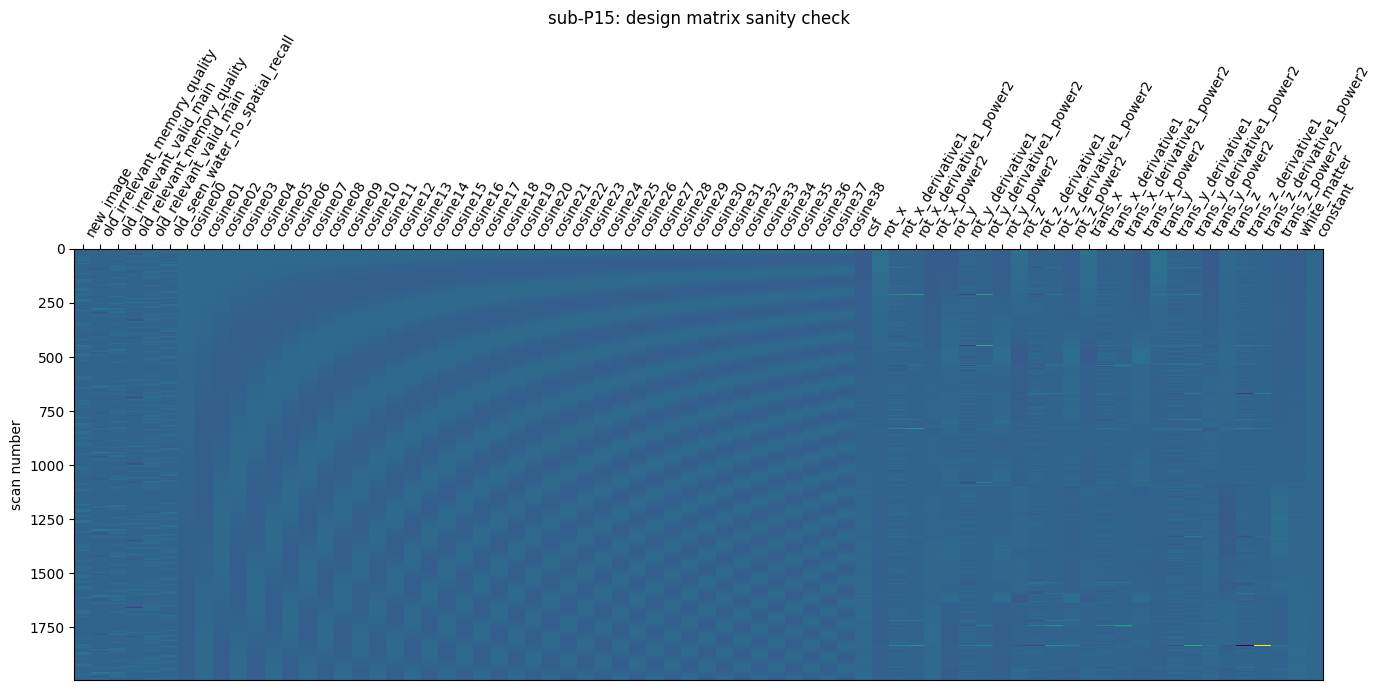


Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/sub-P15_design_matrix_sanity_check.png


In [11]:
# ============================================================
# 11. First-level GLM setup and single-subject design sanity check
# ============================================================

from nilearn.glm.first_level import FirstLevelModel
from nilearn.interfaces.fmriprep import load_confounds
from nilearn.plotting import plot_design_matrix
import nibabel as nib

# Choose one representative subject for sanity check
test_subject = "sub-P15"  # primary_subjects_final[0]

test_bold = expected_post_bold_file(test_subject)
test_events = (
    EVENTS_OUT_DIR
    / f"{test_subject}_{POST_SESSION}_task-{POST_TASK}_run-{POST_RUN}_events_memory_quality.tsv"
)

print("Test subject:", test_subject)
print("BOLD exists:", test_bold.exists(), test_bold)
print("Events exists:", test_events.exists(), test_events)

events_test = pd.read_csv(test_events, sep="\t")

print("\nEvents shape:", events_test.shape)
display(events_test.head())

print("\nEvent counts:")
display(events_test["trial_type"].value_counts().to_frame("n_events"))

print("\nModulation summary by trial type:")
display(
    events_test
    .groupby("trial_type")
    .agg(
        n_events=("onset", "count"),
        mean_modulation=("modulation", "mean"),
        sd_modulation=("modulation", "std"),
        min_modulation=("modulation", "min"),
        max_modulation=("modulation", "max"),
    )
    .reset_index()
)

# Load confounds from fMRIPrep.
# Strategy: motion + WM/CSF + high-pass cosine regressors.
confounds_test, sample_mask_test = load_confounds(
    str(test_bold),
    strategy=["motion", "wm_csf", "high_pass"],
    motion="full",
    wm_csf="basic",
)

print("\nConfounds shape:", confounds_test.shape)
print("Sample mask:", None if sample_mask_test is None else sample_mask_test.shape)
display(confounds_test.head())

# Get TR and number of scans
img = nib.load(str(test_bold))
n_scans = img.shape[-1]
tr = float(img.header.get_zooms()[-1])

print("\nBOLD image:")
print("Shape:", img.shape)
print("n_scans:", n_scans)
print("TR:", tr)

# Fit a single-subject model only to inspect design matrix
first_level_test = FirstLevelModel(
    t_r=tr,
    hrf_model="spm",
    drift_model=None,  # high-pass cosines are already in confounds
    noise_model="ar1",
    standardize=False,
    signal_scaling=0,
    minimize_memory=False,
)

first_level_test = first_level_test.fit(
    run_imgs=str(test_bold),
    events=events_test,
    confounds=confounds_test,
    sample_masks=sample_mask_test,
)

design_matrix_test = first_level_test.design_matrices_[0]

print("\nDesign matrix shape:", design_matrix_test.shape)
print("\nDesign matrix columns:")
print(design_matrix_test.columns.tolist())

fig, ax = plt.subplots(figsize=(14, 7))
plot_design_matrix(design_matrix_test, axes=ax)
ax.set_title(f"{test_subject}: design matrix sanity check")
plt.tight_layout()

design_matrix_plot_path = FIG_DIR / f"{test_subject}_design_matrix_sanity_check.png"
fig.savefig(design_matrix_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("\nSaved:")
print(design_matrix_plot_path)

# Post-viewing GLM: spatial memory quality and goal relevance

## Aim

The goal of this analysis is to test whether hippocampal activity during the post-viewing phase is modulated by the quality of spatial memory for previously seen images.

The main hypothesis is:

$$
\text{Images remembered more precisely in space evoke stronger hippocampal activity during post-viewing.}
$$

A secondary hypothesis is that this memory-quality modulation may differ depending on whether the image was goal-relevant or goal-irrelevant during the task.

$$
\beta_{\text{memory quality, relevant}} > \beta_{\text{memory quality, irrelevant}}
$$

---

## Behavioral memory-quality variable

For each recognized old image, we reconstructed the participant's recalled spatial placement and compared it to the true target/checkpoint location.

Spatial error is defined as the distance between the true image location and the recalled location:

$$
\text{spatial error}_{i} = d(\text{true location}_{i}, \text{recalled location}_{i})
$$

Because lower error means better memory, we define spatial accuracy as:

$$
\text{spatial accuracy}_{i} = -\text{spatial error}_{i}
$$

We then combine spatial accuracy with placement confidence. Both variables are z-scored within participant:

$$
z(\text{spatial accuracy}_{i})
$$

$$
z(\text{confidence}_{i})
$$

The final item-level memory-quality score is:

$$
\text{memory quality}_{i}
=
\frac{
z(\text{spatial accuracy}_{i}) + z(\text{confidence}_{i})
}{2}
$$

This score is then again standardized within participant:

$$
z(\text{memory quality}_{i})
$$

For the GLM, the memory-quality modulator is additionally centered within participant and relevance condition:

$$
\text{MQ}^{*}_{i}
=
z(\text{MQ}_{i})
-
\overline{z(\text{MQ})}_{s,c}
$$

where $s$ is the subject and $c$ is the relevance condition, either goal-relevant or goal-irrelevant.

This makes the memory-quality regressors approximately orthogonal to their corresponding main-effect regressors.

---

## Spatial QC and water placements

Participants were instructed to place an image in the water if they did not remember its location.

Therefore, trials placed in the top or bottom water zones were excluded from the continuous spatial-memory-quality regressor.

They are not deleted from the fMRI model. Instead, they are modeled as a nuisance regressor:

$$
\text{old seen water / no spatial recall}
$$

This is important because the participant still saw those images in the scanner, and the image presentation still evokes visual, attentional, and recognition-related activity.

---

## GLM event structure

The final first-level GLM contains the following event regressors:

| Regressor | Meaning |
|---|---|
| `old_relevant_valid_main` | Average response to valid goal-relevant old images |
| `old_relevant_memory_quality` | Parametric modulation by memory quality for goal-relevant images |
| `old_irrelevant_valid_main` | Average response to valid goal-irrelevant old images |
| `old_irrelevant_memory_quality` | Parametric modulation by memory quality for goal-irrelevant images |
| `old_seen_water_no_spatial_recall` | Old images placed in water, i.e. no valid spatial recall |
| `old_other_no_memory_quality` | Old images without usable memory-quality value |
| `new_image` | New-image viewing nuisance regressor |

The main regressors model average image-viewing responses:

$$
\text{old relevant valid main}
$$

$$
\text{old irrelevant valid main}
$$

The parametric regressors model whether activity increases or decreases as a function of memory quality:

$$
\text{old relevant memory quality}
$$

$$
\text{old irrelevant memory quality}
$$

---

## Planned first-level contrasts

The main planned contrasts are:

### 1. Overall positive memory-quality modulation

$$
C_{\text{all MQ}}
=
\frac{1}{2}\beta_{\text{relevant MQ}}
+
\frac{1}{2}\beta_{\text{irrelevant MQ}}
$$

This tests whether post-viewing activity increases for better-remembered images, across both relevance conditions.

---

### 2. Relevant memory-quality modulation

$$
C_{\text{relevant MQ}}
=
\beta_{\text{relevant MQ}}
$$

This tests whether goal-relevant images show stronger activity when they are remembered more precisely.

---

### 3. Irrelevant memory-quality modulation

$$
C_{\text{irrelevant MQ}}
=
\beta_{\text{irrelevant MQ}}
$$

This tests whether goal-irrelevant images show stronger activity when they are remembered more precisely.

---

### 4. Relevance interaction

$$
C_{\text{relevant > irrelevant MQ}}
=
\beta_{\text{relevant MQ}}
-
\beta_{\text{irrelevant MQ}}
$$

This tests whether the memory-quality modulation is stronger for goal-relevant than goal-irrelevant images.

---

## Interpretation

A positive effect for the memory-quality regressors would suggest that post-viewing hippocampal activity is stronger for images that were later localized more precisely in space.

The interaction contrast tests whether this relationship depends on goal relevance.

The analysis does not claim that hippocampal activity causes better memory. Rather, it tests whether post-viewing neural activity is statistically associated with behavioral spatial memory quality.

Supervisor design summary
Subject used for example design matrix: sub-P15
BOLD file exists: True
Events file exists: True

Events table shape: (594, 14)
Unique event types:
  - new_image
  - old_irrelevant_memory_quality
  - old_irrelevant_valid_main
  - old_relevant_memory_quality
  - old_relevant_valid_main
  - old_seen_water_no_spatial_recall

Event counts:


,trial_type,n_events
2,new_image,96
3,old_irrelevant_memory_quality,90
4,old_irrelevant_valid_main,90
1,old_relevant_memory_quality,120
0,old_relevant_valid_main,120
5,old_seen_water_no_spatial_recall,78



Modulation summary:


,trial_type,n_events,mean_modulation,sd_modulation,min_modulation,max_modulation
0,new_image,96,1.000000e+00,0.000000,1.000000,1.000000
1,old_irrelevant_memory_quality,90,-2.960595e-17,0.910391,-1.457796,2.102787
2,old_irrelevant_valid_main,90,1.000000e+00,0.000000,1.000000,1.000000
3,old_relevant_memory_quality,120,2.312965e-18,1.069963,-3.221088,1.737899
4,old_relevant_valid_main,120,1.000000e+00,0.000000,1.000000,1.000000
5,old_seen_water_no_spatial_recall,78,1.000000e+00,0.000000,1.000000,1.000000


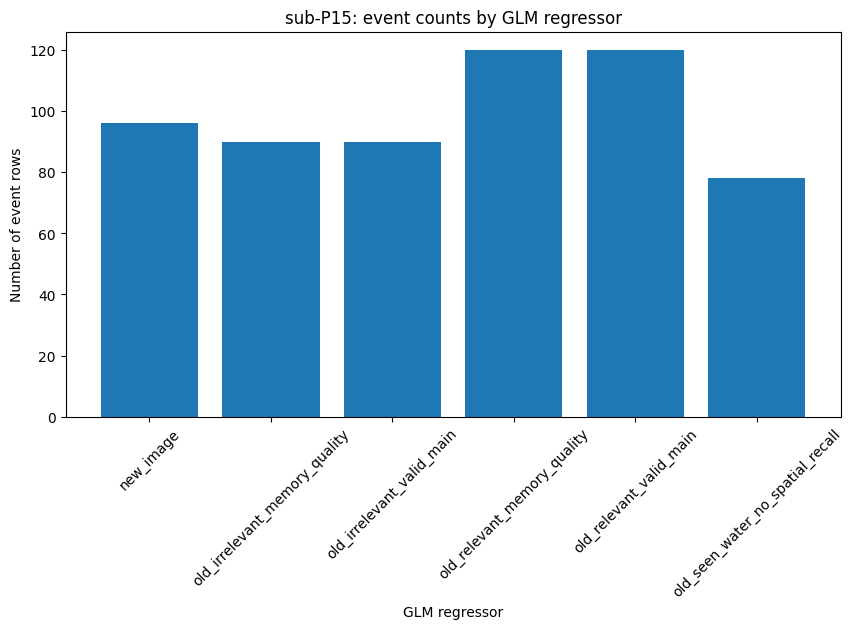

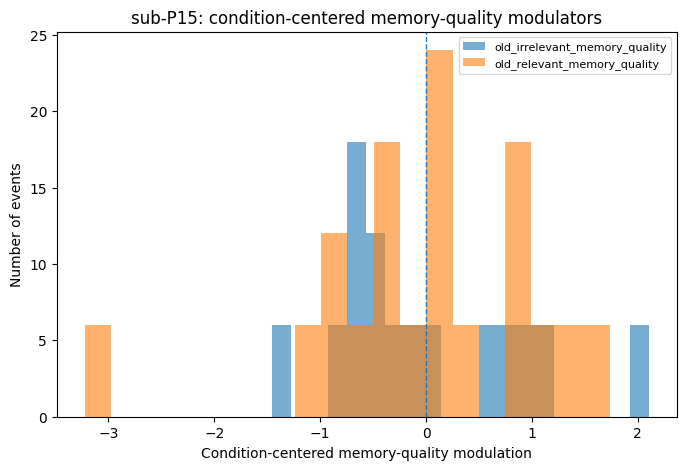

/tmp/ipykernel_71309/3819683161.py:132: UserWarning: The following unexpected columns in events data will be ignored: goal_relevant, valid_spatial_placement, confidence_z, spatial_accuracy_z, likely_water_placement, image_file, goal_irrelevant, relevance_condition, memory_quality_z, memory_quality_condition_centered
  summary_first_level = summary_first_level.fit(


[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.

Design matrix shape: (1995, 72)

Main event columns present in design matrix:
new_image                                True
old_irrelevant_memory_quality            True
old_irrelevant_valid_main                True
old_other_no_memory_quality              False
old_relevant_memory_quality              True
old_relevant_valid_main                  True
old_seen_water_no_spatial_recall         True


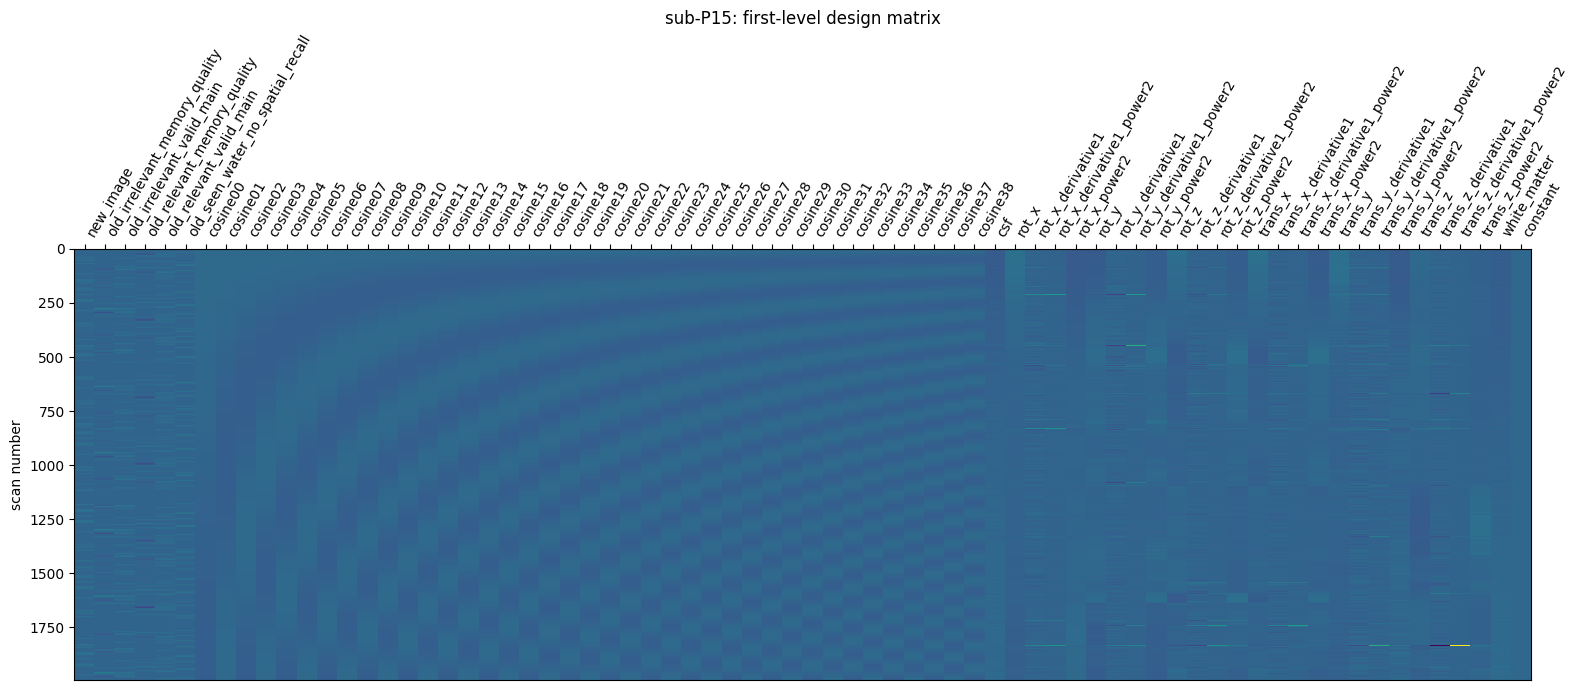

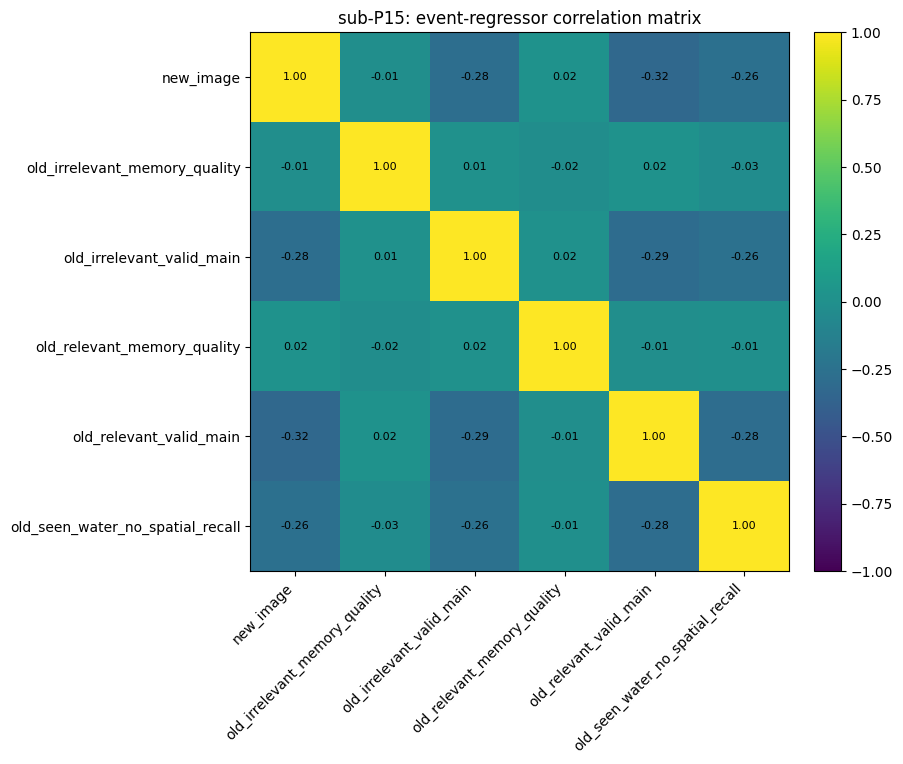


Planned first-level contrasts:


,contrast_name,definition,interpretation
0,all_memory_quality_positive,0.5 * old_relevant_memory_quality + 0.5 * old_...,Activity increasing with memory quality across...
1,relevant_memory_quality_positive,old_relevant_memory_quality,Activity increasing with memory quality for go...
2,irrelevant_memory_quality_positive,old_irrelevant_memory_quality,Activity increasing with memory quality for go...
3,relevant_gt_irrelevant_memory_quality,old_relevant_memory_quality - old_irrelevant_m...,Stronger memory-quality modulation for goal-re...



Saved supervisor summary outputs:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/sub-P15_glm_event_counts_summary.png
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/sub-P15_memory_quality_modulator_histogram.png
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/sub-P15_supervisor_design_matrix.png
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/sub-P15_event_regressor_correlation_matrix.png
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/planned_first_level_contrasts_summary.csv


In [12]:
# ============================================================
# 12. Supervisor-facing design summary and figures
# ============================================================

from nilearn.glm.first_level import FirstLevelModel
from nilearn.interfaces.fmriprep import load_confounds
from nilearn.plotting import plot_design_matrix
import nibabel as nib

# Use a subject with water placements so that the full design is visible.
summary_subject = "sub-P15"

summary_bold = expected_post_bold_file(summary_subject)
summary_events_path = (
    EVENTS_OUT_DIR
    / f"{summary_subject}_{POST_SESSION}_task-{POST_TASK}_run-{POST_RUN}_events_memory_quality.tsv"
)

print("Supervisor design summary")
print("=" * 80)
print("Subject used for example design matrix:", summary_subject)
print("BOLD file exists:", summary_bold.exists())
print("Events file exists:", summary_events_path.exists())

summary_events = pd.read_csv(summary_events_path, sep="\t")

print("\nEvents table shape:", summary_events.shape)
print("Unique event types:")
for event_type in sorted(summary_events["trial_type"].unique()):
    print("  -", event_type)

print("\nEvent counts:")
event_counts_summary = (
    summary_events["trial_type"]
    .value_counts()
    .rename_axis("trial_type")
    .reset_index(name="n_events")
    .sort_values("trial_type")
)
display(event_counts_summary)

print("\nModulation summary:")
modulation_summary = (
    summary_events
    .groupby("trial_type")
    .agg(
        n_events=("onset", "count"),
        mean_modulation=("modulation", "mean"),
        sd_modulation=("modulation", "std"),
        min_modulation=("modulation", "min"),
        max_modulation=("modulation", "max"),
    )
    .reset_index()
)
display(modulation_summary)

# ------------------------------------------------------------
# Plot 1: Event counts by regressor
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    event_counts_summary["trial_type"],
    event_counts_summary["n_events"],
)

ax.set_title(f"{summary_subject}: event counts by GLM regressor")
ax.set_xlabel("GLM regressor")
ax.set_ylabel("Number of event rows")
ax.tick_params(axis="x", rotation=45)

event_count_plot_path = FIG_DIR / f"{summary_subject}_glm_event_counts_summary.png"
fig.savefig(event_count_plot_path, dpi=200, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Plot 2: Memory-quality modulation distributions
# ------------------------------------------------------------

mq_events = summary_events.loc[
    summary_events["trial_type"].isin([
        "old_relevant_memory_quality",
        "old_irrelevant_memory_quality",
    ])
].copy()

fig, ax = plt.subplots(figsize=(8, 5))

for trial_type, sub_df in mq_events.groupby("trial_type"):
    ax.hist(
        sub_df["modulation"],
        bins=20,
        alpha=0.6,
        label=trial_type,
    )

ax.axvline(0, linestyle="--", linewidth=1)
ax.set_title(f"{summary_subject}: condition-centered memory-quality modulators")
ax.set_xlabel("Condition-centered memory-quality modulation")
ax.set_ylabel("Number of events")
ax.legend(fontsize=8)

mq_hist_path = FIG_DIR / f"{summary_subject}_memory_quality_modulator_histogram.png"
fig.savefig(mq_hist_path, dpi=200, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Fit example first-level model to display design matrix
# ------------------------------------------------------------

summary_confounds, summary_sample_mask = load_confounds(
    str(summary_bold),
    strategy=["motion", "wm_csf", "high_pass"],
    motion="full",
    wm_csf="basic",
)

summary_img = nib.load(str(summary_bold))
summary_tr = float(summary_img.header.get_zooms()[-1])

summary_first_level = FirstLevelModel(
    t_r=summary_tr,
    hrf_model="spm",
    drift_model=None,
    noise_model="ar1",
    standardize=False,
    signal_scaling=0,
    minimize_memory=False,
)

summary_first_level = summary_first_level.fit(
    run_imgs=str(summary_bold),
    events=summary_events,
    confounds=summary_confounds,
    sample_masks=summary_sample_mask,
)

summary_design_matrix = summary_first_level.design_matrices_[0]

print("\nDesign matrix shape:", summary_design_matrix.shape)
print("\nMain event columns present in design matrix:")
event_columns_of_interest = [
    "new_image",
    "old_irrelevant_memory_quality",
    "old_irrelevant_valid_main",
    "old_other_no_memory_quality",
    "old_relevant_memory_quality",
    "old_relevant_valid_main",
    "old_seen_water_no_spatial_recall",
]

for col in event_columns_of_interest:
    print(f"{col:40s}", col in summary_design_matrix.columns)

# ------------------------------------------------------------
# Plot 3: Full design matrix
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(16, 7))
plot_design_matrix(summary_design_matrix, axes=ax)
ax.set_title(f"{summary_subject}: first-level design matrix")
plt.tight_layout()

design_matrix_path = FIG_DIR / f"{summary_subject}_supervisor_design_matrix.png"
fig.savefig(design_matrix_path, dpi=200, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Plot 4: Design matrix correlation among main event regressors
# ------------------------------------------------------------

available_event_cols = [
    col for col in event_columns_of_interest
    if col in summary_design_matrix.columns
]

design_corr = summary_design_matrix[available_event_cols].corr()

fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(design_corr, vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(available_event_cols)))
ax.set_yticks(np.arange(len(available_event_cols)))
ax.set_xticklabels(available_event_cols, rotation=45, ha="right")
ax.set_yticklabels(available_event_cols)

for i in range(len(available_event_cols)):
    for j in range(len(available_event_cols)):
        ax.text(
            j,
            i,
            f"{design_corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8,
        )

ax.set_title(f"{summary_subject}: event-regressor correlation matrix")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

corr_plot_path = FIG_DIR / f"{summary_subject}_event_regressor_correlation_matrix.png"
fig.savefig(corr_plot_path, dpi=200, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Planned contrasts table
# ------------------------------------------------------------

planned_contrasts = pd.DataFrame([
    {
        "contrast_name": "all_memory_quality_positive",
        "definition": "0.5 * old_relevant_memory_quality + 0.5 * old_irrelevant_memory_quality",
        "interpretation": "Activity increasing with memory quality across relevant and irrelevant images.",
    },
    {
        "contrast_name": "relevant_memory_quality_positive",
        "definition": "old_relevant_memory_quality",
        "interpretation": "Activity increasing with memory quality for goal-relevant images.",
    },
    {
        "contrast_name": "irrelevant_memory_quality_positive",
        "definition": "old_irrelevant_memory_quality",
        "interpretation": "Activity increasing with memory quality for goal-irrelevant images.",
    },
    {
        "contrast_name": "relevant_gt_irrelevant_memory_quality",
        "definition": "old_relevant_memory_quality - old_irrelevant_memory_quality",
        "interpretation": "Stronger memory-quality modulation for goal-relevant than goal-irrelevant images.",
    },
])

print("\nPlanned first-level contrasts:")
display(planned_contrasts)

planned_contrasts_path = TABLE_DIR / "planned_first_level_contrasts_summary.csv"
planned_contrasts.to_csv(planned_contrasts_path, index=False)

print("\nSaved supervisor summary outputs:")
print(event_count_plot_path)
print(mq_hist_path)
print(design_matrix_path)
print(corr_plot_path)
print(planned_contrasts_path)

In [13]:
# ============================================================
# 13. QC: actual image presentations vs GLM event rows
# ============================================================

summary_subject = "sub-P15"

summary_events_path = (
    EVENTS_OUT_DIR
    / f"{summary_subject}_{POST_SESSION}_task-{POST_TASK}_run-{POST_RUN}_events_memory_quality.tsv"
)

summary_events = pd.read_csv(summary_events_path, sep="\t")

# Main-effect/nuisance rows correspond to actual image presentations.
actual_presentation_trial_types = [
    "new_image",
    "old_relevant_valid_main",
    "old_irrelevant_valid_main",
    "old_seen_water_no_spatial_recall",
    "old_other_no_memory_quality",
]

# Parametric rows are extra GLM rows added at the same onset as valid old images.
parametric_trial_types = [
    "old_relevant_memory_quality",
    "old_irrelevant_memory_quality",
]

summary_events["row_role"] = np.where(
    summary_events["trial_type"].isin(parametric_trial_types),
    "parametric_modulator_row",
    "actual_presentation_row",
)

presentation_qc = (
    summary_events
    .groupby(["row_role", "trial_type"])
    .size()
    .reset_index(name="n_rows")
)

display(presentation_qc)

n_actual_presentations = summary_events.loc[
    summary_events["trial_type"].isin(actual_presentation_trial_types)
].shape[0]

n_parametric_rows = summary_events.loc[
    summary_events["trial_type"].isin(parametric_trial_types)
].shape[0]

n_total_rows = len(summary_events)

print("QC summary")
print("=" * 80)
print("Actual image-presentation rows:", n_actual_presentations)
print("Parametric-modulator rows:", n_parametric_rows)
print("Total rows in events.tsv:", n_total_rows)
print()
print("Expected actual image presentations:", 384)
print("Actual-presentation QC passed:", n_actual_presentations == 384)
print("Total-row QC passed:", n_total_rows == n_actual_presentations + n_parametric_rows)

assert n_actual_presentations == 384, "Actual image presentations do not sum to 384."
assert n_total_rows == n_actual_presentations + n_parametric_rows, "Total event-row accounting mismatch."

,row_role,trial_type,n_rows
0,actual_presentation_row,new_image,96
1,actual_presentation_row,old_irrelevant_valid_main,90
2,actual_presentation_row,old_relevant_valid_main,120
3,actual_presentation_row,old_seen_water_no_spatial_recall,78
4,parametric_modulator_row,old_irrelevant_memory_quality,90
5,parametric_modulator_row,old_relevant_memory_quality,120


QC summary
Actual image-presentation rows: 384
Parametric-modulator rows: 210
Total rows in events.tsv: 594

Expected actual image presentations: 384
Actual-presentation QC passed: True
Total-row QC passed: True


# Behavioral analysis before neural GLM

Before running the fMRI GLM, we first characterize the behavioral structure of the memory task.

The goals are:

1. Understand whether goal-relevant and goal-irrelevant images differ behaviorally.
2. Quantify spatial memory precision, confidence, and water/no-recall responses.
3. Compare different conventions for defining memory quality.
4. Justify the behavioral regressor used later in the neural GLM.

A key methodological question is whether confidence should be normalized within participant.

Within-subject normalization has the advantage of controlling for individual scale use:

$$
z(\text{confidence}_{i,s})
=
\frac{
\text{confidence}_{i,s} - \overline{\text{confidence}}_s
}{
\sigma(\text{confidence})_s
}
$$

However, this also means that a participant using only a restricted confidence range, for example 30 to 70, is treated similarly to a participant using the full 0 to 100 scale. Therefore, we will compare both raw and normalized confidence conventions.

For spatial precision, lower spatial error means better memory:

$$
\text{spatial accuracy}_{i,s} = -\text{spatial error}_{i,s}
$$

We will compare behavioral models using:

$$
\text{spatial error}
$$

$$
\text{confidence}_{raw}
$$

$$
z(\text{confidence})
$$

$$
\text{memory quality}
=
\frac{
z(\text{spatial accuracy}) + z(\text{confidence})
}{2}
$$

In [14]:
# ============================================================
# 13. Build behavioral dataframe for pre-GLM behavioral analysis
# ============================================================

# We build two behavioral datasets:
# 1. behavior_all_matched: all recognized old images present in post-viewing,
#    including water/no-spatial-recall placements.
# 2. behavior_valid_spatial: only valid spatial placements, used for continuous
#    spatial precision / memory-quality analyses.

behavior_all_matched = spatial_qc.copy()

# Ensure clean boolean flags
for col in ["goal_relevant", "goal_irrelevant", "likely_water_placement", "valid_spatial_placement"]:
    behavior_all_matched[col] = (
        behavior_all_matched[col]
        .astype("boolean")
        .fillna(False)
        .astype(bool)
    )

behavior_all_matched["relevance_condition"] = np.where(
    behavior_all_matched["goal_relevant"],
    "relevant",
    "irrelevant",
)

behavior_all_matched["relevance_binary"] = behavior_all_matched["goal_relevant"].astype(int)

# Spatial accuracy is only meaningful as a continuous variable for valid placements.
behavior_all_matched["spatial_accuracy"] = -behavior_all_matched["spatial_error"]

behavior_valid_spatial = behavior_all_matched.loc[
    behavior_all_matched["valid_spatial_placement"]
].copy()

# ------------------------------------------------------------
# Helper: within-subject z-scoring
# ------------------------------------------------------------

def add_subject_zscore(df, col, out_col):
    def _z(x):
        sd = x.std(ddof=0)
        if pd.isna(sd) or np.isclose(sd, 0):
            return pd.Series(np.nan, index=x.index)
        return (x - x.mean()) / sd
    
    df[out_col] = df.groupby("subject", group_keys=False)[col].apply(_z)
    return df

# Within-subject z-scores for valid spatial placements
behavior_valid_spatial = add_subject_zscore(
    behavior_valid_spatial,
    "spatial_accuracy",
    "spatial_accuracy_z",
)

behavior_valid_spatial = add_subject_zscore(
    behavior_valid_spatial,
    "confidence",
    "confidence_z_subject",
)

behavior_valid_spatial["memory_quality_subject_z_raw"] = (
    behavior_valid_spatial["spatial_accuracy_z"]
    + behavior_valid_spatial["confidence_z_subject"]
) / 2

behavior_valid_spatial = add_subject_zscore(
    behavior_valid_spatial,
    "memory_quality_subject_z_raw",
    "memory_quality_subject_z",
)

# Alternative confidence convention:
# raw confidence rescaled to 0-1, not normalized within participant.
behavior_valid_spatial["confidence_raw_0_1"] = behavior_valid_spatial["confidence"] / 100

# Alternative combined score:
# z-scored spatial accuracy + globally scaled raw confidence.
# We z-score the final combined score within subject to keep GLM scale comparable.
behavior_valid_spatial["memory_quality_raw_confidence_raw"] = (
    behavior_valid_spatial["spatial_accuracy_z"]
    + behavior_valid_spatial["confidence_raw_0_1"]
) / 2

behavior_valid_spatial = add_subject_zscore(
    behavior_valid_spatial,
    "memory_quality_raw_confidence_raw",
    "memory_quality_raw_confidence_subject_z",
)

# ------------------------------------------------------------
# Save datasets
# ------------------------------------------------------------

behavior_all_matched_path = TABLE_DIR / "behavior_all_matched_with_water_flags.csv"
behavior_valid_spatial_path = TABLE_DIR / "behavior_valid_spatial_modeling_dataset.csv"

behavior_all_matched.to_csv(behavior_all_matched_path, index=False)
behavior_valid_spatial.to_csv(behavior_valid_spatial_path, index=False)

print("Behavioral datasets created")
print("=" * 80)
print("All matched recognized-old images:", len(behavior_all_matched))
print("Valid spatial placements:", len(behavior_valid_spatial))
print("Water/no-spatial-recall placements:", int(behavior_all_matched["likely_water_placement"].sum()))
print("Subjects all matched:", behavior_all_matched["subject"].nunique())
print("Subjects valid spatial:", behavior_valid_spatial["subject"].nunique())

print("\nMissing values in valid-spatial behavioral variables:")
display(
    behavior_valid_spatial[
        [
            "spatial_error",
            "spatial_accuracy",
            "confidence",
            "spatial_accuracy_z",
            "confidence_z_subject",
            "memory_quality_subject_z",
            "confidence_raw_0_1",
            "memory_quality_raw_confidence_subject_z",
        ]
    ].isna().sum().to_frame("n_missing")
)

print("\nSaved:")
print(behavior_all_matched_path)
print(behavior_valid_spatial_path)

Behavioral datasets created
All matched recognized-old images: 1105
Valid spatial placements: 1045
Water/no-spatial-recall placements: 60
Subjects all matched: 28
Subjects valid spatial: 28

Missing values in valid-spatial behavioral variables:


,n_missing
spatial_error,0
spatial_accuracy,0
confidence,0
spatial_accuracy_z,0
confidence_z_subject,0
memory_quality_subject_z,0
confidence_raw_0_1,0
memory_quality_raw_confidence_subject_z,0



Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/behavior_all_matched_with_water_flags.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/behavior_valid_spatial_modeling_dataset.csv


In [15]:
# ============================================================
# 14. Behavioral descriptive statistics by relevance condition
# ============================================================

print("A. All matched recognized-old images, including water placements")
print("=" * 80)

all_summary = (
    behavior_all_matched
    .groupby("relevance_condition")
    .agg(
        n_images=("image_file", "count"),
        n_subjects=("subject", "nunique"),
        n_water=("likely_water_placement", "sum"),
        water_rate=("likely_water_placement", "mean"),
        mean_confidence=("confidence", "mean"),
        sd_confidence=("confidence", "std"),
    )
    .reset_index()
)

display(all_summary)

print("\nB. Valid spatial placements only")
print("=" * 80)

valid_summary = (
    behavior_valid_spatial
    .groupby("relevance_condition")
    .agg(
        n_images=("image_file", "count"),
        n_subjects=("subject", "nunique"),
        mean_spatial_error=("spatial_error", "mean"),
        sd_spatial_error=("spatial_error", "std"),
        mean_confidence=("confidence", "mean"),
        sd_confidence=("confidence", "std"),
        mean_confidence_z_subject=("confidence_z_subject", "mean"),
        mean_memory_quality_subject_z=("memory_quality_subject_z", "mean"),
        mean_memory_quality_raw_confidence_subject_z=("memory_quality_raw_confidence_subject_z", "mean"),
    )
    .reset_index()
)

display(valid_summary)

print("\nC. Subject-level valid image counts")
print("=" * 80)

subject_behavior_counts = (
    behavior_all_matched
    .groupby(["subject", "relevance_condition"])
    .agg(
        n_matched=("image_file", "count"),
        n_water=("likely_water_placement", "sum"),
        n_valid_spatial=("valid_spatial_placement", "sum"),
        water_rate=("likely_water_placement", "mean"),
    )
    .reset_index()
)

display(subject_behavior_counts.head(20))

all_summary_path = TABLE_DIR / "behavior_summary_all_matched_by_relevance.csv"
valid_summary_path = TABLE_DIR / "behavior_summary_valid_spatial_by_relevance.csv"
subject_behavior_counts_path = TABLE_DIR / "behavior_subject_counts_by_relevance.csv"

all_summary.to_csv(all_summary_path, index=False)
valid_summary.to_csv(valid_summary_path, index=False)
subject_behavior_counts.to_csv(subject_behavior_counts_path, index=False)

print("\nSaved:")
print(all_summary_path)
print(valid_summary_path)
print(subject_behavior_counts_path)

A. All matched recognized-old images, including water placements


,relevance_condition,n_images,n_subjects,n_water,water_rate,mean_confidence,sd_confidence
0,irrelevant,537,28,32,0.059590,39.558659,27.992616
1,relevant,568,28,28,0.049296,42.808099,29.333757



B. Valid spatial placements only


,relevance_condition,n_images,n_subjects,mean_spatial_error,sd_spatial_error,mean_confidence,sd_confidence,mean_confidence_z_subject,mean_memory_quality_subject_z,mean_memory_quality_raw_confidence_subject_z
0,irrelevant,505,28,450.145673,272.951621,38.451485,27.028683,-0.088161,-0.089188,-0.054781
1,relevant,540,28,426.919610,253.780558,42.570370,28.924838,0.082447,0.083408,0.051231



C. Subject-level valid image counts


,subject,relevance_condition,n_matched,n_water,n_valid_spatial,water_rate
0,sub-P10,irrelevant,12,0,12,0.000000
1,sub-P10,relevant,16,0,16,0.000000
2,sub-P12,irrelevant,12,0,12,0.000000
3,sub-P12,relevant,18,0,18,0.000000
4,sub-P13,irrelevant,21,0,21,0.000000
5,sub-P13,relevant,21,0,21,0.000000
6,sub-P14,irrelevant,24,0,24,0.000000
7,sub-P14,relevant,23,0,23,0.000000
8,sub-P15,irrelevant,24,9,15,0.375000
9,sub-P15,relevant,24,4,20,0.166667



Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/behavior_summary_all_matched_by_relevance.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/behavior_summary_valid_spatial_by_relevance.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/behavior_subject_counts_by_relevance.csv


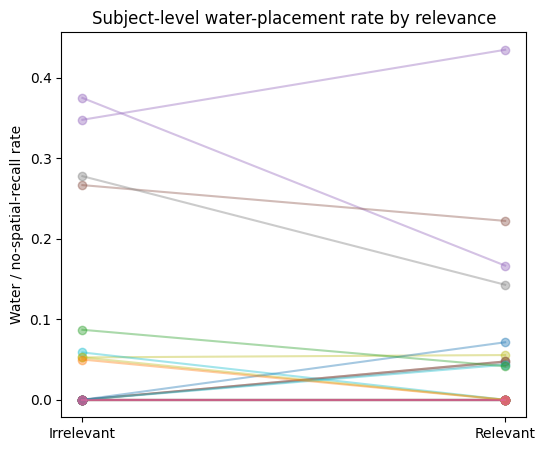

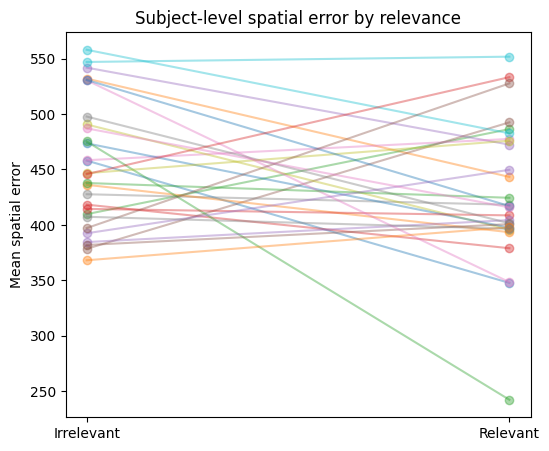

/tmp/ipykernel_71309/3053849327.py:98: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(confidence_data, labels=subjects_order, showfliers=False)


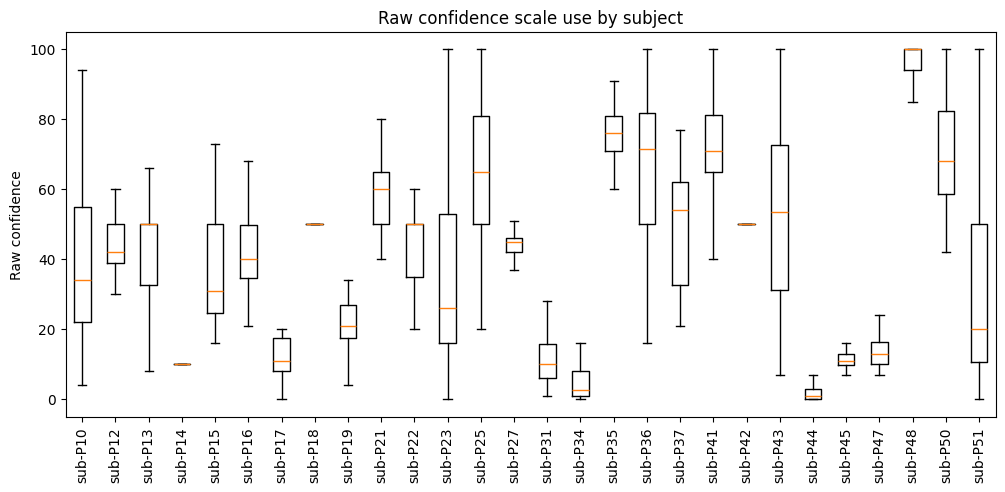

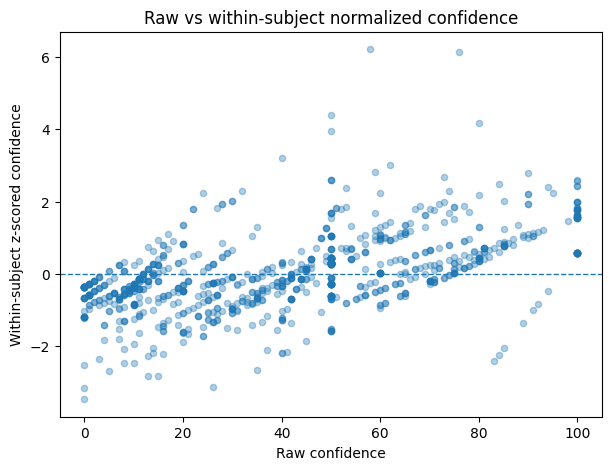

Saved plots:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/behavior_water_rate_by_relevance_subject_lines.png
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/behavior_spatial_error_by_relevance_subject_lines.png
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/behavior_raw_confidence_scale_use_by_subject.png
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/behavior_raw_vs_subject_z_confidence.png


In [16]:
# ============================================================
# 15. Behavioral plots: relevance effects and confidence scaling
# ============================================================

# ------------------------------------------------------------
# Plot 1: Water/no-spatial-recall rate by relevance
# ------------------------------------------------------------

water_subject = (
    behavior_all_matched
    .groupby(["subject", "relevance_condition"])
    .agg(water_rate=("likely_water_placement", "mean"))
    .reset_index()
)

water_pivot = water_subject.pivot(
    index="subject",
    columns="relevance_condition",
    values="water_rate",
).reset_index()

fig, ax = plt.subplots(figsize=(6, 5))

x_positions = {"irrelevant": 0, "relevant": 1}

for _, row in water_pivot.iterrows():
    ax.plot(
        [x_positions["irrelevant"], x_positions["relevant"]],
        [row["irrelevant"], row["relevant"]],
        marker="o",
        alpha=0.4,
    )

ax.set_xticks([0, 1])
ax.set_xticklabels(["Irrelevant", "Relevant"])
ax.set_ylabel("Water / no-spatial-recall rate")
ax.set_title("Subject-level water-placement rate by relevance")

water_rate_plot_path = FIG_DIR / "behavior_water_rate_by_relevance_subject_lines.png"
fig.savefig(water_rate_plot_path, dpi=200, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Plot 2: Spatial error by relevance, valid placements only
# ------------------------------------------------------------

spatial_subject = (
    behavior_valid_spatial
    .groupby(["subject", "relevance_condition"])
    .agg(mean_spatial_error=("spatial_error", "mean"))
    .reset_index()
)

spatial_pivot = spatial_subject.pivot(
    index="subject",
    columns="relevance_condition",
    values="mean_spatial_error",
).reset_index()

fig, ax = plt.subplots(figsize=(6, 5))

for _, row in spatial_pivot.iterrows():
    ax.plot(
        [x_positions["irrelevant"], x_positions["relevant"]],
        [row["irrelevant"], row["relevant"]],
        marker="o",
        alpha=0.4,
    )

ax.set_xticks([0, 1])
ax.set_xticklabels(["Irrelevant", "Relevant"])
ax.set_ylabel("Mean spatial error")
ax.set_title("Subject-level spatial error by relevance")

spatial_error_plot_path = FIG_DIR / "behavior_spatial_error_by_relevance_subject_lines.png"
fig.savefig(spatial_error_plot_path, dpi=200, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Plot 3: Raw confidence distributions by subject
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 5))

subjects_order = sorted(
    behavior_valid_spatial["subject"].unique(),
    key=natural_sort_key,
)

confidence_data = [
    behavior_valid_spatial.loc[
        behavior_valid_spatial["subject"] == subject,
        "confidence",
    ].dropna().values
    for subject in subjects_order
]

ax.boxplot(confidence_data, labels=subjects_order, showfliers=False)
ax.set_ylabel("Raw confidence")
ax.set_title("Raw confidence scale use by subject")
ax.tick_params(axis="x", rotation=90)

confidence_scale_plot_path = FIG_DIR / "behavior_raw_confidence_scale_use_by_subject.png"
fig.savefig(confidence_scale_plot_path, dpi=200, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Plot 4: Compare raw confidence vs subject-z confidence
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    behavior_valid_spatial["confidence"],
    behavior_valid_spatial["confidence_z_subject"],
    alpha=0.35,
    s=20,
)

ax.axhline(0, linestyle="--", linewidth=1)
ax.set_xlabel("Raw confidence")
ax.set_ylabel("Within-subject z-scored confidence")
ax.set_title("Raw vs within-subject normalized confidence")

confidence_raw_z_plot_path = FIG_DIR / "behavior_raw_vs_subject_z_confidence.png"
fig.savefig(confidence_raw_z_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved plots:")
print(water_rate_plot_path)
print(spatial_error_plot_path)
print(confidence_scale_plot_path)
print(confidence_raw_z_plot_path)

In [17]:
# ============================================================
# 16. Subject-level paired t-tests by relevance
# ============================================================

from scipy import stats

def paired_ttest_from_long(
    df,
    value_col,
    subject_col="subject",
    condition_col="relevance_condition",
    condition_a="relevant",
    condition_b="irrelevant",
):
    """
    Aggregates to subject × condition means, then performs paired t-test:
    condition_a - condition_b.
    """
    subject_condition = (
        df
        .groupby([subject_col, condition_col])
        .agg(value=(value_col, "mean"))
        .reset_index()
    )
    
    wide = subject_condition.pivot(
        index=subject_col,
        columns=condition_col,
        values="value",
    )
    
    wide = wide.dropna(subset=[condition_a, condition_b]).copy()
    wide["difference"] = wide[condition_a] - wide[condition_b]
    
    t_stat, p_value = stats.ttest_rel(
        wide[condition_a],
        wide[condition_b],
        nan_policy="omit",
    )
    
    dz = wide["difference"].mean() / wide["difference"].std(ddof=1)
    
    result = {
        "variable": value_col,
        "n_subjects": len(wide),
        f"mean_{condition_a}": wide[condition_a].mean(),
        f"mean_{condition_b}": wide[condition_b].mean(),
        f"mean_difference_{condition_a}_minus_{condition_b}": wide["difference"].mean(),
        "t_stat": t_stat,
        "p_value": p_value,
        "cohens_dz": dz,
    }
    
    return result, wide.reset_index()


# ------------------------------------------------------------
# T-tests for water/no-recall rate
# ------------------------------------------------------------

water_ttest_result, water_ttest_wide = paired_ttest_from_long(
    behavior_all_matched,
    value_col="likely_water_placement",
)

# ------------------------------------------------------------
# T-tests for valid spatial placements only
# ------------------------------------------------------------

ttest_variables_valid = [
    "spatial_error",
    "spatial_accuracy",
    "confidence",
    "confidence_z_subject",
    "memory_quality_subject_z",
    "memory_quality_raw_confidence_subject_z",
]

ttest_results = [water_ttest_result]
ttest_wide_tables = {
    "likely_water_placement": water_ttest_wide,
}

for var in ttest_variables_valid:
    result, wide = paired_ttest_from_long(
        behavior_valid_spatial,
        value_col=var,
    )
    ttest_results.append(result)
    ttest_wide_tables[var] = wide

ttest_results_df = pd.DataFrame(ttest_results)

print("Subject-level paired t-tests: relevant minus irrelevant")
display(ttest_results_df)

# Save outputs
ttest_results_path = TABLE_DIR / "behavior_paired_ttests_relevant_minus_irrelevant.csv"
ttest_results_df.to_csv(ttest_results_path, index=False)

for var, wide in ttest_wide_tables.items():
    safe_var = var.replace("/", "_")
    wide.to_csv(TABLE_DIR / f"behavior_paired_ttest_wide_{safe_var}.csv", index=False)

print("\nSaved:")
print(ttest_results_path)

Subject-level paired t-tests: relevant minus irrelevant


,variable,n_subjects,mean_relevant,mean_irrelevant,mean_difference_relevant_minus_irrelevant,t_stat,p_value,cohens_dz
0,likely_water_placement,28,0.047120,0.056011,-0.008892,-0.800326,0.430508,-0.151247
1,spatial_error,28,427.942763,454.544066,-26.601304,-1.662489,0.107982,-0.314181
2,spatial_accuracy,28,-427.942763,-454.544066,26.601304,1.662489,0.107982,0.314181
3,confidence,28,43.022414,40.408206,2.614208,2.469940,0.020124,0.466775
4,confidence_z_subject,28,0.073168,-0.077501,0.150669,2.539092,0.017187,0.479843
5,memory_quality_subject_z,28,0.076607,-0.089099,0.165707,2.706213,0.011650,0.511426
6,memory_quality_raw_confidence_subject_z,28,0.048997,-0.064242,0.113240,1.830010,0.078310,0.345839



Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/behavior_paired_ttests_relevant_minus_irrelevant.csv


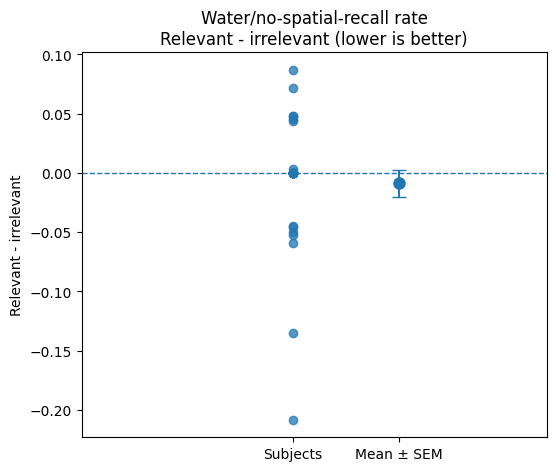

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/behavior_paired_difference_likely_water_placement.png


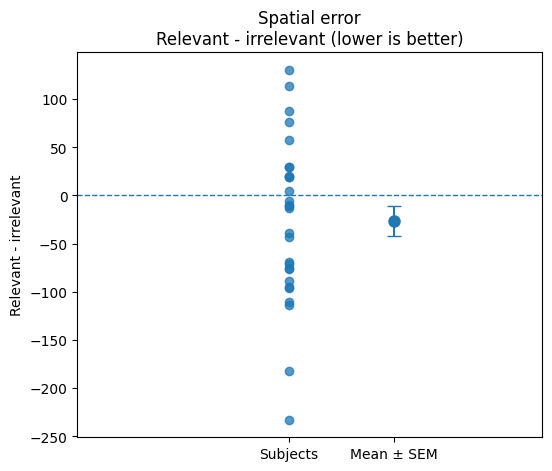

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/behavior_paired_difference_spatial_error.png


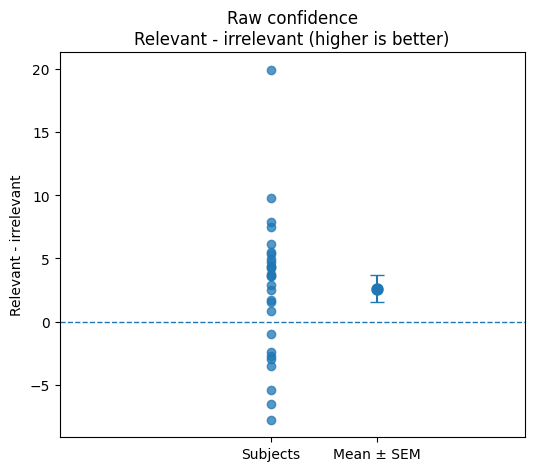

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/behavior_paired_difference_confidence.png


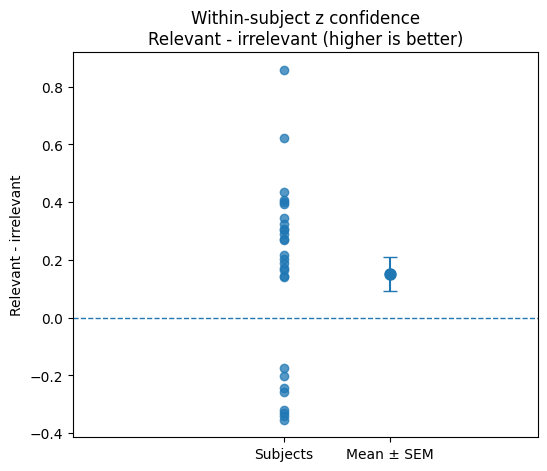

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/behavior_paired_difference_confidence_z_subject.png


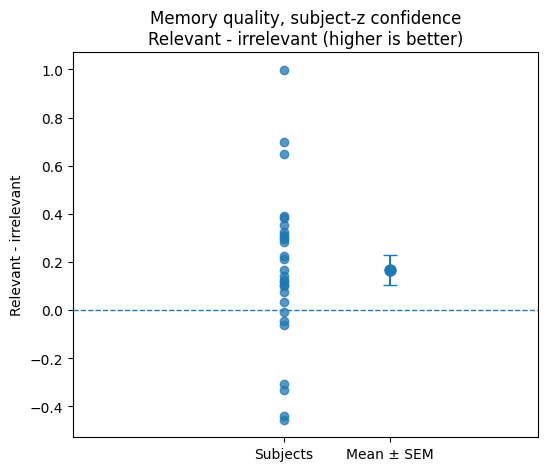

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/behavior_paired_difference_memory_quality_subject_z.png


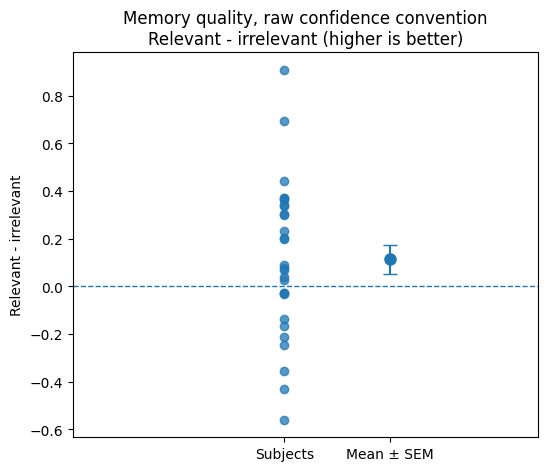

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/behavior_paired_difference_memory_quality_raw_confidence_subject_z.png


In [18]:
# ============================================================
# 17. Plot subject-level paired differences
# ============================================================

variables_to_plot = [
    ("likely_water_placement", "Water/no-spatial-recall rate", "lower is better"),
    ("spatial_error", "Spatial error", "lower is better"),
    ("confidence", "Raw confidence", "higher is better"),
    ("confidence_z_subject", "Within-subject z confidence", "higher is better"),
    ("memory_quality_subject_z", "Memory quality, subject-z confidence", "higher is better"),
    ("memory_quality_raw_confidence_subject_z", "Memory quality, raw confidence convention", "higher is better"),
]

for var, label, direction in variables_to_plot:
    wide = ttest_wide_tables[var].copy()
    
    fig, ax = plt.subplots(figsize=(6, 5))
    
    ax.axhline(0, linestyle="--", linewidth=1)
    
    ax.scatter(
        np.zeros(len(wide)),
        wide["difference"],
        alpha=0.75,
    )
    
    mean_diff = wide["difference"].mean()
    sem_diff = wide["difference"].std(ddof=1) / np.sqrt(len(wide))
    
    ax.errorbar(
        [0.25],
        [mean_diff],
        yerr=[sem_diff],
        marker="o",
        markersize=8,
        capsize=5,
    )
    
    ax.set_xlim(-0.5, 0.6)
    ax.set_xticks([0, 0.25])
    ax.set_xticklabels(["Subjects", "Mean ± SEM"])
    ax.set_ylabel("Relevant - irrelevant")
    ax.set_title(f"{label}\nRelevant - irrelevant ({direction})")
    
    out_path = FIG_DIR / f"behavior_paired_difference_{var}.png"
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    
    print("Saved:", out_path)

In [19]:
# ============================================================
# 18. Confidence scale-use summary by subject
# ============================================================

confidence_scale_summary = (
    behavior_valid_spatial
    .groupby("subject")
    .agg(
        n_images=("image_file", "count"),
        mean_confidence=("confidence", "mean"),
        sd_confidence=("confidence", "std"),
        min_confidence=("confidence", "min"),
        max_confidence=("confidence", "max"),
        confidence_range=("confidence", lambda x: x.max() - x.min()),
        median_confidence=("confidence", "median"),
    )
    .reset_index()
)

print("Confidence scale-use summary:")
display(confidence_scale_summary)

print("\nAcross-subject summary of confidence scale use:")
display(
    confidence_scale_summary[
        [
            "mean_confidence",
            "sd_confidence",
            "min_confidence",
            "max_confidence",
            "confidence_range",
            "median_confidence",
        ]
    ].describe()
)

confidence_scale_summary_path = TABLE_DIR / "behavior_confidence_scale_use_by_subject.csv"
confidence_scale_summary.to_csv(confidence_scale_summary_path, index=False)

print("\nSaved:")
print(confidence_scale_summary_path)

Confidence scale-use summary:


,subject,n_images,mean_confidence,sd_confidence,min_confidence,max_confidence,confidence_range,median_confidence
0,sub-P10,28,37.571429,23.946590,4.0,94.0,90.0,34.0
1,sub-P12,30,43.900000,14.798299,8.0,73.0,65.0,42.0
2,sub-P13,42,42.642857,16.866508,3.0,84.0,81.0,50.0
3,sub-P14,47,13.085106,8.477155,6.0,50.0,44.0,10.0
4,sub-P15,35,35.285714,14.329261,16.0,73.0,57.0,31.0
5,sub-P16,40,42.300000,13.965525,5.0,74.0,69.0,40.0
6,sub-P17,31,18.967742,18.734076,0.0,60.0,60.0,11.0
7,sub-P18,43,45.697674,14.575803,0.0,71.0,71.0,50.0
8,sub-P19,35,23.142857,10.524880,4.0,50.0,46.0,21.0
9,sub-P21,34,59.558824,16.019290,15.0,100.0,85.0,60.0



Across-subject summary of confidence scale use:


,mean_confidence,sd_confidence,min_confidence,max_confidence,confidence_range,median_confidence
count,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000
mean,41.779875,15.880177,12.285714,79.892857,67.607143,40.589286
std,23.196906,6.625463,17.696740,21.430921,24.396933,25.580683
min,4.227273,3.590707,0.000000,24.000000,17.000000,1.000000
25%,22.099078,11.572437,0.000000,68.250000,54.750000,18.250000
50%,43.271429,15.813094,6.500000,82.000000,70.500000,43.500000
75%,56.920956,20.637748,17.000000,100.000000,84.250000,55.500000
max,96.720000,27.862813,83.000000,100.000000,100.000000,100.000000



Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/behavior_confidence_scale_use_by_subject.csv


In [20]:
# ============================================================
# 19a. Install / check statsmodels
# ============================================================

import sys
import subprocess
import importlib.util

package_name = "statsmodels"

if importlib.util.find_spec(package_name) is None:
    print("statsmodels is not installed. Installing now...")
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "statsmodels",
    ])
else:
    print("statsmodels is already installed.")

import statsmodels
import statsmodels.formula.api as smf

print("statsmodels version:", statsmodels.__version__)

statsmodels is already installed.
statsmodels version: 0.14.6


In [21]:
# ============================================================
# 19. Linear mixed models for continuous behavioral variables
# ============================================================

import statsmodels.formula.api as smf

# We use valid spatial placements only for continuous spatial-memory variables.
# Random intercept for subject:
# outcome ~ relevance + (1 | subject)

continuous_lmm_specs = [
    {
        "model_name": "spatial_error_by_relevance",
        "formula": "spatial_error ~ relevance_binary",
        "data": behavior_valid_spatial,
        "interpretation": "Negative relevance coefficient means relevant images have lower spatial error.",
    },
    {
        "model_name": "spatial_accuracy_by_relevance",
        "formula": "spatial_accuracy ~ relevance_binary",
        "data": behavior_valid_spatial,
        "interpretation": "Positive relevance coefficient means relevant images have higher spatial accuracy.",
    },
    {
        "model_name": "raw_confidence_by_relevance",
        "formula": "confidence ~ relevance_binary",
        "data": behavior_valid_spatial,
        "interpretation": "Positive relevance coefficient means relevant images have higher raw confidence.",
    },
    {
        "model_name": "subject_z_confidence_by_relevance",
        "formula": "confidence_z_subject ~ relevance_binary",
        "data": behavior_valid_spatial,
        "interpretation": "Positive relevance coefficient means relevant images have higher within-subject confidence.",
    },
    {
        "model_name": "memory_quality_subject_z_by_relevance",
        "formula": "memory_quality_subject_z ~ relevance_binary",
        "data": behavior_valid_spatial,
        "interpretation": "Positive relevance coefficient means relevant images have higher combined memory quality using subject-z confidence.",
    },
    {
        "model_name": "memory_quality_raw_confidence_by_relevance",
        "formula": "memory_quality_raw_confidence_subject_z ~ relevance_binary",
        "data": behavior_valid_spatial,
        "interpretation": "Positive relevance coefficient means relevant images have higher combined memory quality using raw-confidence convention.",
    },
]

lmm_results = []
lmm_models = {}

for spec in continuous_lmm_specs:
    print("\n" + "=" * 80)
    print(spec["model_name"])
    print(spec["formula"])
    print(spec["interpretation"])
    
    model = smf.mixedlm(
        formula=spec["formula"],
        data=spec["data"],
        groups=spec["data"]["subject"],
    )
    
    fit = model.fit(reml=False, method="lbfgs")
    lmm_models[spec["model_name"]] = fit
    
    print(fit.summary())
    
    coef_table = fit.summary().tables[1].copy()
    
    relevance_coef = fit.params.get("relevance_binary", np.nan)
    relevance_se = fit.bse.get("relevance_binary", np.nan)
    relevance_z = relevance_coef / relevance_se
    relevance_p = fit.pvalues.get("relevance_binary", np.nan)
    
    lmm_results.append({
        "model_name": spec["model_name"],
        "formula": spec["formula"],
        "n_observations": int(fit.nobs),
        "n_subjects": spec["data"]["subject"].nunique(),
        "aic": fit.aic,
        "bic": fit.bic,
        "log_likelihood": fit.llf,
        "relevance_coef": relevance_coef,
        "relevance_se": relevance_se,
        "relevance_z": relevance_z,
        "relevance_p": relevance_p,
        "interpretation": spec["interpretation"],
    })

lmm_results_df = pd.DataFrame(lmm_results)

print("\n" + "=" * 80)
print("Continuous LMM summary")
display(lmm_results_df)

lmm_results_path = TABLE_DIR / "behavior_lmm_continuous_relevance_summary.csv"
lmm_results_df.to_csv(lmm_results_path, index=False)

print("\nSaved:")
print(lmm_results_path)


spatial_error_by_relevance
spatial_error ~ relevance_binary
Negative relevance coefficient means relevant images have lower spatial error.
                      Mixed Linear Model Regression Results
Model:                     MixedLM        Dependent Variable:        spatial_error
No. Observations:          1045           Method:                    ML           
No. Groups:                28             Scale:                     67205.4999   
Min. group size:           24             Log-Likelihood:            inf          
Max. group size:           48             Converged:                 Yes          
Mean group size:           37.3                                                   
----------------------------------------------------------------------------------
                  Coef.     Std.Err.     z    P>|z|      [0.025         0.975]    
----------------------------------------------------------------------------------
Intercept         -0.000 726466486.644 -0.000 1.000 -

/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated p

,model_name,formula,n_observations,n_subjects,aic,bic,log_likelihood,relevance_coef,relevance_se,relevance_z,relevance_p,interpretation
0,spatial_error_by_relevance,spatial_error ~ relevance_binary,1045,28,-inf,-inf,inf,-23.459408,16.088711,-1.458128,0.144805,Negative relevance coefficient means relevant ...
1,spatial_accuracy_by_relevance,spatial_accuracy ~ relevance_binary,1045,28,-inf,-inf,inf,23.459408,16.088711,1.458128,0.144805,Positive relevance coefficient means relevant ...
2,raw_confidence_by_relevance,confidence ~ relevance_binary,1045,28,8990.094785,9009.901874,-4491.047392,2.883462,1.043715,2.762691,0.005733,Positive relevance coefficient means relevant ...
3,subject_z_confidence_by_relevance,confidence_z_subject ~ relevance_binary,1045,28,-inf,-inf,inf,0.171477,0.061834,2.773182,0.005551,Positive relevance coefficient means relevant ...
4,memory_quality_subject_z_by_relevance,memory_quality_subject_z ~ relevance_binary,1045,28,-inf,-inf,inf,0.173475,0.061829,2.805745,0.005020,Positive relevance coefficient means relevant ...
5,memory_quality_raw_confidence_by_relevance,memory_quality_raw_confidence_subject_z ~ rele...,1045,28,2973.816874,2993.623963,-1482.908437,0.106552,0.061910,1.721063,0.085239,Positive relevance coefficient means relevant ...



Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/behavior_lmm_continuous_relevance_summary.csv


In [22]:
# ============================================================
# 20. Logistic model for water/no-spatial-recall placement
# ============================================================

# Binary outcome:
# likely_water_placement = 1 if image was placed in water / no spatial recall.
#
# We use subject fixed effects:
# likely_water_placement ~ relevance_binary + C(subject)
#
# This controls for the fact that some participants use water placements much more than others.

water_model_df = behavior_all_matched.copy()
water_model_df["likely_water_placement_int"] = (
    water_model_df["likely_water_placement"].astype(int)
)

print("Water-placement modeling data:")
print("Rows:", len(water_model_df))
print("Subjects:", water_model_df["subject"].nunique())
print("Water placements:", int(water_model_df["likely_water_placement_int"].sum()))
print("Water placement rate:", water_model_df["likely_water_placement_int"].mean())

water_logit = smf.logit(
    formula="likely_water_placement_int ~ relevance_binary + C(subject)",
    data=water_model_df,
).fit(disp=False, maxiter=200)

print("\nLogistic regression with subject fixed effects:")
print(water_logit.summary())

water_relevance_coef = water_logit.params["relevance_binary"]
water_relevance_se = water_logit.bse["relevance_binary"]
water_relevance_p = water_logit.pvalues["relevance_binary"]
water_odds_ratio = np.exp(water_relevance_coef)

water_model_summary = pd.DataFrame([{
    "model_name": "water_placement_logit_subject_fixed_effects",
    "formula": "likely_water_placement ~ relevance_binary + C(subject)",
    "n_observations": int(water_logit.nobs),
    "n_subjects": water_model_df["subject"].nunique(),
    "n_water": int(water_model_df["likely_water_placement_int"].sum()),
    "water_rate": water_model_df["likely_water_placement_int"].mean(),
    "relevance_coef_log_odds": water_relevance_coef,
    "relevance_se": water_relevance_se,
    "relevance_p": water_relevance_p,
    "relevance_odds_ratio": water_odds_ratio,
    "interpretation": "Odds ratio < 1 means relevant images are less likely to be placed in water.",
}])

display(water_model_summary)

water_model_summary_path = TABLE_DIR / "behavior_water_logit_subject_fixed_effects_summary.csv"
water_model_summary.to_csv(water_model_summary_path, index=False)

print("\nSaved:")
print(water_model_summary_path)

Water-placement modeling data:
Rows: 1105
Subjects: 28
Water placements: 60
Water placement rate: 0.05429864253393665

Logistic regression with subject fixed effects:
                               Logit Regression Results                               
Dep. Variable:     likely_water_placement_int   No. Observations:                 1105
Model:                                  Logit   Df Residuals:                     1076
Method:                                   MLE   Df Model:                           28
Date:                        Fri, 05 Jun 2026   Pseudo R-squ.:                  0.3458
Time:                                10:51:46   Log-Likelihood:                -152.53
converged:                              False   LL-Null:                       -233.14
Covariance Type:                    nonrobust   LLR p-value:                 1.135e-20
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------

/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,model_name,formula,n_observations,n_subjects,n_water,water_rate,relevance_coef_log_odds,relevance_se,relevance_p,relevance_odds_ratio,interpretation
0,water_placement_logit_subject_fixed_effects,likely_water_placement ~ relevance_binary + C(...,1105,28,60,0.054299,-0.243064,0.297978,0.414664,0.784221,Odds ratio < 1 means relevant images are less ...



Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/behavior_water_logit_subject_fixed_effects_summary.csv


In [23]:
# ============================================================
# 21. Robust subject fixed-effect behavioral models
# ============================================================

# Subject fixed-effect model:
#
# Y_i,s = beta_0 + beta_1 * Relevant_i,s + subject fixed effects + error
#
# This estimates the within-subject relevance effect.
# We use cluster-robust standard errors by subject.

continuous_fe_specs = [
    {
        "model_name": "spatial_error_subject_FE",
        "formula": "spatial_error ~ relevance_binary + C(subject)",
        "data": behavior_valid_spatial,
        "expected_direction": "negative",
        "interpretation": "Negative coefficient means relevant images have lower spatial error.",
    },
    {
        "model_name": "spatial_accuracy_subject_FE",
        "formula": "spatial_accuracy ~ relevance_binary + C(subject)",
        "data": behavior_valid_spatial,
        "expected_direction": "positive",
        "interpretation": "Positive coefficient means relevant images have higher spatial accuracy.",
    },
    {
        "model_name": "raw_confidence_subject_FE",
        "formula": "confidence ~ relevance_binary + C(subject)",
        "data": behavior_valid_spatial,
        "expected_direction": "positive",
        "interpretation": "Positive coefficient means relevant images have higher raw confidence.",
    },
    {
        "model_name": "subject_z_confidence_subject_FE",
        "formula": "confidence_z_subject ~ relevance_binary + C(subject)",
        "data": behavior_valid_spatial,
        "expected_direction": "positive",
        "interpretation": "Positive coefficient means relevant images have higher within-subject confidence.",
    },
    {
        "model_name": "memory_quality_subject_z_subject_FE",
        "formula": "memory_quality_subject_z ~ relevance_binary + C(subject)",
        "data": behavior_valid_spatial,
        "expected_direction": "positive",
        "interpretation": "Positive coefficient means relevant images have higher combined memory quality using subject-z confidence.",
    },
    {
        "model_name": "memory_quality_raw_confidence_subject_FE",
        "formula": "memory_quality_raw_confidence_subject_z ~ relevance_binary + C(subject)",
        "data": behavior_valid_spatial,
        "expected_direction": "positive",
        "interpretation": "Positive coefficient means relevant images have higher combined memory quality using the raw-confidence convention.",
    },
]

fe_results = []
fe_models = {}

for spec in continuous_fe_specs:
    fit = smf.ols(
        formula=spec["formula"],
        data=spec["data"],
    ).fit(
        cov_type="cluster",
        cov_kwds={"groups": spec["data"]["subject"]},
    )
    
    fe_models[spec["model_name"]] = fit
    
    coef = fit.params["relevance_binary"]
    se = fit.bse["relevance_binary"]
    t_value = fit.tvalues["relevance_binary"]
    p_value = fit.pvalues["relevance_binary"]
    ci_low, ci_high = fit.conf_int().loc["relevance_binary"]
    
    fe_results.append({
        "model_name": spec["model_name"],
        "formula": spec["formula"],
        "n_observations": int(fit.nobs),
        "n_subjects": spec["data"]["subject"].nunique(),
        "r_squared": fit.rsquared,
        "aic": fit.aic,
        "bic": fit.bic,
        "relevance_coef": coef,
        "relevance_se_clustered": se,
        "relevance_t": t_value,
        "relevance_p_clustered": p_value,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "expected_direction": spec["expected_direction"],
        "interpretation": spec["interpretation"],
    })

fe_results_df = pd.DataFrame(fe_results)

print("Subject fixed-effect models with subject-clustered standard errors")
display(fe_results_df)

fe_results_path = TABLE_DIR / "behavior_subject_fixed_effect_models_clustered_se.csv"
fe_results_df.to_csv(fe_results_path, index=False)

print("\nSaved:")
print(fe_results_path)

Subject fixed-effect models with subject-clustered standard errors


,model_name,formula,n_observations,n_subjects,r_squared,aic,bic,relevance_coef,relevance_se_clustered,relevance_t,relevance_p_clustered,ci_low,ci_high,expected_direction,interpretation
0,spatial_error_subject_FE,spatial_error ~ relevance_binary + C(subject),1045,28,0.030031,14639.289868,14782.891261,-23.459408,15.375348,-1.525781,0.127065,-53.594537,6.675721,negative,Negative coefficient means relevant images hav...
1,spatial_accuracy_subject_FE,spatial_accuracy ~ relevance_binary + C(subject),1045,28,0.030031,14639.289868,14782.891261,23.459408,15.375348,1.525781,0.127065,-6.675721,53.594537,positive,Positive coefficient means relevant images hav...
2,raw_confidence_subject_FE,confidence ~ relevance_binary + C(subject),1045,28,0.650730,8894.108464,9037.709857,2.862237,0.967223,2.959231,0.003084,0.966514,4.757959,positive,Positive coefficient means relevant images hav...
3,subject_z_confidence_subject_FE,confidence_z_subject ~ relevance_binary + C(su...,1045,28,0.007306,3015.919157,3159.520550,0.171477,0.056541,3.032772,0.002423,0.060658,0.282295,positive,Positive coefficient means relevant images hav...
4,memory_quality_subject_z_subject_FE,memory_quality_subject_z ~ relevance_binary + ...,1045,28,0.007477,3015.738831,3159.340224,0.173475,0.058327,2.974201,0.002938,0.059157,0.287793,positive,Positive coefficient means relevant images hav...
5,memory_quality_raw_confidence_subject_FE,memory_quality_raw_confidence_subject_z ~ rele...,1045,28,0.002821,3020.629669,3164.231062,0.106552,0.058993,1.806166,0.070892,-0.009073,0.222177,positive,Positive coefficient means relevant images hav...



Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/behavior_subject_fixed_effect_models_clustered_se.csv


In [24]:
# ============================================================
# 22. Compare memory-quality conventions
# ============================================================

memory_quality_comparison = fe_results_df.loc[
    fe_results_df["model_name"].isin([
        "memory_quality_subject_z_subject_FE",
        "memory_quality_raw_confidence_subject_FE",
        "subject_z_confidence_subject_FE",
        "raw_confidence_subject_FE",
    ])
].copy()

memory_quality_comparison = memory_quality_comparison[
    [
        "model_name",
        "n_observations",
        "n_subjects",
        "relevance_coef",
        "relevance_se_clustered",
        "relevance_t",
        "relevance_p_clustered",
        "ci_low",
        "ci_high",
        "interpretation",
    ]
].sort_values("relevance_p_clustered")

print("Comparison of confidence / memory-quality conventions")
display(memory_quality_comparison)

comparison_path = TABLE_DIR / "behavior_memory_quality_convention_comparison.csv"
memory_quality_comparison.to_csv(comparison_path, index=False)

print("\nSaved:")
print(comparison_path)

Comparison of confidence / memory-quality conventions


,model_name,n_observations,n_subjects,relevance_coef,relevance_se_clustered,relevance_t,relevance_p_clustered,ci_low,ci_high,interpretation
3,subject_z_confidence_subject_FE,1045,28,0.171477,0.056541,3.032772,0.002423,0.060658,0.282295,Positive coefficient means relevant images hav...
4,memory_quality_subject_z_subject_FE,1045,28,0.173475,0.058327,2.974201,0.002938,0.059157,0.287793,Positive coefficient means relevant images hav...
2,raw_confidence_subject_FE,1045,28,2.862237,0.967223,2.959231,0.003084,0.966514,4.757959,Positive coefficient means relevant images hav...
5,memory_quality_raw_confidence_subject_FE,1045,28,0.106552,0.058993,1.806166,0.070892,-0.009073,0.222177,Positive coefficient means relevant images hav...



Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/behavior_memory_quality_convention_comparison.csv


In [25]:
# ============================================================
# 23. Build candidate memory-quality variables
# ============================================================

behavior_valid_spatial = behavior_valid_spatial.copy()

# Existing variables:
# spatial_accuracy_z
# confidence_z_subject
# confidence_raw_0_1
# memory_quality_subject_z
# memory_quality_raw_confidence_subject_z

# ------------------------------------------------------------
# Candidate 1: spatial accuracy only
# ------------------------------------------------------------

behavior_valid_spatial["mq_spatial_only"] = behavior_valid_spatial["spatial_accuracy_z"]

# ------------------------------------------------------------
# Candidate 2: confidence only, subject-normalized
# ------------------------------------------------------------

behavior_valid_spatial["mq_confidence_subject_z_only"] = behavior_valid_spatial["confidence_z_subject"]

# ------------------------------------------------------------
# Candidate 3: additive model, subject-normalized confidence
# This is the current main candidate.
# ------------------------------------------------------------

behavior_valid_spatial["mq_additive_subject_z"] = behavior_valid_spatial["memory_quality_subject_z"]

# ------------------------------------------------------------
# Candidate 4: multiplicative / interaction model
# High values mean both spatial accuracy and confidence are high.
# ------------------------------------------------------------

behavior_valid_spatial["mq_interaction_subject_z_raw"] = (
    behavior_valid_spatial["spatial_accuracy_z"]
    * behavior_valid_spatial["confidence_z_subject"]
)

behavior_valid_spatial = add_subject_zscore(
    behavior_valid_spatial,
    "mq_interaction_subject_z_raw",
    "mq_interaction_subject_z",
)

# ------------------------------------------------------------
# Candidate 5: additive + interaction
# This keeps the additive memory-quality component but allows a boost
# when both spatial accuracy and confidence are jointly high.
# ------------------------------------------------------------

behavior_valid_spatial["mq_additive_plus_interaction_raw"] = (
    behavior_valid_spatial["spatial_accuracy_z"]
    + behavior_valid_spatial["confidence_z_subject"]
    + behavior_valid_spatial["mq_interaction_subject_z"]
)

behavior_valid_spatial = add_subject_zscore(
    behavior_valid_spatial,
    "mq_additive_plus_interaction_raw",
    "mq_additive_plus_interaction_subject_z",
)

# ------------------------------------------------------------
# Candidate 6: squared-distance-style memory strength
# This captures extreme deviations in memory quality, regardless of sign.
# This is less directly interpretable for our hypothesis, but worth checking.
# ------------------------------------------------------------

behavior_valid_spatial["spatial_accuracy_z_squared"] = (
    behavior_valid_spatial["spatial_accuracy_z"] ** 2
)

behavior_valid_spatial["confidence_z_subject_squared"] = (
    behavior_valid_spatial["confidence_z_subject"] ** 2
)

behavior_valid_spatial["mq_quadratic_raw"] = (
    behavior_valid_spatial["spatial_accuracy_z"]
    + behavior_valid_spatial["confidence_z_subject"]
    + behavior_valid_spatial["spatial_accuracy_z_squared"]
    + behavior_valid_spatial["confidence_z_subject_squared"]
)

behavior_valid_spatial = add_subject_zscore(
    behavior_valid_spatial,
    "mq_quadratic_raw",
    "mq_quadratic_subject_z",
)

# ------------------------------------------------------------
# Candidate 7: raw-confidence additive convention
# Already computed previously.
# ------------------------------------------------------------

behavior_valid_spatial["mq_additive_raw_confidence"] = (
    behavior_valid_spatial["memory_quality_raw_confidence_subject_z"]
)

candidate_mq_cols = [
    "mq_spatial_only",
    "mq_confidence_subject_z_only",
    "mq_additive_subject_z",
    "mq_interaction_subject_z",
    "mq_additive_plus_interaction_subject_z",
    "mq_quadratic_subject_z",
    "mq_additive_raw_confidence",
]

print("Candidate memory-quality variables:")
display(
    behavior_valid_spatial[
        candidate_mq_cols
        + [
            "spatial_error",
            "spatial_accuracy_z",
            "confidence",
            "confidence_z_subject",
            "relevance_binary",
        ]
    ].describe().T
)

print("\nCorrelation between candidate memory-quality variables:")
display(
    behavior_valid_spatial[candidate_mq_cols].corr()
)

candidate_mq_path = TABLE_DIR / "behavior_valid_spatial_with_candidate_memory_quality_variables.csv"
behavior_valid_spatial.to_csv(candidate_mq_path, index=False)

print("\nSaved:")
print(candidate_mq_path)

Candidate memory-quality variables:


,count,mean,std,min,25%,50%,75%,max
mq_spatial_only,1045.0,1.529877e-17,1.000479,-3.666839,-0.607805,0.123954,0.708261,1.839699
mq_confidence_subject_z_only,1045.0,-7.054431e-17,1.000479,-3.480685,-0.586488,-0.147844,0.447694,6.221779
mq_additive_subject_z,1045.0,1.274897e-18,1.000479,-3.224475,-0.585602,-0.016237,0.628483,4.812896
mq_interaction_subject_z,1045.0,8.499315e-19,1.000479,-4.751648,-0.372698,-0.055327,0.316869,6.301919
mq_additive_plus_interaction_subject_z,1045.0,-4.674623e-18,1.000479,-3.168045,-0.555309,-0.209493,0.369930,5.863743
mq_quadratic_subject_z,1045.0,-3.399726e-18,1.000479,-1.392919,-0.632420,-0.309732,0.278090,6.427783
mq_additive_raw_confidence,1045.0,-2.124829e-18,1.000479,-3.653549,-0.619981,0.105374,0.688156,2.188595
spatial_error,1045.0,4.381437e+02,263.348867,0.656116,250.561900,411.942800,599.508300,1433.551000
spatial_accuracy_z,1045.0,1.529877e-17,1.000479,-3.666839,-0.607805,0.123954,0.708261,1.839699
confidence,1045.0,4.057990e+01,28.086767,0.000000,14.000000,42.000000,60.000000,100.000000



Correlation between candidate memory-quality variables:


,mq_spatial_only,mq_confidence_subject_z_only,mq_additive_subject_z,mq_interaction_subject_z,mq_additive_plus_interaction_subject_z,mq_quadratic_subject_z,mq_additive_raw_confidence
mq_spatial_only,1.000000,0.062814,0.725695,0.013527,0.583089,0.181263,0.987761
mq_confidence_subject_z_only,0.062814,1.000000,0.725695,0.152137,0.643196,0.528614,0.203724
mq_additive_subject_z,0.725695,0.725695,1.000000,0.115110,0.843024,0.482372,0.815327
mq_interaction_subject_z,0.013527,0.152137,0.115110,1.000000,0.614155,0.176614,0.039620
mq_additive_plus_interaction_subject_z,0.583089,0.643196,0.843024,0.614155,1.000000,0.456885,0.665477
mq_quadratic_subject_z,0.181263,0.528614,0.482372,0.176614,0.456885,1.000000,0.251349
mq_additive_raw_confidence,0.987761,0.203724,0.815327,0.039620,0.665477,0.251349,1.000000



Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/behavior_valid_spatial_with_candidate_memory_quality_variables.csv


In [26]:
# ============================================================
# 24. Compare candidate memory-quality variables by relevance effect
# ============================================================

candidate_specs = [
    {
        "candidate": "mq_spatial_only",
        "description": "Spatial accuracy only, within-subject z-scored.",
    },
    {
        "candidate": "mq_confidence_subject_z_only",
        "description": "Confidence only, within-subject z-scored.",
    },
    {
        "candidate": "mq_additive_subject_z",
        "description": "Additive memory quality: spatial accuracy z + confidence z.",
    },
    {
        "candidate": "mq_interaction_subject_z",
        "description": "Multiplicative interaction: spatial accuracy z × confidence z.",
    },
    {
        "candidate": "mq_additive_plus_interaction_subject_z",
        "description": "Additive memory quality plus spatial × confidence interaction.",
    },
    {
        "candidate": "mq_quadratic_subject_z",
        "description": "Quadratic candidate including squared spatial/confidence terms.",
    },
    {
        "candidate": "mq_additive_raw_confidence",
        "description": "Additive memory quality using raw confidence convention.",
    },
]

candidate_results = []

for spec in candidate_specs:
    formula = f"{spec['candidate']} ~ relevance_binary + C(subject)"
    
    fit = smf.ols(
        formula=formula,
        data=behavior_valid_spatial,
    ).fit(
        cov_type="cluster",
        cov_kwds={"groups": behavior_valid_spatial["subject"]},
    )
    
    coef = fit.params["relevance_binary"]
    se = fit.bse["relevance_binary"]
    t_value = fit.tvalues["relevance_binary"]
    p_value = fit.pvalues["relevance_binary"]
    ci_low, ci_high = fit.conf_int().loc["relevance_binary"]
    
    candidate_results.append({
        "candidate": spec["candidate"],
        "description": spec["description"],
        "formula": formula,
        "n_observations": int(fit.nobs),
        "n_subjects": behavior_valid_spatial["subject"].nunique(),
        "r_squared": fit.rsquared,
        "aic": fit.aic,
        "bic": fit.bic,
        "relevance_coef": coef,
        "relevance_se_clustered": se,
        "relevance_t": t_value,
        "relevance_p_clustered": p_value,
        "ci_low": ci_low,
        "ci_high": ci_high,
    })

candidate_results_df = pd.DataFrame(candidate_results)

candidate_results_df = candidate_results_df.sort_values(
    "relevance_p_clustered"
).reset_index(drop=True)

print("Candidate memory-quality variables ranked by relevance effect")
display(candidate_results_df)

candidate_comparison_path = TABLE_DIR / "behavior_candidate_memory_quality_relevance_comparison.csv"
candidate_results_df.to_csv(candidate_comparison_path, index=False)

print("\nSaved:")
print(candidate_comparison_path)

Candidate memory-quality variables ranked by relevance effect


,candidate,description,formula,n_observations,n_subjects,r_squared,aic,bic,relevance_coef,relevance_se_clustered,relevance_t,relevance_p_clustered,ci_low,ci_high
0,mq_confidence_subject_z_only,"Confidence only, within-subject z-scored.",mq_confidence_subject_z_only ~ relevance_binar...,1045,28,0.007306,3015.919157,3159.520550,0.171477,0.056541,3.032772,0.002423,0.060658,0.282295
1,mq_additive_subject_z,Additive memory quality: spatial accuracy z + ...,mq_additive_subject_z ~ relevance_binary + C(s...,1045,28,0.007477,3015.738831,3159.340224,0.173475,0.058327,2.974201,0.002938,0.059157,0.287793
2,mq_additive_plus_interaction_subject_z,Additive memory quality plus spatial × confide...,mq_additive_plus_interaction_subject_z ~ relev...,1045,28,0.006333,3016.942259,3160.543652,0.159658,0.061420,2.599451,0.009337,0.039277,0.280038
3,mq_additive_raw_confidence,Additive memory quality using raw confidence c...,mq_additive_raw_confidence ~ relevance_binary ...,1045,28,0.002821,3020.629669,3164.231062,0.106552,0.058993,1.806166,0.070892,-0.009073,0.222177
4,mq_spatial_only,"Spatial accuracy only, within-subject z-scored.",mq_spatial_only ~ relevance_binary + C(subject),1045,28,0.001782,3021.718175,3165.319568,0.084679,0.058615,1.444669,0.148551,-0.030204,0.199561
5,mq_interaction_subject_z,Multiplicative interaction: spatial accuracy z...,mq_interaction_subject_z ~ relevance_binary + ...,1045,28,0.000721,3022.827426,3166.428819,0.053884,0.064899,0.830272,0.406385,-0.073316,0.181083
6,mq_quadratic_subject_z,Quadratic candidate including squared spatial/...,mq_quadratic_subject_z ~ relevance_binary + C(...,1045,28,0.000140,3023.435152,3167.036545,0.023744,0.057595,0.412249,0.680157,-0.089141,0.136629



Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/behavior_candidate_memory_quality_relevance_comparison.csv


In [27]:
# ============================================================
# 25. Behavioral conclusion and GLM regressor choice
# ============================================================

behavioral_conclusion_rows = [
    {
        "question": "Does goal relevance reduce water/no-spatial-recall placements?",
        "result": "Weak/no reliable evidence",
        "evidence": "Paired t-test and logistic model both suggest slightly lower water rate for relevant images, but not significant.",
        "implication_for_glm": "Water placements should be modeled as nuisance events, not used as continuous spatial-memory trials.",
    },
    {
        "question": "Does goal relevance improve spatial precision?",
        "result": "Weak trend",
        "evidence": "Relevant images have lower spatial error, but the effect is not statistically robust.",
        "implication_for_glm": "Spatial precision alone is meaningful but may not fully capture behavioral memory strength.",
    },
    {
        "question": "Does goal relevance increase confidence?",
        "result": "Yes, robustly",
        "evidence": "Relevant images show significantly higher raw confidence and within-subject z-scored confidence.",
        "implication_for_glm": "Confidence is behaviorally important and should be represented in the memory-quality construct.",
    },
    {
        "question": "Should confidence be normalized within subject?",
        "result": "Yes for the primary model, with raw-confidence control later",
        "evidence": "Subjects use the confidence scale very differently. Subject-normalized confidence gives a stronger and cleaner within-subject relevance effect.",
        "implication_for_glm": "Use subject-normalized confidence in the primary memory-quality regressor; later run raw-confidence convention as sensitivity analysis.",
    },
    {
        "question": "Which memory-quality convention is best for the primary GLM?",
        "result": "Additive spatial accuracy + subject-z confidence",
        "evidence": "The additive subject-z memory-quality score has a robust relevance effect and remains interpretable.",
        "implication_for_glm": "Proceed with the current primary GLM using condition-centered additive memory quality.",
    },
    {
        "question": "Should interaction or quadratic memory-quality terms be primary?",
        "result": "No",
        "evidence": "Interaction-only and quadratic candidates do not explain relevance effects well and are harder to interpret.",
        "implication_for_glm": "Do not use them as primary neural regressors; possibly mention as exploratory behavioral checks.",
    },
]

behavioral_conclusion_df = pd.DataFrame(behavioral_conclusion_rows)

display(behavioral_conclusion_df)

behavioral_conclusion_path = TABLE_DIR / "behavioral_conclusion_for_glm_regressor_choice.csv"
behavioral_conclusion_df.to_csv(behavioral_conclusion_path, index=False)

print("Saved:")
print(behavioral_conclusion_path)

print("\nRecommended GLM strategy:")
print("=" * 80)
print("Primary neural GLM:")
print("  - additive memory quality = z(spatial accuracy) + z(confidence), both within subject")
print("  - condition-centered separately for relevant and irrelevant images")
print()
print("Primary neural contrasts:")
print("  1. all_memory_quality_positive")
print("  2. relevant_memory_quality_positive")
print("  3. irrelevant_memory_quality_positive")
print("  4. relevant_gt_irrelevant_memory_quality")
print()
print("Later control GLMs:")
print("  1. spatial_accuracy_only")
print("  2. confidence_only")
print("  3. raw_confidence_convention")

,question,result,evidence,implication_for_glm
0,Does goal relevance reduce water/no-spatial-re...,Weak/no reliable evidence,Paired t-test and logistic model both suggest ...,Water placements should be modeled as nuisance...
1,Does goal relevance improve spatial precision?,Weak trend,"Relevant images have lower spatial error, but ...",Spatial precision alone is meaningful but may ...
2,Does goal relevance increase confidence?,"Yes, robustly",Relevant images show significantly higher raw ...,Confidence is behaviorally important and shoul...
3,Should confidence be normalized within subject?,"Yes for the primary model, with raw-confidence...",Subjects use the confidence scale very differe...,Use subject-normalized confidence in the prima...
4,Which memory-quality convention is best for th...,Additive spatial accuracy + subject-z confidence,The additive subject-z memory-quality score ha...,Proceed with the current primary GLM using con...
5,Should interaction or quadratic memory-quality...,No,Interaction-only and quadratic candidates do n...,Do not use them as primary neural regressors; ...


Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/behavioral_conclusion_for_glm_regressor_choice.csv

Recommended GLM strategy:
Primary neural GLM:
  - additive memory quality = z(spatial accuracy) + z(confidence), both within subject
  - condition-centered separately for relevant and irrelevant images

Primary neural contrasts:
  1. all_memory_quality_positive
  2. relevant_memory_quality_positive
  3. irrelevant_memory_quality_positive
  4. relevant_gt_irrelevant_memory_quality

Later control GLMs:
  1. spatial_accuracy_only
  2. confidence_only
  3. raw_confidence_convention


The behavioral analysis showed that goal relevance was associated with higher confidence and higher combined memory quality, while the effect on spatial error alone was weaker. Participants also differed substantially in how they used the confidence scale, with some using a narrow range and others using nearly the full 0–100 scale. Therefore, the primary memory-quality regressor was defined within participant, combining objective spatial accuracy and subjective confidence after within-subject normalization.

The selected memory-quality score was:

$$
\text{MQ}_{i,s}
=
\frac{
z_s(\text{spatial accuracy}_{i,s})
+
z_s(\text{confidence}_{i,s})
}{2}
$$

with:

$$
\text{spatial accuracy}_{i,s}
=
-\text{spatial error}_{i,s}
$$

For the GLM, this score was additionally centered within participant and relevance condition:

$$
\text{MQ}^{*}_{i,s,c}
=
z_s(\text{MQ}_{i,s})
-
\overline{z_s(\text{MQ})}_{s,c}
$$

This ensures that the parametric modulators estimate trial-by-trial memory-quality effects within each relevance condition, rather than average differences between relevant and irrelevant image categories.

Behavioral model comparisons suggested that confidence-only and additive memory-quality variables explained relevance effects better than spatial-only, interaction-only, or quadratic definitions. Therefore, the additive memory-quality score was selected as the primary neural regressor, with spatial-only, confidence-only, and raw-confidence variants planned as later sensitivity analyses.

In [28]:
# ============================================================
# 26. First-level GLM helper functions
# ============================================================

from nilearn.glm.first_level import FirstLevelModel
from nilearn.interfaces.fmriprep import load_confounds
from nilearn.plotting import plot_design_matrix, plot_stat_map
import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FIRST_LEVEL_DIR = OUT_DIR / "first_level"
FIRST_LEVEL_MAPS_DIR = FIRST_LEVEL_DIR / "maps"
FIRST_LEVEL_DESIGN_DIR = FIRST_LEVEL_DIR / "design_matrices"
FIRST_LEVEL_FIG_DIR = FIG_DIR / "first_level"

for path in [
    FIRST_LEVEL_DIR,
    FIRST_LEVEL_MAPS_DIR,
    FIRST_LEVEL_DESIGN_DIR,
    FIRST_LEVEL_FIG_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)


PRIMARY_CONTRASTS = {
    "all_memory_quality_positive": {
        "old_relevant_memory_quality": 0.5,
        "old_irrelevant_memory_quality": 0.5,
    },
    "relevant_memory_quality_positive": {
        "old_relevant_memory_quality": 1.0,
    },
    "irrelevant_memory_quality_positive": {
        "old_irrelevant_memory_quality": 1.0,
    },
    "relevant_gt_irrelevant_memory_quality": {
        "old_relevant_memory_quality": 1.0,
        "old_irrelevant_memory_quality": -1.0,
    },
}


def get_subject_event_file(subject):
    return (
        EVENTS_OUT_DIR
        / f"{subject}_{POST_SESSION}_task-{POST_TASK}_run-{POST_RUN}_events_memory_quality.tsv"
    )


def load_first_level_inputs(subject):
    bold_path = expected_post_bold_file(subject)
    events_path = get_subject_event_file(subject)
    
    if not bold_path.exists():
        raise FileNotFoundError(f"Missing BOLD file for {subject}: {bold_path}")
    if not events_path.exists():
        raise FileNotFoundError(f"Missing events file for {subject}: {events_path}")
    
    events = pd.read_csv(events_path, sep="\t")
    
    # Keep only columns used by Nilearn to avoid warnings.
    events_nilearn = events[["onset", "duration", "trial_type", "modulation"]].copy()
    
    confounds, sample_mask = load_confounds(
        str(bold_path),
        strategy=["motion", "wm_csf", "high_pass"],
        motion="full",
        wm_csf="basic",
    )
    
    img = nib.load(str(bold_path))
    tr = float(img.header.get_zooms()[-1])
    n_scans = img.shape[-1]
    
    assert len(confounds) == n_scans, (
        f"{subject}: confounds rows ({len(confounds)}) do not match n_scans ({n_scans})"
    )
    
    return bold_path, events, events_nilearn, confounds, sample_mask, tr, n_scans


def make_contrast_vector(design_matrix, contrast_dict):
    """
    Create a contrast vector from a dictionary:
    {column_name: weight}
    
    Missing columns are allowed and get weight 0.
    This is useful because some nuisance columns, such as water placement,
    may be absent for some subjects.
    """
    contrast_vector = np.zeros(design_matrix.shape[1])
    
    for col, weight in contrast_dict.items():
        if col in design_matrix.columns:
            contrast_vector[design_matrix.columns.get_loc(col)] = weight
        else:
            print(f"Warning: contrast column not found and set to 0: {col}")
    
    return contrast_vector


def fit_first_level_subject(subject, save_design=True, save_maps=True):
    bold_path, events_full, events_nilearn, confounds, sample_mask, tr, n_scans = load_first_level_inputs(subject)
    
    model = FirstLevelModel(
        t_r=tr,
        hrf_model="spm",
        drift_model=None,          # high-pass cosines are already loaded as confounds
        noise_model="ar1",
        standardize=False,
        signal_scaling=0,
        minimize_memory=False,
    )
    
    model = model.fit(
        run_imgs=str(bold_path),
        events=events_nilearn,
        confounds=confounds,
        sample_masks=sample_mask,
    )
    
    design_matrix = model.design_matrices_[0]
    
    if save_design:
        design_path = FIRST_LEVEL_DESIGN_DIR / f"{subject}_design_matrix.csv"
        design_matrix.to_csv(design_path, index=True)
        
        fig, ax = plt.subplots(figsize=(16, 7))
        plot_design_matrix(design_matrix, axes=ax)
        ax.set_title(f"{subject}: first-level design matrix")
        plt.tight_layout()
        
        design_fig_path = FIRST_LEVEL_FIG_DIR / f"{subject}_design_matrix.png"
        fig.savefig(design_fig_path, dpi=200, bbox_inches="tight")
        plt.close(fig)
    
    contrast_outputs = {}
    
    for contrast_name, contrast_dict in PRIMARY_CONTRASTS.items():
        contrast_vector = make_contrast_vector(design_matrix, contrast_dict)
        
        z_map = model.compute_contrast(
            contrast_vector,
            output_type="z_score",
        )
        
        effect_map = model.compute_contrast(
            contrast_vector,
            output_type="effect_size",
        )
        
        if save_maps:
            z_path = FIRST_LEVEL_MAPS_DIR / f"{subject}_{contrast_name}_zmap.nii.gz"
            effect_path = FIRST_LEVEL_MAPS_DIR / f"{subject}_{contrast_name}_effect.nii.gz"
            
            z_map.to_filename(z_path)
            effect_map.to_filename(effect_path)
        else:
            z_path = None
            effect_path = None
        
        contrast_outputs[contrast_name] = {
            "z_map": z_map,
            "effect_map": effect_map,
            "z_path": z_path,
            "effect_path": effect_path,
        }
    
    return {
        "subject": subject,
        "model": model,
        "design_matrix": design_matrix,
        "events": events_full,
        "events_nilearn": events_nilearn,
        "confounds": confounds,
        "sample_mask": sample_mask,
        "tr": tr,
        "n_scans": n_scans,
        "contrast_outputs": contrast_outputs,
    }


print("First-level GLM helper functions ready.")
print("Primary contrasts:")
for name, contrast in PRIMARY_CONTRASTS.items():
    print(f"  {name}: {contrast}")

First-level GLM helper functions ready.
Primary contrasts:
  all_memory_quality_positive: {'old_relevant_memory_quality': 0.5, 'old_irrelevant_memory_quality': 0.5}
  relevant_memory_quality_positive: {'old_relevant_memory_quality': 1.0}
  irrelevant_memory_quality_positive: {'old_irrelevant_memory_quality': 1.0}
  relevant_gt_irrelevant_memory_quality: {'old_relevant_memory_quality': 1.0, 'old_irrelevant_memory_quality': -1.0}


In [29]:
# ============================================================
# 27. Single-subject first-level GLM sanity check
# ============================================================

test_glm_subject = "sub-P15"

single_glm_result = fit_first_level_subject(
    test_glm_subject,
    save_design=True,
    save_maps=True,
)

design_matrix = single_glm_result["design_matrix"]

print("Single-subject GLM completed")
print("=" * 80)
print("Subject:", test_glm_subject)
print("Design matrix shape:", design_matrix.shape)
print("Number of scans:", single_glm_result["n_scans"])
print("TR:", single_glm_result["tr"])

print("\nEvent columns in design matrix:")
event_cols = [
    col for col in design_matrix.columns
    if col.startswith("old_") or col == "new_image"
]
for col in event_cols:
    print("  -", col)

print("\nSaved contrast maps:")
for contrast_name, outputs in single_glm_result["contrast_outputs"].items():
    print(contrast_name)
    print("  z-map:     ", outputs["z_path"])
    print("  effect-map:", outputs["effect_path"])

[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
Single-subject GLM completed
Subject: sub-P15
Design matrix shape: (1995, 72)
Number of scans: 1995
TR: 1.2999999523162842

Event columns in design matrix:
  - new_image
  - old_irrelevant_memory_quality
  - old_irrelevant_valid_main
  - old_relevant_memory_quality
  - old_relevant_valid_main
  - old_seen_water_no_spatial_recall

Saved contrast maps:
all_memory_quality_positive
  z-map:      /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/first_level/maps/sub-P15_all_memory_quality_positive_zmap.nii.gz
  effect-map: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/first_level/maps/sub-P15_all_memory_quality_positive_effect.nii.gz
relevant_memory_quality_positive
  z-map:      /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/p

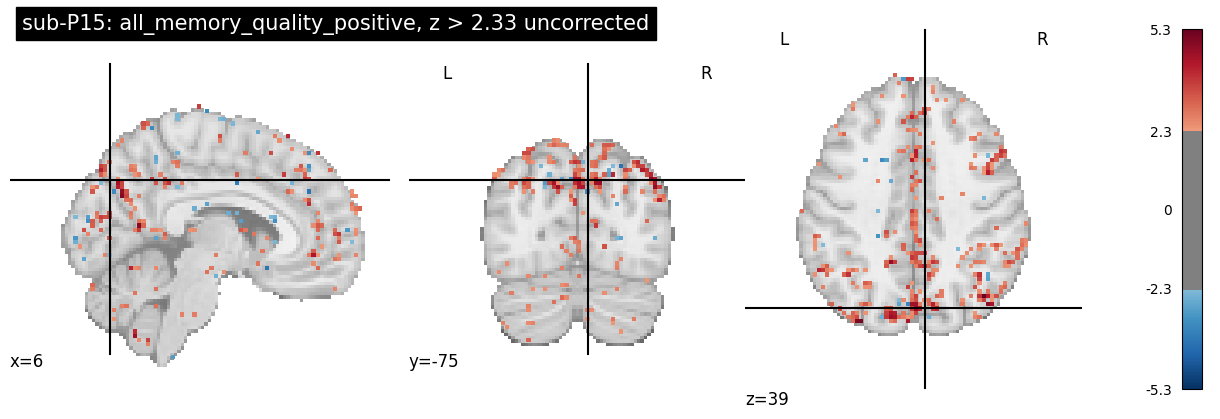

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/first_level/sub-P15_all_memory_quality_positive_uncorrected_z2.33.png


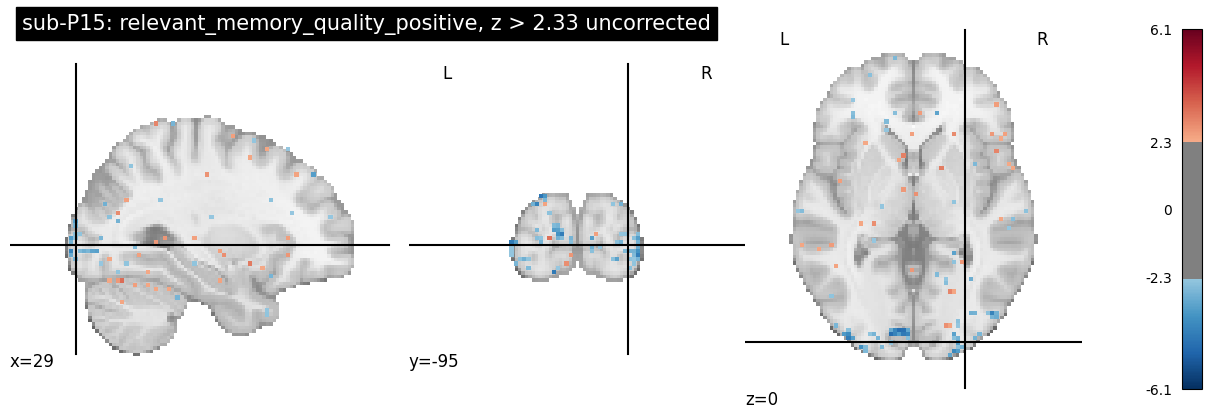

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/first_level/sub-P15_relevant_memory_quality_positive_uncorrected_z2.33.png


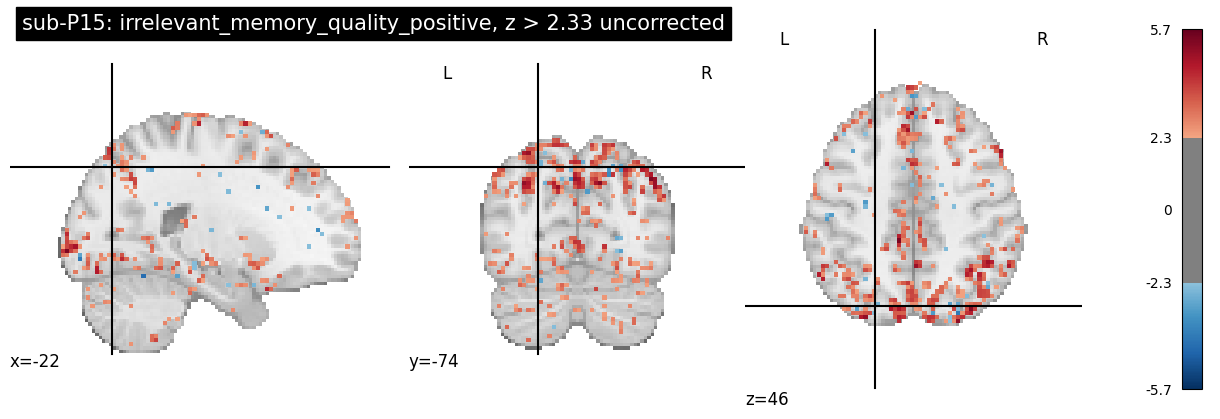

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/first_level/sub-P15_irrelevant_memory_quality_positive_uncorrected_z2.33.png


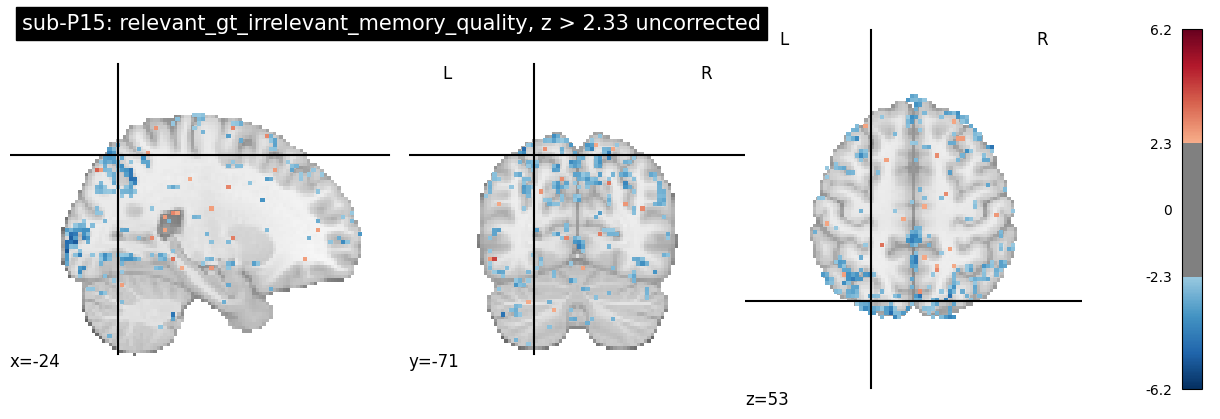

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/first_level/sub-P15_relevant_gt_irrelevant_memory_quality_uncorrected_z2.33.png


In [30]:
# ============================================================
# 28. Plot single-subject uncorrected contrast maps
# ============================================================

# Uncorrected exploratory z-threshold.
# Approximate two-sided p < 0.01 corresponds to |z| > 2.58.
# For a directional positive effect, z > 2.33 corresponds approximately to one-sided p < 0.01.
EXPLORATORY_Z_THRESHOLD = 2.33

for contrast_name, outputs in single_glm_result["contrast_outputs"].items():
    z_map = outputs["z_map"]
    
    fig = plt.figure(figsize=(12, 4))
    
    display = plot_stat_map(
        z_map,
        threshold=EXPLORATORY_Z_THRESHOLD,
        display_mode="ortho",
        cut_coords=None,
        title=f"{test_glm_subject}: {contrast_name}, z > {EXPLORATORY_Z_THRESHOLD} uncorrected",
        figure=fig,
    )
    
    out_path = FIRST_LEVEL_FIG_DIR / f"{test_glm_subject}_{contrast_name}_uncorrected_z{EXPLORATORY_Z_THRESHOLD}.png"
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    
    print("Saved:", out_path)

In [31]:
# ============================================================
# 29. Run primary first-level GLM for all included subjects
# ============================================================

from datetime import datetime
import traceback

subjects_to_run = primary_subjects_final.copy()

print("Running first-level GLM for primary subjects")
print("=" * 80)
print("Number of subjects:", len(subjects_to_run))
print(subjects_to_run)

first_level_qc_rows = []
first_level_failures = []

for i, subject in enumerate(subjects_to_run, start=1):
    print("\n" + "=" * 80)
    print(f"[{i}/{len(subjects_to_run)}] Running {subject}")
    print(datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
    
    try:
        result = fit_first_level_subject(
            subject,
            save_design=True,
            save_maps=True,
        )
        
        design_matrix = result["design_matrix"]
        event_cols = [
            col for col in design_matrix.columns
            if col.startswith("old_") or col == "new_image"
        ]
        
        row = {
            "subject": subject,
            "status": "success",
            "n_scans": result["n_scans"],
            "tr": result["tr"],
            "n_design_columns": design_matrix.shape[1],
            "n_event_columns": len(event_cols),
            "event_columns": ";".join(event_cols),
            "has_new_image": "new_image" in design_matrix.columns,
            "has_old_relevant_memory_quality": "old_relevant_memory_quality" in design_matrix.columns,
            "has_old_irrelevant_memory_quality": "old_irrelevant_memory_quality" in design_matrix.columns,
            "has_old_relevant_valid_main": "old_relevant_valid_main" in design_matrix.columns,
            "has_old_irrelevant_valid_main": "old_irrelevant_valid_main" in design_matrix.columns,
            "has_old_seen_water_no_spatial_recall": "old_seen_water_no_spatial_recall" in design_matrix.columns,
            "has_old_other_no_memory_quality": "old_other_no_memory_quality" in design_matrix.columns,
        }
        
        for contrast_name, outputs in result["contrast_outputs"].items():
            row[f"{contrast_name}_zmap_exists"] = outputs["z_path"].exists()
            row[f"{contrast_name}_effect_exists"] = outputs["effect_path"].exists()
        
        first_level_qc_rows.append(row)
        
        print(f"{subject}: success")
        print("Design matrix:", design_matrix.shape)
        print("Event columns:", event_cols)
        
    except Exception as exc:
        print(f"{subject}: FAILED")
        print(str(exc))
        
        first_level_failures.append({
            "subject": subject,
            "error": str(exc),
            "traceback": traceback.format_exc(),
        })
        
        first_level_qc_rows.append({
            "subject": subject,
            "status": "failed",
            "error": str(exc),
        })

first_level_qc_df = pd.DataFrame(first_level_qc_rows)
first_level_failures_df = pd.DataFrame(first_level_failures)

first_level_qc_path = TABLE_DIR / "first_level_primary_glm_qc.csv"
first_level_failures_path = TABLE_DIR / "first_level_primary_glm_failures.csv"

first_level_qc_df.to_csv(first_level_qc_path, index=False)
first_level_failures_df.to_csv(first_level_failures_path, index=False)

print("\n" + "=" * 80)
print("First-level GLM loop completed")
print("Successful subjects:", (first_level_qc_df["status"] == "success").sum())
print("Failed subjects:", (first_level_qc_df["status"] == "failed").sum())

display(first_level_qc_df)

if len(first_level_failures_df) > 0:
    print("\nFailures:")
    display(first_level_failures_df)

print("\nSaved:")
print(first_level_qc_path)
print(first_level_failures_path)

Running first-level GLM for primary subjects
Number of subjects: 28
['sub-P10', 'sub-P12', 'sub-P13', 'sub-P14', 'sub-P15', 'sub-P16', 'sub-P17', 'sub-P18', 'sub-P19', 'sub-P21', 'sub-P22', 'sub-P23', 'sub-P25', 'sub-P27', 'sub-P31', 'sub-P34', 'sub-P35', 'sub-P36', 'sub-P37', 'sub-P41', 'sub-P42', 'sub-P43', 'sub-P44', 'sub-P45', 'sub-P47', 'sub-P48', 'sub-P50', 'sub-P51']

[1/28] Running sub-P10
2026-06-05 10:53:25
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
sub-P10: success
Design matrix: (1994, 72)
Event columns: ['new_image', 'old_irrelevant_memory_quality', 'old_irrelevant_valid_main', 'old_other_no_memory_quality', 'old_relevant_memory_quality', 'old_relevant_valid_main']

[2/28] Running sub-P12
2026-06-05 10:54:58
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
sub-P12: success
Design matrix: (1954, 71)
Event columns: ['new_image', 'old_irrelevant_memory_quality', 'old_irrelevant_valid_m

TypeError: 'OrthoSlicer' object is not callable

In [33]:
# ============================================================
# Fix overwritten display() and recover first-level QC outputs
# Robust version: handles empty failures file
# ============================================================

from IPython.display import display

# Remove accidental variable shadowing from earlier plot_stat_map cell
if "display" in globals() and not callable(globals()["display"]):
    del globals()["display"]

from IPython.display import display

first_level_qc_path = TABLE_DIR / "first_level_primary_glm_qc.csv"
first_level_failures_path = TABLE_DIR / "first_level_primary_glm_failures.csv"

# Read QC table
first_level_qc_df = pd.read_csv(first_level_qc_path)

# Read failures table only if it is non-empty and parseable
try:
    if first_level_failures_path.exists() and first_level_failures_path.stat().st_size > 0:
        first_level_failures_df = pd.read_csv(first_level_failures_path)
    else:
        first_level_failures_df = pd.DataFrame()
except pd.errors.EmptyDataError:
    first_level_failures_df = pd.DataFrame()

print("Recovered first-level QC table")
print("=" * 80)
print("Successful subjects:", (first_level_qc_df["status"] == "success").sum())
print("Failed subjects:", (first_level_qc_df["status"] == "failed").sum())

display(first_level_qc_df)

if len(first_level_failures_df) > 0:
    print("\nFailures:")
    display(first_level_failures_df)
else:
    print("\nNo failures.")

Recovered first-level QC table
Successful subjects: 28
Failed subjects: 0


,subject,status,n_scans,tr,n_design_columns,n_event_columns,event_columns,has_new_image,has_old_relevant_memory_quality,has_old_irrelevant_memory_quality,has_old_relevant_valid_main,has_old_irrelevant_valid_main,has_old_seen_water_no_spatial_recall,has_old_other_no_memory_quality,all_memory_quality_positive_zmap_exists,all_memory_quality_positive_effect_exists,relevant_memory_quality_positive_zmap_exists,relevant_memory_quality_positive_effect_exists,irrelevant_memory_quality_positive_zmap_exists,irrelevant_memory_quality_positive_effect_exists,relevant_gt_irrelevant_memory_quality_zmap_exists,relevant_gt_irrelevant_memory_quality_effect_exists
0,sub-P10,success,1994,1.3,72,6,new_image;old_irrelevant_memory_quality;old_ir...,True,True,True,True,True,False,True,True,True,True,True,True,True,True,True
1,sub-P12,success,1954,1.3,71,6,new_image;old_irrelevant_memory_quality;old_ir...,True,True,True,True,True,False,True,True,True,True,True,True,True,True,True
2,sub-P13,success,1957,1.3,71,6,new_image;old_irrelevant_memory_quality;old_ir...,True,True,True,True,True,False,True,True,True,True,True,True,True,True,True
3,sub-P14,success,1922,1.3,71,6,new_image;old_irrelevant_memory_quality;old_ir...,True,True,True,True,True,False,True,True,True,True,True,True,True,True,True
4,sub-P15,success,1995,1.3,72,6,new_image;old_irrelevant_memory_quality;old_ir...,True,True,True,True,True,True,False,True,True,True,True,True,True,True,True
5,sub-P16,success,1955,1.3,72,7,new_image;old_irrelevant_memory_quality;old_ir...,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
6,sub-P17,success,1946,1.3,71,6,new_image;old_irrelevant_memory_quality;old_ir...,True,True,True,True,True,False,True,True,True,True,True,True,True,True,True
7,sub-P18,success,1993,1.3,73,7,new_image;old_irrelevant_memory_quality;old_ir...,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
8,sub-P19,success,1945,1.3,72,7,new_image;old_irrelevant_memory_quality;old_ir...,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
9,sub-P21,success,1961,1.3,72,7,new_image;old_irrelevant_memory_quality;old_ir...,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True



No failures.


In [34]:
# ============================================================
# 30. Verify first-level contrast map availability
# ============================================================

subjects_to_run = primary_subjects_final.copy()

map_check_rows = []

for subject in subjects_to_run:
    for contrast_name in PRIMARY_CONTRASTS.keys():
        z_path = FIRST_LEVEL_MAPS_DIR / f"{subject}_{contrast_name}_zmap.nii.gz"
        effect_path = FIRST_LEVEL_MAPS_DIR / f"{subject}_{contrast_name}_effect.nii.gz"
        
        map_check_rows.append({
            "subject": subject,
            "contrast": contrast_name,
            "z_map_exists": z_path.exists(),
            "effect_map_exists": effect_path.exists(),
            "z_map_path": str(z_path),
            "effect_map_path": str(effect_path),
        })

first_level_map_check = pd.DataFrame(map_check_rows)

print("First-level map availability:")
display(
    first_level_map_check
    .groupby("contrast")
    .agg(
        n_subjects=("subject", "count"),
        n_z_maps=("z_map_exists", "sum"),
        n_effect_maps=("effect_map_exists", "sum"),
    )
    .reset_index()
)

missing_maps = first_level_map_check.loc[
    (~first_level_map_check["z_map_exists"])
    | (~first_level_map_check["effect_map_exists"])
].copy()

print("\nMissing maps:")
display(missing_maps)

map_check_path = TABLE_DIR / "first_level_primary_glm_map_availability.csv"
first_level_map_check.to_csv(map_check_path, index=False)

print("\nSaved:")
print(map_check_path)

First-level map availability:


,contrast,n_subjects,n_z_maps,n_effect_maps
0,all_memory_quality_positive,28,28,28
1,irrelevant_memory_quality_positive,28,28,28
2,relevant_gt_irrelevant_memory_quality,28,28,28
3,relevant_memory_quality_positive,28,28,28



Missing maps:


,subject,contrast,z_map_exists,effect_map_exists,z_map_path,effect_map_path



Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/first_level_primary_glm_map_availability.csv


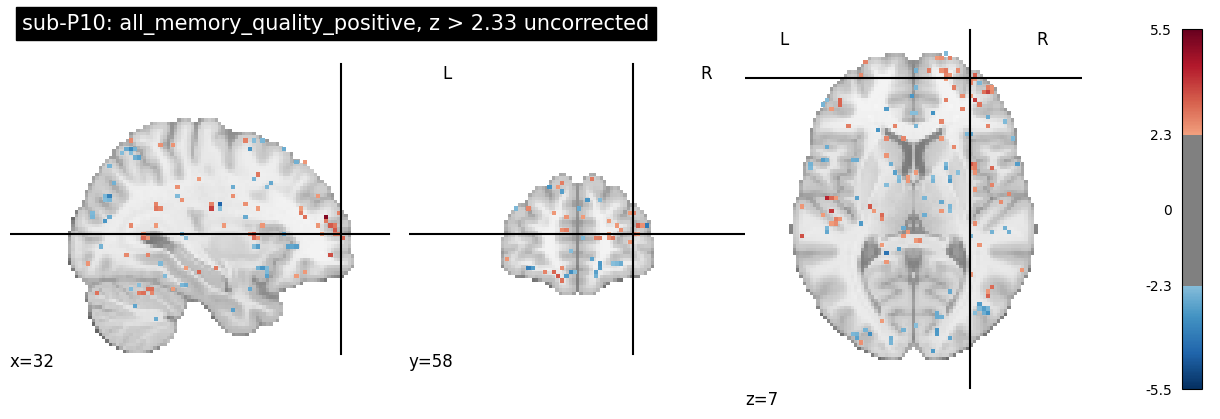

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/first_level/sub-P10_all_memory_quality_positive_visual_qc_uncorrected_z2.33.png


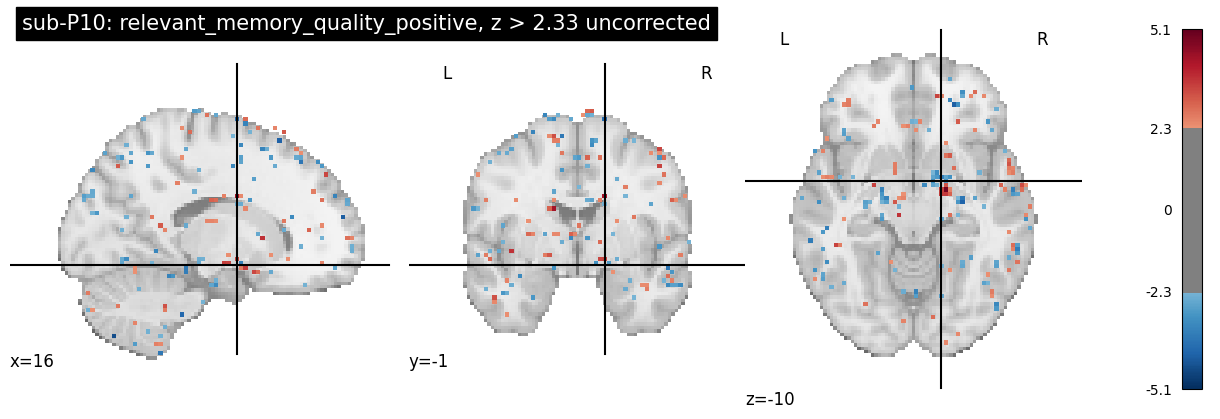

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/first_level/sub-P10_relevant_memory_quality_positive_visual_qc_uncorrected_z2.33.png


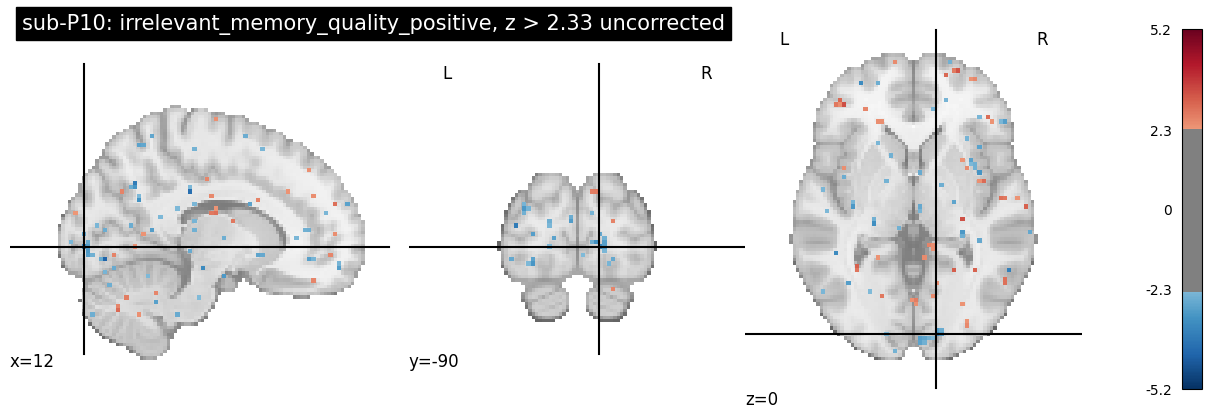

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/first_level/sub-P10_irrelevant_memory_quality_positive_visual_qc_uncorrected_z2.33.png


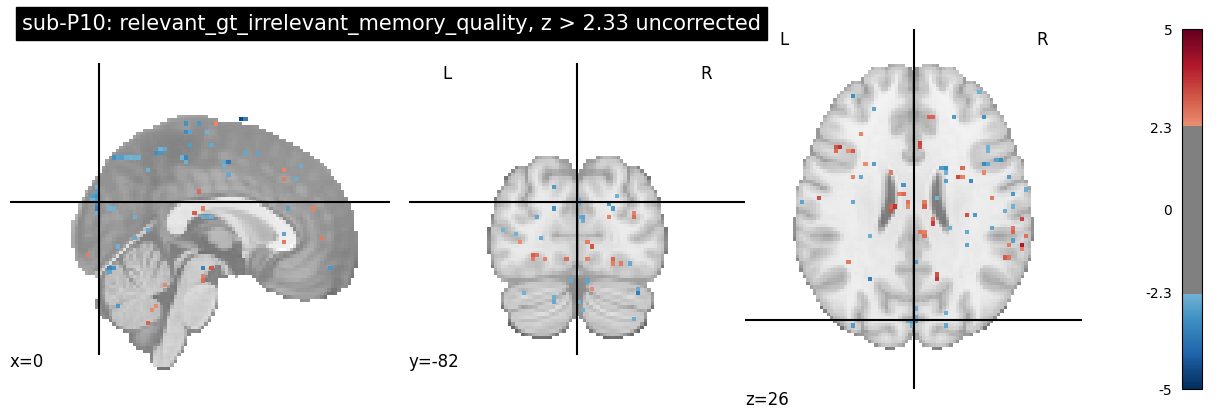

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/first_level/sub-P10_relevant_gt_irrelevant_memory_quality_visual_qc_uncorrected_z2.33.png


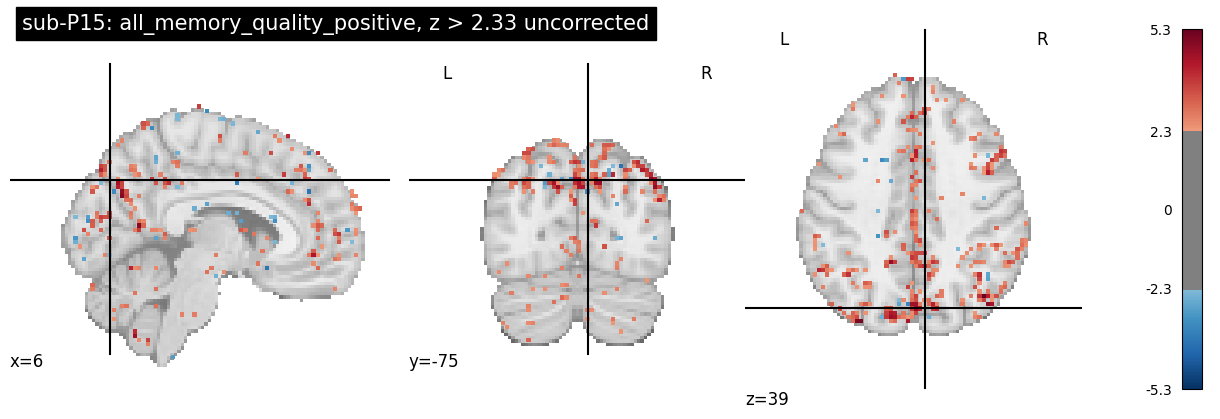

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/first_level/sub-P15_all_memory_quality_positive_visual_qc_uncorrected_z2.33.png


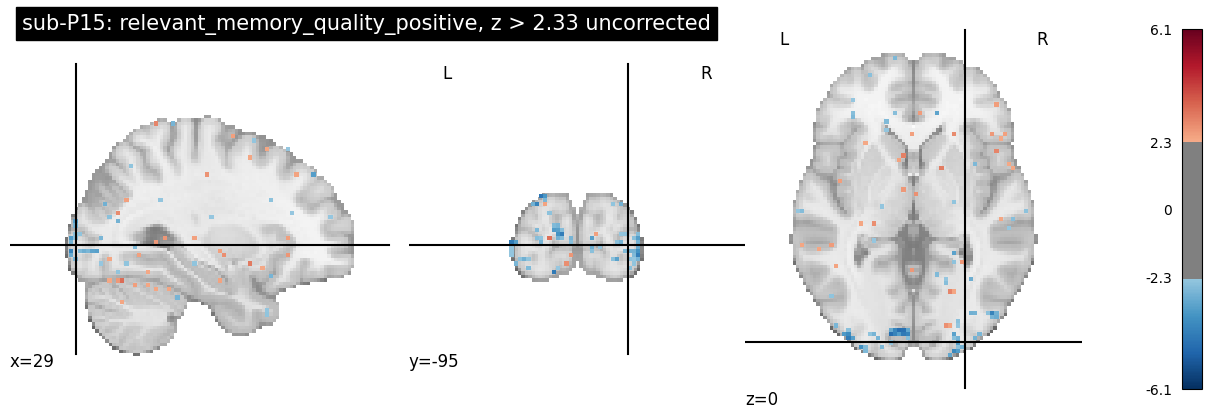

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/first_level/sub-P15_relevant_memory_quality_positive_visual_qc_uncorrected_z2.33.png


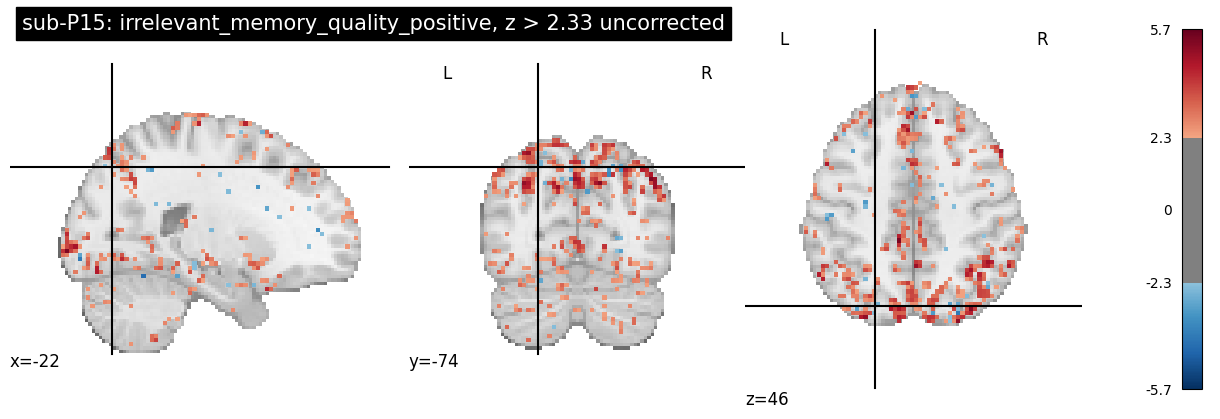

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/first_level/sub-P15_irrelevant_memory_quality_positive_visual_qc_uncorrected_z2.33.png


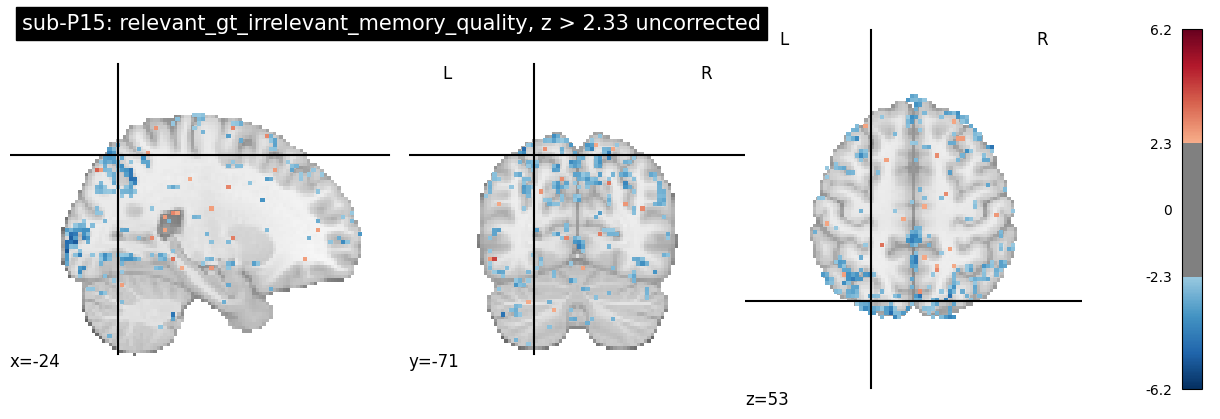

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/first_level/sub-P15_relevant_gt_irrelevant_memory_quality_visual_qc_uncorrected_z2.33.png


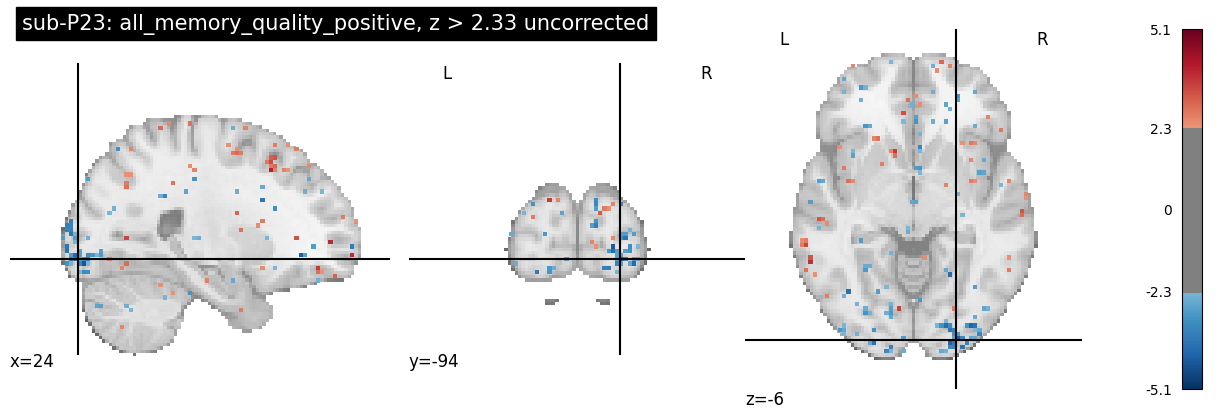

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/first_level/sub-P23_all_memory_quality_positive_visual_qc_uncorrected_z2.33.png


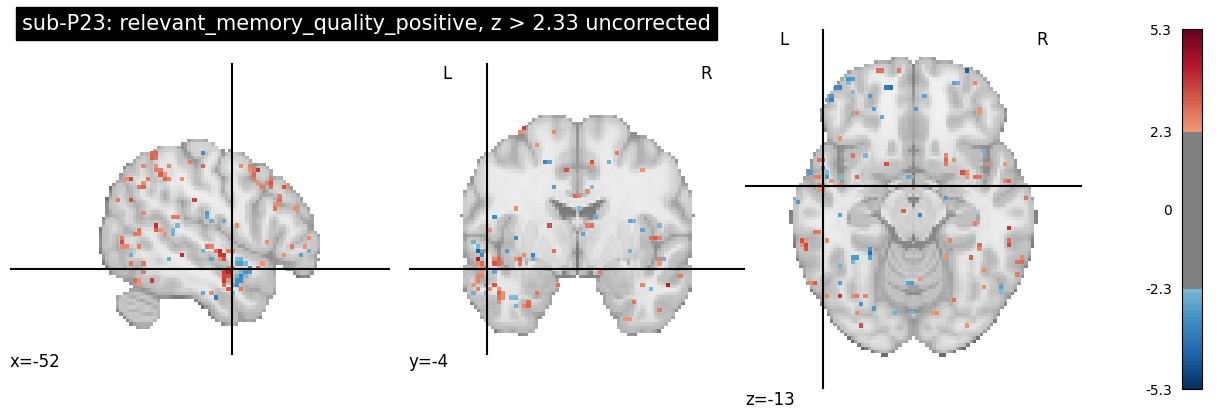

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/first_level/sub-P23_relevant_memory_quality_positive_visual_qc_uncorrected_z2.33.png


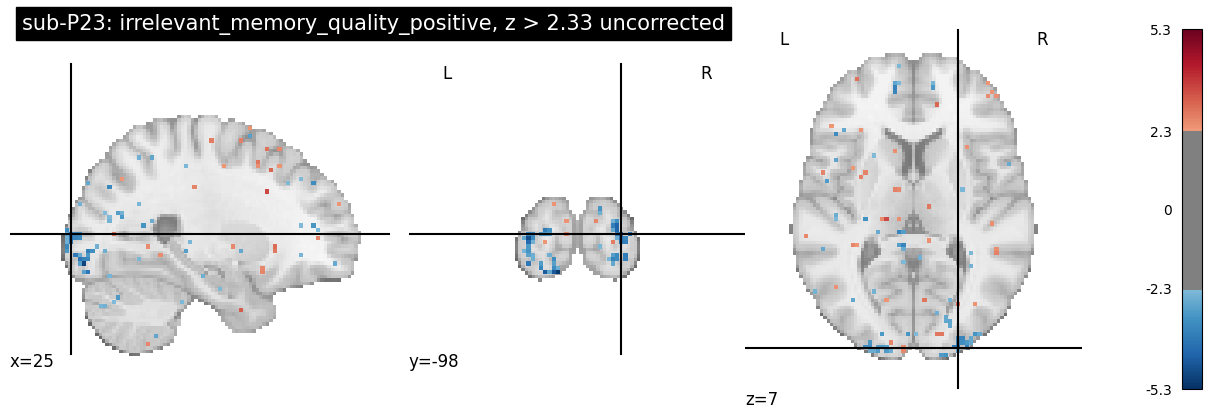

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/first_level/sub-P23_irrelevant_memory_quality_positive_visual_qc_uncorrected_z2.33.png


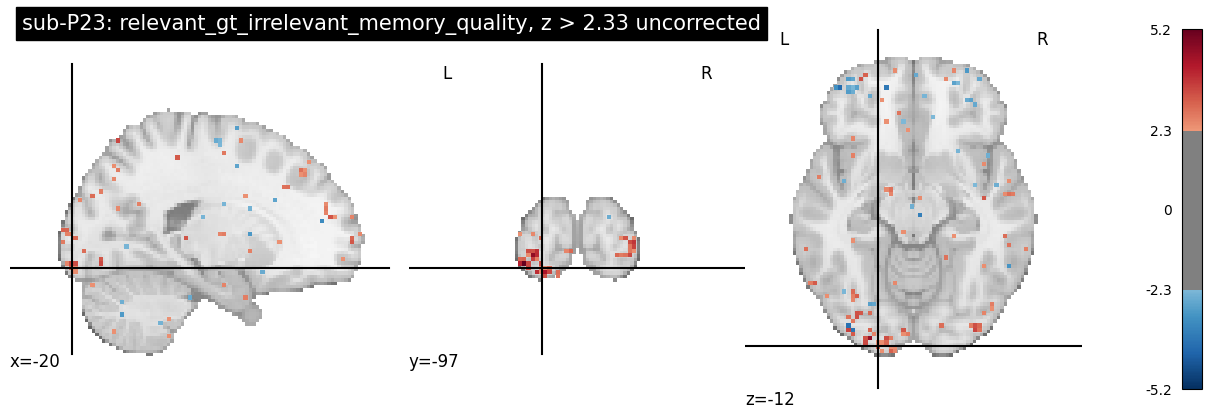

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/first_level/sub-P23_relevant_gt_irrelevant_memory_quality_visual_qc_uncorrected_z2.33.png


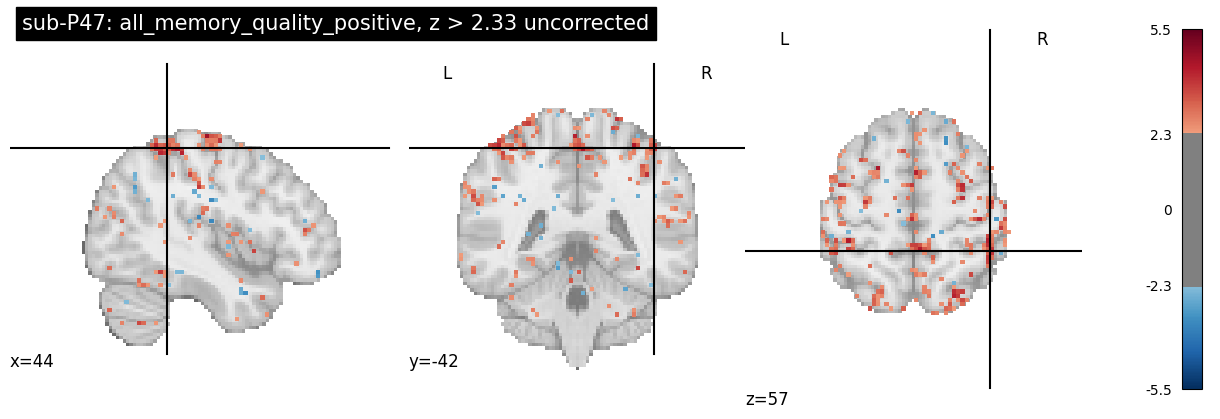

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/first_level/sub-P47_all_memory_quality_positive_visual_qc_uncorrected_z2.33.png


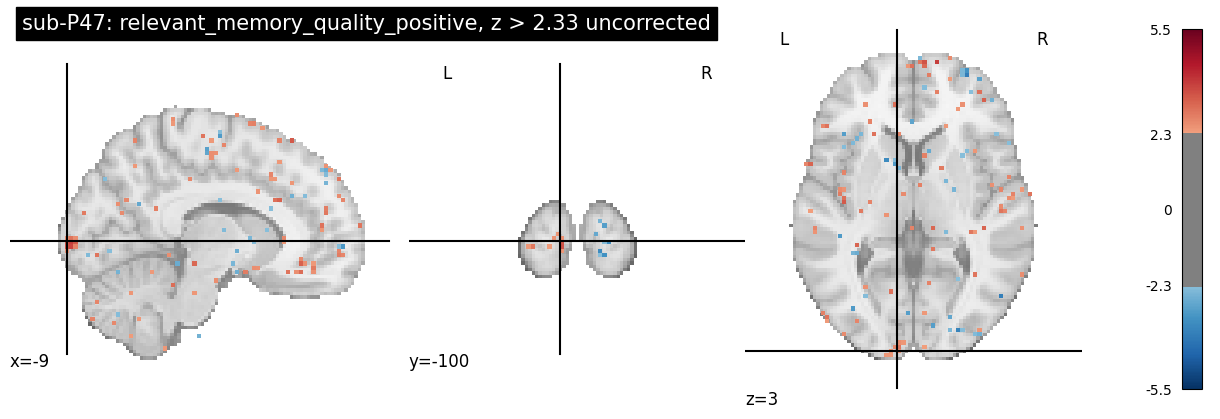

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/first_level/sub-P47_relevant_memory_quality_positive_visual_qc_uncorrected_z2.33.png


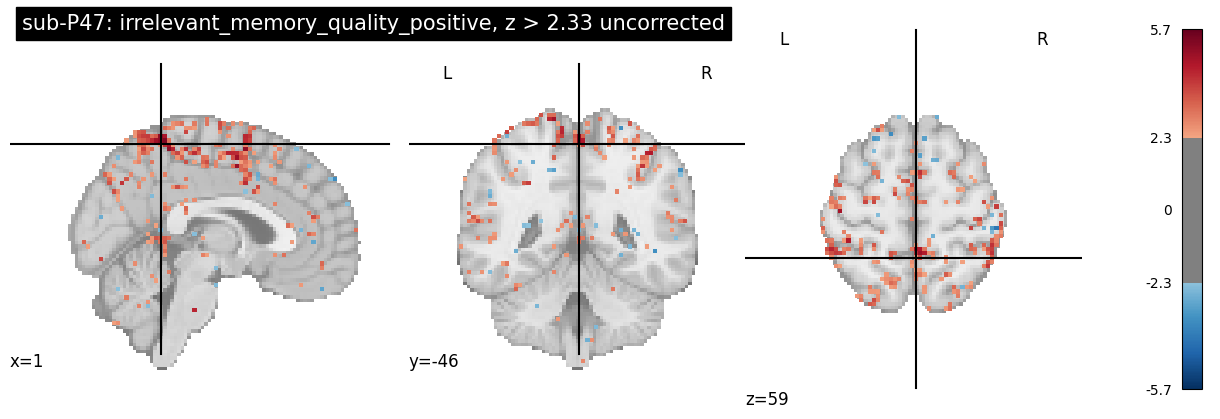

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/first_level/sub-P47_irrelevant_memory_quality_positive_visual_qc_uncorrected_z2.33.png


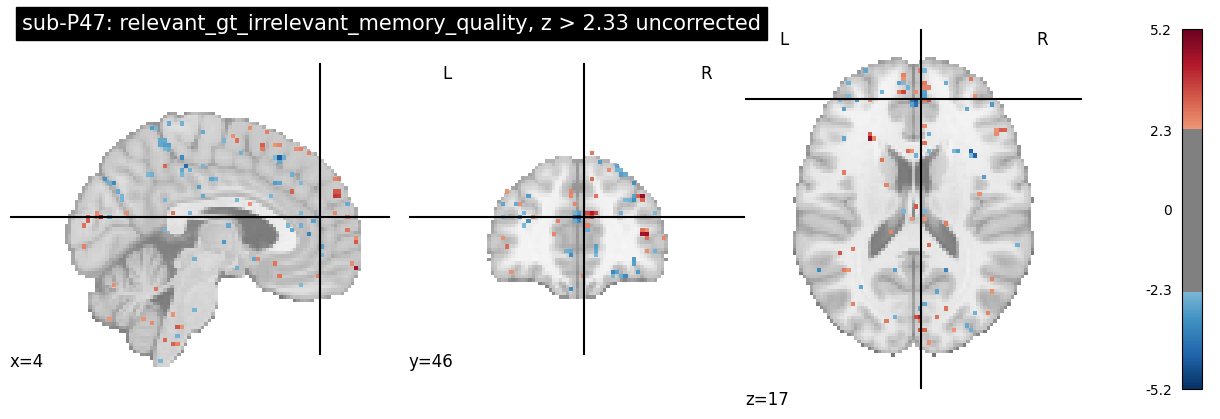

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/first_level/sub-P47_relevant_gt_irrelevant_memory_quality_visual_qc_uncorrected_z2.33.png


In [36]:
# ============================================================
# 31. Visual QC: uncorrected maps for selected subjects
# ============================================================

selected_subjects_for_visual_qc = [
    "sub-P10",
    "sub-P15",
    "sub-P23",
    "sub-P47",
]

EXPLORATORY_Z_THRESHOLD = 2.33

for subject in selected_subjects_for_visual_qc:
    if subject not in subjects_to_run:
        continue
    
    for contrast_name in PRIMARY_CONTRASTS.keys():
        z_path = FIRST_LEVEL_MAPS_DIR / f"{subject}_{contrast_name}_zmap.nii.gz"
        
        if not z_path.exists():
            print("Missing:", z_path)
            continue
        
        fig = plt.figure(figsize=(12, 4))
        
        plot_stat_map(
            str(z_path),
            threshold=EXPLORATORY_Z_THRESHOLD,
            display_mode="ortho",
            cut_coords=None,
            title=f"{subject}: {contrast_name}, z > {EXPLORATORY_Z_THRESHOLD} uncorrected",
            figure=fig,
        )
        
        out_path = FIRST_LEVEL_FIG_DIR / f"{subject}_{contrast_name}_visual_qc_uncorrected_z{EXPLORATORY_Z_THRESHOLD}.png"
        fig.savefig(out_path, dpi=200, bbox_inches="tight")
        plt.show()
        
        print("Saved:", out_path)

In [37]:
# ============================================================
# 32. Second-level GLM helper functions
# ============================================================

from nilearn.glm.second_level import SecondLevelModel
from nilearn.plotting import plot_stat_map
from nilearn.glm import threshold_stats_img
import nibabel as nib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

SECOND_LEVEL_DIR = OUT_DIR / "second_level"
SECOND_LEVEL_MAPS_DIR = SECOND_LEVEL_DIR / "maps"
SECOND_LEVEL_FIG_DIR = FIG_DIR / "second_level"

for path in [
    SECOND_LEVEL_DIR,
    SECOND_LEVEL_MAPS_DIR,
    SECOND_LEVEL_FIG_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)


def get_first_level_effect_map(subject, contrast_name):
    return FIRST_LEVEL_MAPS_DIR / f"{subject}_{contrast_name}_effect.nii.gz"


def get_first_level_z_map(subject, contrast_name):
    return FIRST_LEVEL_MAPS_DIR / f"{subject}_{contrast_name}_zmap.nii.gz"


def load_second_level_inputs(subjects, contrast_name, map_type="effect"):
    """
    Load first-level maps for a group-level one-sample test.
    
    map_type:
        "effect" is recommended for second-level GLM.
        "z" can be used only for visual QC, not primary inference.
    """
    map_paths = []
    missing = []
    
    for subject in subjects:
        if map_type == "effect":
            path = get_first_level_effect_map(subject, contrast_name)
        elif map_type == "z":
            path = get_first_level_z_map(subject, contrast_name)
        else:
            raise ValueError("map_type must be 'effect' or 'z'")
        
        if path.exists():
            map_paths.append(str(path))
        else:
            missing.append((subject, str(path)))
    
    if len(missing) > 0:
        raise FileNotFoundError(f"Missing maps for {contrast_name}: {missing}")
    
    design_matrix = pd.DataFrame(
        {"intercept": np.ones(len(map_paths))}
    )
    
    return map_paths, design_matrix


def fit_second_level_one_sample(
    subjects,
    contrast_name,
    map_type="effect",
    smoothing_fwhm=None,
):
    """
    Fit a second-level one-sample model:
    
    H0: mean contrast estimate across subjects = 0
    H1: mean contrast estimate across subjects > 0
    """
    map_paths, design_matrix = load_second_level_inputs(
        subjects=subjects,
        contrast_name=contrast_name,
        map_type=map_type,
    )
    
    second_level_model = SecondLevelModel(
        smoothing_fwhm=smoothing_fwhm,
        n_jobs=1,
    )
    
    second_level_model = second_level_model.fit(
        second_level_input=map_paths,
        design_matrix=design_matrix,
    )
    
    z_map = second_level_model.compute_contrast(
        second_level_contrast="intercept",
        output_type="z_score",
    )
    
    effect_map = second_level_model.compute_contrast(
        second_level_contrast="intercept",
        output_type="effect_size",
    )
    
    return {
        "contrast_name": contrast_name,
        "subjects": subjects,
        "map_paths": map_paths,
        "design_matrix": design_matrix,
        "model": second_level_model,
        "z_map": z_map,
        "effect_map": effect_map,
    }


print("Second-level helpers ready.")
print("Contrasts available:")
for contrast_name in PRIMARY_CONTRASTS.keys():
    print("  -", contrast_name)

Second-level helpers ready.
Contrasts available:
  - all_memory_quality_positive
  - relevant_memory_quality_positive
  - irrelevant_memory_quality_positive
  - relevant_gt_irrelevant_memory_quality


In [38]:
# ============================================================
# 33. Run second-level one-sample GLM for primary contrasts
# ============================================================

second_level_subjects = primary_subjects_final.copy()

second_level_results = {}
second_level_qc_rows = []

print("Running second-level GLM")
print("=" * 80)
print("Subjects:", len(second_level_subjects))
print(second_level_subjects)

for contrast_name in PRIMARY_CONTRASTS.keys():
    print("\n" + "=" * 80)
    print("Second-level contrast:", contrast_name)
    
    result = fit_second_level_one_sample(
        subjects=second_level_subjects,
        contrast_name=contrast_name,
        map_type="effect",
        smoothing_fwhm=None,
    )
    
    z_path = SECOND_LEVEL_MAPS_DIR / f"group_primary_{contrast_name}_zmap.nii.gz"
    effect_path = SECOND_LEVEL_MAPS_DIR / f"group_primary_{contrast_name}_effect.nii.gz"
    
    result["z_map"].to_filename(z_path)
    result["effect_map"].to_filename(effect_path)
    
    second_level_results[contrast_name] = result
    
    second_level_qc_rows.append({
        "contrast": contrast_name,
        "n_subjects": len(second_level_subjects),
        "input_map_type": "effect_size",
        "z_map_path": str(z_path),
        "effect_map_path": str(effect_path),
        "z_map_exists": z_path.exists(),
        "effect_map_exists": effect_path.exists(),
    })
    
    print("Saved:")
    print("  z-map:     ", z_path)
    print("  effect-map:", effect_path)

second_level_qc_df = pd.DataFrame(second_level_qc_rows)

second_level_qc_path = TABLE_DIR / "second_level_primary_glm_qc.csv"
second_level_qc_df.to_csv(second_level_qc_path, index=False)

print("\nSecond-level QC:")
display(second_level_qc_df)

print("\nSaved:")
print(second_level_qc_path)

Running second-level GLM
Subjects: 28
['sub-P10', 'sub-P12', 'sub-P13', 'sub-P14', 'sub-P15', 'sub-P16', 'sub-P17', 'sub-P18', 'sub-P19', 'sub-P21', 'sub-P22', 'sub-P23', 'sub-P25', 'sub-P27', 'sub-P31', 'sub-P34', 'sub-P35', 'sub-P36', 'sub-P37', 'sub-P41', 'sub-P42', 'sub-P43', 'sub-P44', 'sub-P45', 'sub-P47', 'sub-P48', 'sub-P50', 'sub-P51']

Second-level contrast: all_memory_quality_positive
Saved:
  z-map:      /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/second_level/maps/group_primary_all_memory_quality_positive_zmap.nii.gz
  effect-map: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/second_level/maps/group_primary_all_memory_quality_positive_effect.nii.gz

Second-level contrast: relevant_memory_quality_positive
Saved:
  z-map:      /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_qu

,contrast,n_subjects,input_map_type,z_map_path,effect_map_path,z_map_exists,effect_map_exists
0,all_memory_quality_positive,28,effect_size,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True
1,relevant_memory_quality_positive,28,effect_size,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True
2,irrelevant_memory_quality_positive,28,effect_size,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True
3,relevant_gt_irrelevant_memory_quality,28,effect_size,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True



Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/second_level_primary_glm_qc.csv


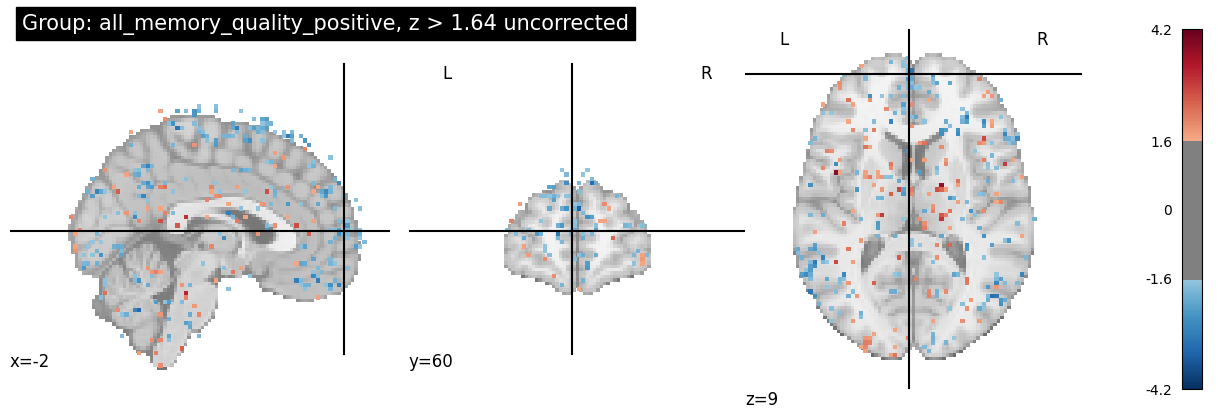

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/second_level/group_primary_all_memory_quality_positive_uncorrected_z1.64.png


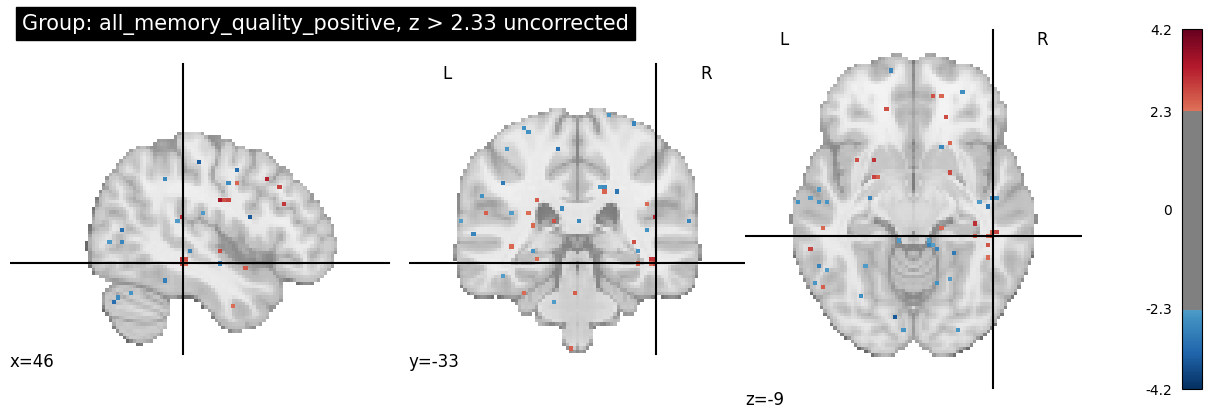

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/second_level/group_primary_all_memory_quality_positive_uncorrected_z2.33.png


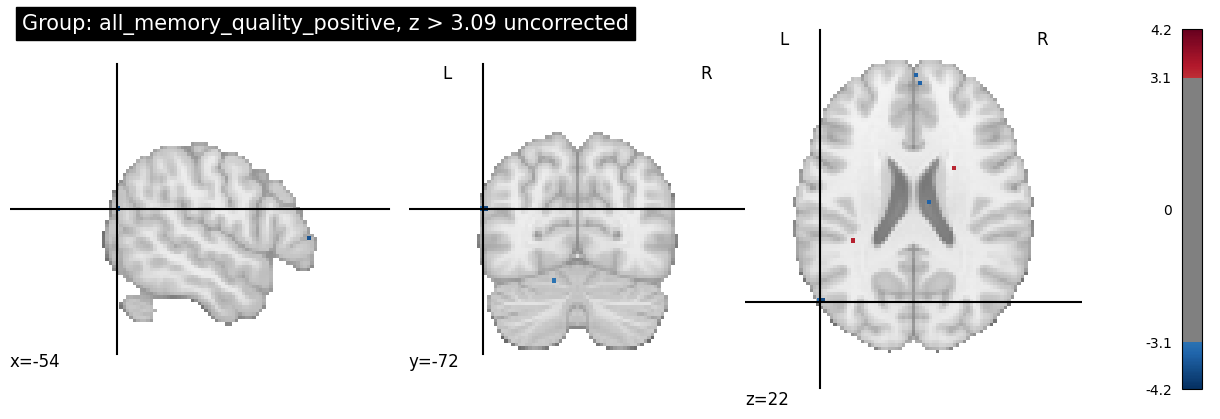

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/second_level/group_primary_all_memory_quality_positive_uncorrected_z3.09.png


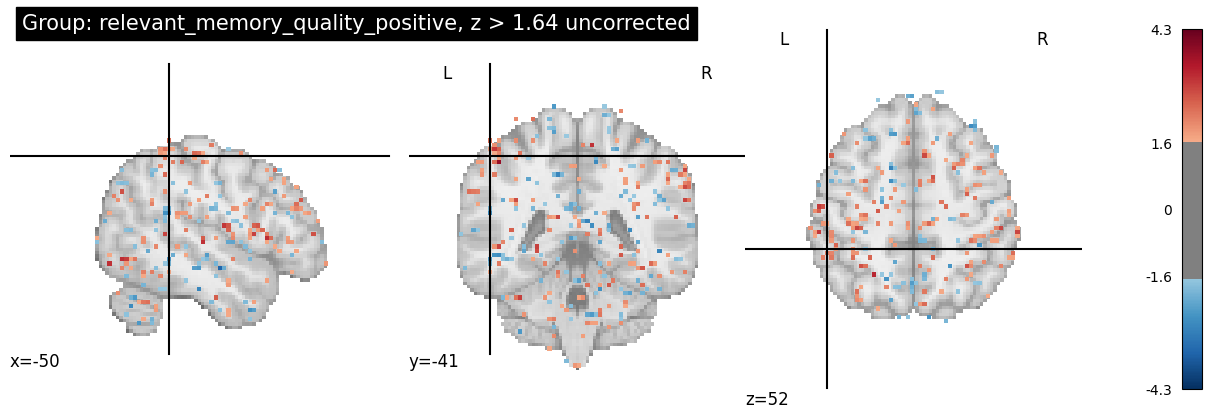

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/second_level/group_primary_relevant_memory_quality_positive_uncorrected_z1.64.png


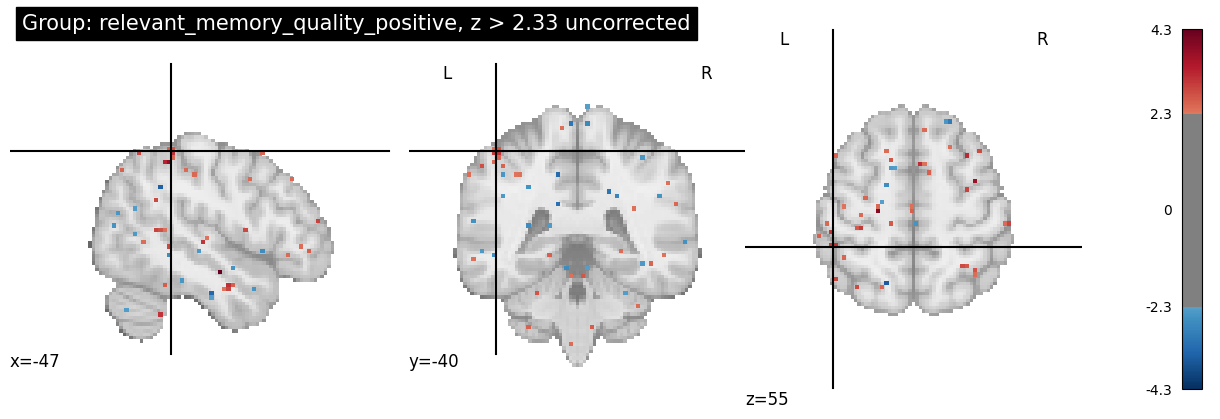

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/second_level/group_primary_relevant_memory_quality_positive_uncorrected_z2.33.png


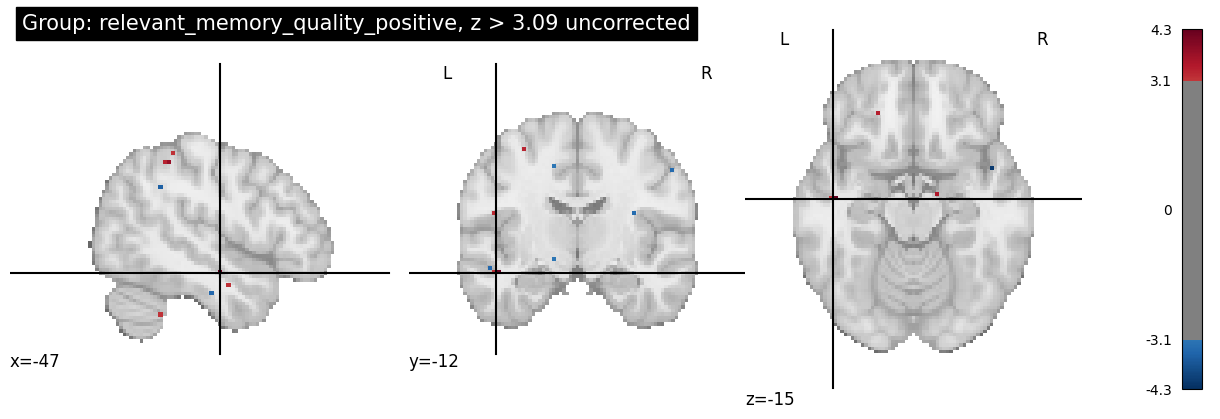

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/second_level/group_primary_relevant_memory_quality_positive_uncorrected_z3.09.png


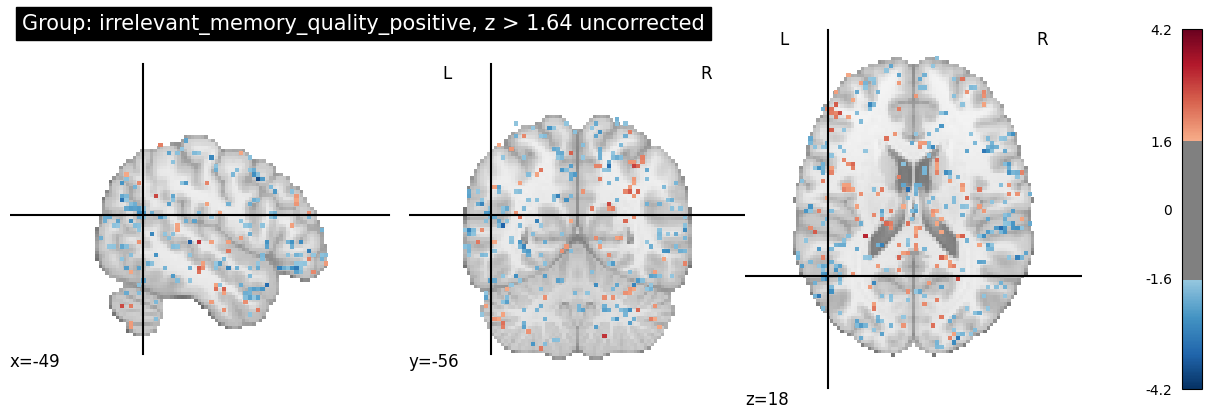

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/second_level/group_primary_irrelevant_memory_quality_positive_uncorrected_z1.64.png


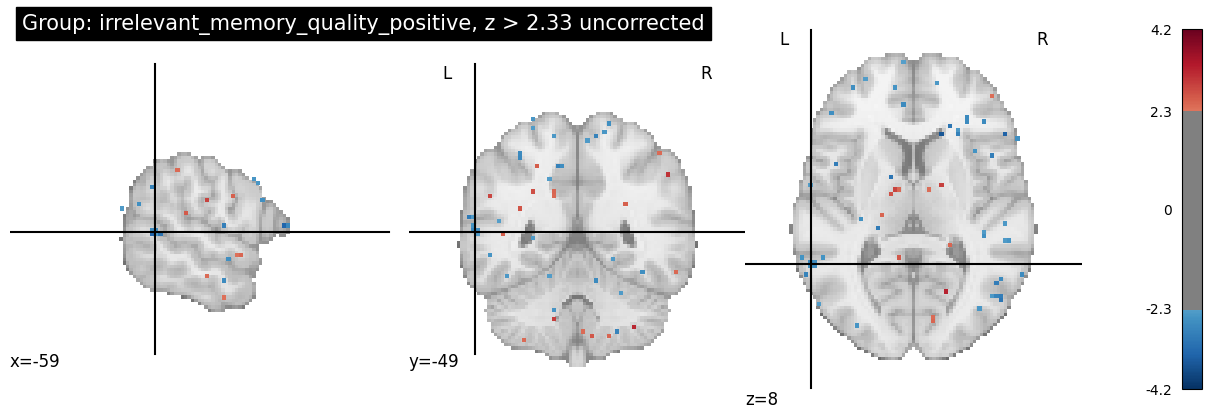

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/second_level/group_primary_irrelevant_memory_quality_positive_uncorrected_z2.33.png


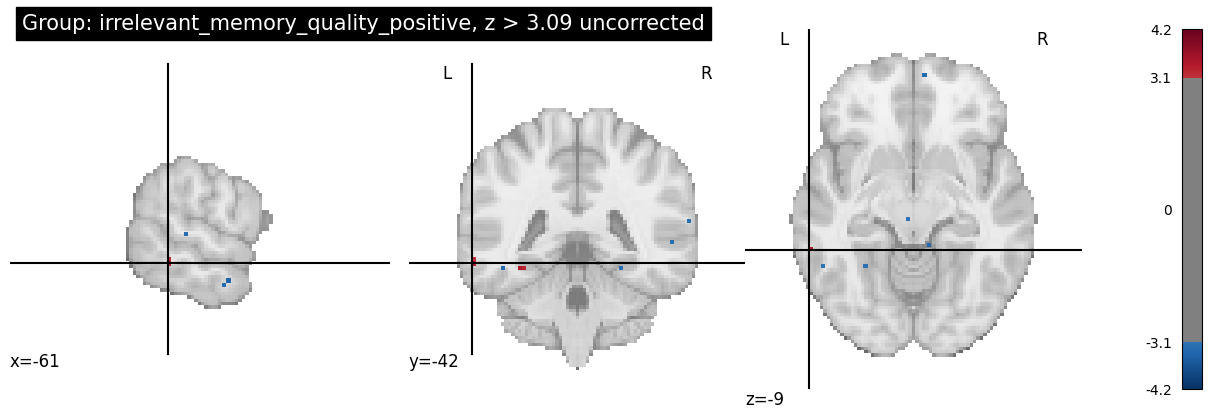

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/second_level/group_primary_irrelevant_memory_quality_positive_uncorrected_z3.09.png


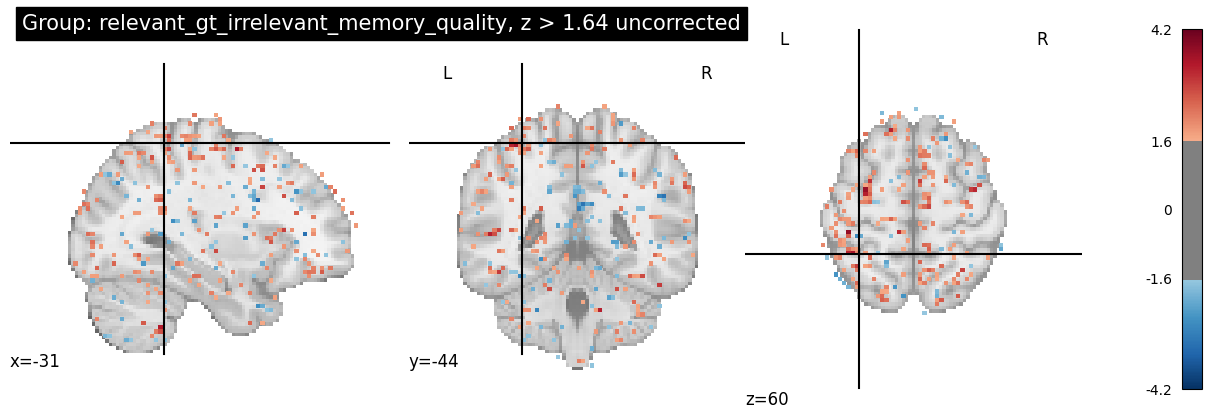

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/second_level/group_primary_relevant_gt_irrelevant_memory_quality_uncorrected_z1.64.png


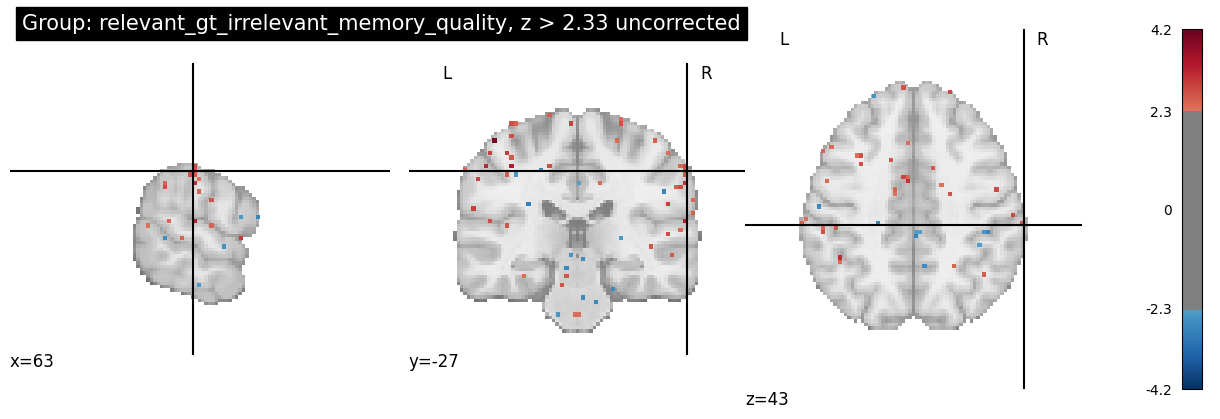

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/second_level/group_primary_relevant_gt_irrelevant_memory_quality_uncorrected_z2.33.png


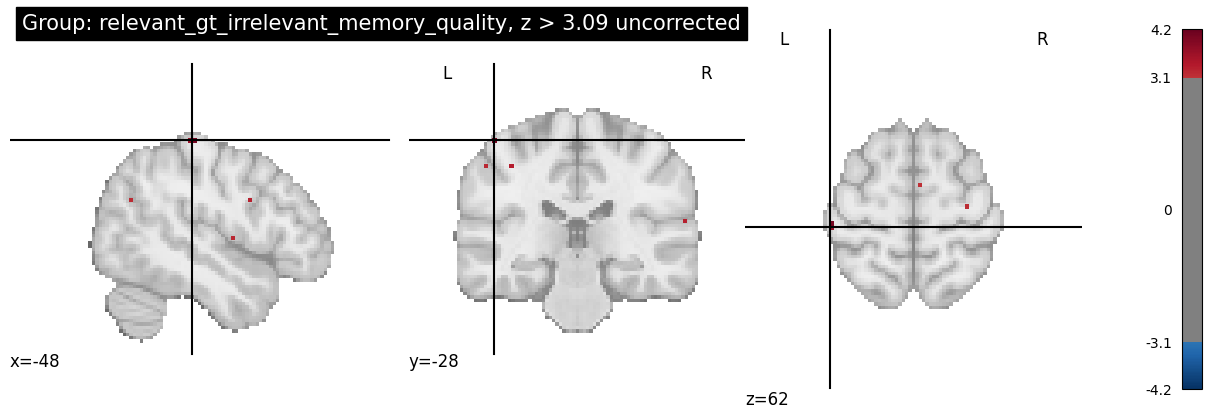

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/second_level/group_primary_relevant_gt_irrelevant_memory_quality_uncorrected_z3.09.png


In [39]:
# ============================================================
# 34. Plot exploratory uncorrected second-level maps
# ============================================================

# Directional exploratory thresholds:
# z > 1.64 ≈ one-sided p < 0.05
# z > 2.33 ≈ one-sided p < 0.01
# z > 3.09 ≈ one-sided p < 0.001

EXPLORATORY_GROUP_THRESHOLDS = [1.64, 2.33, 3.09]

for contrast_name, result in second_level_results.items():
    z_map = result["z_map"]
    
    for z_threshold in EXPLORATORY_GROUP_THRESHOLDS:
        fig = plt.figure(figsize=(12, 4))
        
        plot_stat_map(
            z_map,
            threshold=z_threshold,
            display_mode="ortho",
            cut_coords=None,
            title=f"Group: {contrast_name}, z > {z_threshold} uncorrected",
            figure=fig,
        )
        
        out_path = (
            SECOND_LEVEL_FIG_DIR
            / f"group_primary_{contrast_name}_uncorrected_z{z_threshold}.png"
        )
        
        fig.savefig(out_path, dpi=200, bbox_inches="tight")
        plt.show()
        
        print("Saved:", out_path)

In [40]:
# ============================================================
# 35. Extract cluster tables for exploratory group maps
# ============================================================

from nilearn.reporting import get_clusters_table

CLUSTER_TABLE_THRESHOLD = 2.33
CLUSTER_TABLE_MIN_DISTANCE = 8

cluster_table_rows = []

for contrast_name, result in second_level_results.items():
    z_map = result["z_map"]
    
    try:
        cluster_table = get_clusters_table(
            stat_img=z_map,
            stat_threshold=CLUSTER_TABLE_THRESHOLD,
            cluster_threshold=0,
            min_distance=CLUSTER_TABLE_MIN_DISTANCE,
        )
        
        cluster_table["contrast"] = contrast_name
        cluster_table["threshold"] = CLUSTER_TABLE_THRESHOLD
        
        cluster_table_path = (
            TABLE_DIR
            / f"second_level_cluster_table_{contrast_name}_z{CLUSTER_TABLE_THRESHOLD}.csv"
        )
        cluster_table.to_csv(cluster_table_path, index=False)
        
        print("\n" + "=" * 80)
        print(f"Cluster table: {contrast_name}, z > {CLUSTER_TABLE_THRESHOLD}")
        display(cluster_table.head(20))
        print("Saved:", cluster_table_path)
        
        cluster_table_rows.append({
            "contrast": contrast_name,
            "threshold": CLUSTER_TABLE_THRESHOLD,
            "n_peaks_or_clusters": len(cluster_table),
            "cluster_table_path": str(cluster_table_path),
        })
    
    except Exception as exc:
        print(f"Could not create cluster table for {contrast_name}: {exc}")
        cluster_table_rows.append({
            "contrast": contrast_name,
            "threshold": CLUSTER_TABLE_THRESHOLD,
            "n_peaks_or_clusters": np.nan,
            "cluster_table_path": None,
            "error": str(exc),
        })

cluster_table_summary_df = pd.DataFrame(cluster_table_rows)

cluster_table_summary_path = TABLE_DIR / "second_level_cluster_table_summary.csv"
cluster_table_summary_df.to_csv(cluster_table_summary_path, index=False)

print("\nCluster table summary:")
display(cluster_table_summary_df)

print("\nSaved:")
print(cluster_table_summary_path)


Cluster table: all_memory_quality_positive, z > 2.33


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),contrast,threshold
0,1,-36.0,45.5,17.0,4.194462,31,all_memory_quality_positive,2.33
1,2,-46.0,-12.0,-15.5,4.067725,31,all_memory_quality_positive,2.33
2,3,6.5,-47.0,-20.5,3.832017,15,all_memory_quality_positive,2.33
3,4,-46.0,3.0,9.5,3.740629,31,all_memory_quality_positive,2.33
4,5,-43.5,0.5,-8.0,3.699252,15,all_memory_quality_positive,2.33
5,6,16.5,-4.5,9.5,3.698364,46,all_memory_quality_positive,2.33
6,7,39.0,25.5,14.5,3.648855,31,all_memory_quality_positive,2.33
7,8,26.5,23.0,42.0,3.621889,31,all_memory_quality_positive,2.33
8,9,-21.0,-17.0,54.5,3.610650,31,all_memory_quality_positive,2.33
9,10,-28.5,-74.5,-35.5,3.572059,31,all_memory_quality_positive,2.33


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/second_level_cluster_table_all_memory_quality_positive_z2.33.csv

Cluster table: relevant_memory_quality_positive, z > 2.33


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),contrast,threshold
0,1,6.5,3.0,-3.0,4.300826,31,relevant_memory_quality_positive,2.33
1,2,-46.0,-12.0,-15.5,4.284014,31,relevant_memory_quality_positive,2.33
2,3,14.0,40.5,-13.0,4.034231,31,relevant_memory_quality_positive,2.33
3,4,56.5,-24.5,39.5,3.954976,31,relevant_memory_quality_positive,2.33
4,5,-21.0,-19.5,54.5,3.934639,46,relevant_memory_quality_positive,2.33
5,6,26.5,-89.5,19.5,3.756294,15,relevant_memory_quality_positive,2.33
6,7,-46.0,-42.0,49.5,3.743535,78,relevant_memory_quality_positive,2.33
7,8,39.0,8.0,9.5,3.738681,15,relevant_memory_quality_positive,2.33
8,9,-31.0,25.5,29.5,3.711483,15,relevant_memory_quality_positive,2.33
9,10,36.5,-2.0,54.5,3.706430,15,relevant_memory_quality_positive,2.33


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/second_level_cluster_table_relevant_memory_quality_positive_z2.33.csv

Cluster table: irrelevant_memory_quality_positive, z > 2.33


...

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/second_level_cluster_table_irrelevant_memory_quality_positive_z2.33.csv

Cluster table: relevant_gt_irrelevant_memory_quality, z > 2.33


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),contrast,threshold
0,1,-48.5,-27.0,62.0,4.028652,31,relevant_gt_irrelevant_memory_quality,2.33
1,2,-41.0,-22.0,57.0,3.933880,15,relevant_gt_irrelevant_memory_quality,2.33
2,3,-16.0,15.5,-0.5,3.920499,15,relevant_gt_irrelevant_memory_quality,2.33
3,4,1.5,10.5,-5.5,3.889712,15,relevant_gt_irrelevant_memory_quality,2.33
4,5,51.5,5.5,-40.5,3.834032,15,relevant_gt_irrelevant_memory_quality,2.33
5,6,-23.5,-42.0,-3.0,3.774437,31,relevant_gt_irrelevant_memory_quality,2.33
6,7,-36.0,-9.5,-43.0,3.769258,15,relevant_gt_irrelevant_memory_quality,2.33
7,8,-33.5,-29.5,52.0,3.727031,140,relevant_gt_irrelevant_memory_quality,2.33
8,9,-38.5,-32.0,59.5,3.717248,31,relevant_gt_irrelevant_memory_quality,2.33
9,10,51.5,-59.5,7.0,3.669453,46,relevant_gt_irrelevant_memory_quality,2.33


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/second_level_cluster_table_relevant_gt_irrelevant_memory_quality_z2.33.csv

Cluster table summary:


,contrast,threshold,n_peaks_or_clusters,cluster_table_path
0,all_memory_quality_positive,2.33,615,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
1,relevant_memory_quality_positive,2.33,938,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
2,irrelevant_memory_quality_positive,2.33,559,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
3,relevant_gt_irrelevant_memory_quality,2.33,1095,/media/RCPNAS/Data3/Alison_island/kroczak/isla...



Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/second_level_cluster_table_summary.csv


In [41]:
# ============================================================
# 36. Cleaner exploratory cluster tables with cluster-size threshold
# ============================================================

from nilearn.reporting import get_clusters_table

CLUSTER_TABLE_THRESHOLD = 2.33
CLUSTER_EXTENT_THRESHOLD = 10  # voxels, not mm3
CLUSTER_TABLE_MIN_DISTANCE = 8

clean_cluster_table_rows = []

for contrast_name, result in second_level_results.items():
    z_map = result["z_map"]
    
    try:
        cluster_table = get_clusters_table(
            stat_img=z_map,
            stat_threshold=CLUSTER_TABLE_THRESHOLD,
            cluster_threshold=CLUSTER_EXTENT_THRESHOLD,
            min_distance=CLUSTER_TABLE_MIN_DISTANCE,
        )
        
        cluster_table["contrast"] = contrast_name
        cluster_table["z_threshold"] = CLUSTER_TABLE_THRESHOLD
        cluster_table["cluster_extent_threshold_voxels"] = CLUSTER_EXTENT_THRESHOLD
        
        cluster_table_path = (
            TABLE_DIR
            / f"second_level_clean_cluster_table_{contrast_name}_z{CLUSTER_TABLE_THRESHOLD}_k{CLUSTER_EXTENT_THRESHOLD}.csv"
        )
        cluster_table.to_csv(cluster_table_path, index=False)
        
        print("\n" + "=" * 80)
        print(
            f"Clean cluster table: {contrast_name}, "
            f"z > {CLUSTER_TABLE_THRESHOLD}, k >= {CLUSTER_EXTENT_THRESHOLD} voxels"
        )
        display(cluster_table.head(20))
        print("Saved:", cluster_table_path)
        
        clean_cluster_table_rows.append({
            "contrast": contrast_name,
            "z_threshold": CLUSTER_TABLE_THRESHOLD,
            "cluster_extent_threshold_voxels": CLUSTER_EXTENT_THRESHOLD,
            "n_peaks_or_clusters": len(cluster_table),
            "cluster_table_path": str(cluster_table_path),
        })
    
    except Exception as exc:
        print(f"Could not create clean cluster table for {contrast_name}: {exc}")
        clean_cluster_table_rows.append({
            "contrast": contrast_name,
            "z_threshold": CLUSTER_TABLE_THRESHOLD,
            "cluster_extent_threshold_voxels": CLUSTER_EXTENT_THRESHOLD,
            "n_peaks_or_clusters": np.nan,
            "cluster_table_path": None,
            "error": str(exc),
        })

clean_cluster_table_summary_df = pd.DataFrame(clean_cluster_table_rows)

clean_cluster_table_summary_path = TABLE_DIR / "second_level_clean_cluster_table_summary.csv"
clean_cluster_table_summary_df.to_csv(clean_cluster_table_summary_path, index=False)

print("\nClean cluster table summary:")
display(clean_cluster_table_summary_df)

print("\nSaved:")
print(clean_cluster_table_summary_path)


Clean cluster table: all_memory_quality_positive, z > 2.33, k >= 10 voxels


/tmp/ipykernel_71309/1514701613.py:17: UserWarning: No clusters found with stat higher than 2.33
  cluster_table = get_clusters_table(


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),contrast,z_threshold,cluster_extent_threshold_voxels


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/second_level_clean_cluster_table_all_memory_quality_positive_z2.33_k10.csv

Clean cluster table: relevant_memory_quality_positive, z > 2.33, k >= 10 voxels


/tmp/ipykernel_71309/1514701613.py:17: UserWarning: No clusters found with stat higher than 2.33
  cluster_table = get_clusters_table(


...

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/second_level_clean_cluster_table_irrelevant_memory_quality_positive_z2.33_k10.csv

Clean cluster table: relevant_gt_irrelevant_memory_quality, z > 2.33, k >= 10 voxels


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),contrast,z_threshold,cluster_extent_threshold_voxels
0,1,61.5,-24.5,47.0,3.063588,187,relevant_gt_irrelevant_memory_quality,2.33,10


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/second_level_clean_cluster_table_relevant_gt_irrelevant_memory_quality_z2.33_k10.csv

Clean cluster table summary:


,contrast,z_threshold,cluster_extent_threshold_voxels,n_peaks_or_clusters,cluster_table_path
0,all_memory_quality_positive,2.33,10,0,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
1,relevant_memory_quality_positive,2.33,10,0,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
2,irrelevant_memory_quality_positive,2.33,10,0,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
3,relevant_gt_irrelevant_memory_quality,2.33,10,1,/media/RCPNAS/Data3/Alison_island/kroczak/isla...



Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/second_level_clean_cluster_table_summary.csv


In [42]:
# ============================================================
# 38. Define 5 mm smoothed first-level GLM helpers
# ============================================================

SMOOTHING_FWHM = 5.0
SMOOTHING_LABEL = f"smoothed{int(SMOOTHING_FWHM)}mm"

FIRST_LEVEL_SMOOTHED_DIR = OUT_DIR / f"first_level_{SMOOTHING_LABEL}"
FIRST_LEVEL_SMOOTHED_MAPS_DIR = FIRST_LEVEL_SMOOTHED_DIR / "maps"
FIRST_LEVEL_SMOOTHED_DESIGN_DIR = FIRST_LEVEL_SMOOTHED_DIR / "design_matrices"
FIRST_LEVEL_SMOOTHED_FIG_DIR = FIG_DIR / f"first_level_{SMOOTHING_LABEL}"

for path in [
    FIRST_LEVEL_SMOOTHED_DIR,
    FIRST_LEVEL_SMOOTHED_MAPS_DIR,
    FIRST_LEVEL_SMOOTHED_DESIGN_DIR,
    FIRST_LEVEL_SMOOTHED_FIG_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)


def fit_first_level_subject_smoothed_5mm(subject, save_design=True, save_maps=True):
    """
    Fit the primary first-level GLM for one subject with 5 mm spatial smoothing.
    
    This is parallel to the unsmoothed first-level GLM and does not overwrite it.
    """
    bold_path, events_full, events_nilearn, confounds, sample_mask, tr, n_scans = load_first_level_inputs(subject)
    
    model = FirstLevelModel(
        t_r=tr,
        hrf_model="spm",
        drift_model=None,              # high-pass cosines already included as confounds
        noise_model="ar1",
        standardize=False,
        signal_scaling=0,
        smoothing_fwhm=SMOOTHING_FWHM, # key difference from previous GLM
        minimize_memory=False,
    )
    
    model = model.fit(
        run_imgs=str(bold_path),
        events=events_nilearn,
        confounds=confounds,
        sample_masks=sample_mask,
    )
    
    design_matrix = model.design_matrices_[0]
    
    if save_design:
        design_path = (
            FIRST_LEVEL_SMOOTHED_DESIGN_DIR
            / f"{subject}_design_matrix_{SMOOTHING_LABEL}.csv"
        )
        design_matrix.to_csv(design_path, index=True)
        
        fig, ax = plt.subplots(figsize=(16, 7))
        plot_design_matrix(design_matrix, axes=ax)
        ax.set_title(f"{subject}: first-level design matrix, {SMOOTHING_LABEL}")
        plt.tight_layout()
        
        design_fig_path = (
            FIRST_LEVEL_SMOOTHED_FIG_DIR
            / f"{subject}_design_matrix_{SMOOTHING_LABEL}.png"
        )
        fig.savefig(design_fig_path, dpi=200, bbox_inches="tight")
        plt.close(fig)
    
    contrast_outputs = {}
    
    for contrast_name, contrast_dict in PRIMARY_CONTRASTS.items():
        contrast_vector = make_contrast_vector(design_matrix, contrast_dict)
        
        z_map = model.compute_contrast(
            contrast_vector,
            output_type="z_score",
        )
        
        effect_map = model.compute_contrast(
            contrast_vector,
            output_type="effect_size",
        )
        
        if save_maps:
            z_path = (
                FIRST_LEVEL_SMOOTHED_MAPS_DIR
                / f"{subject}_{contrast_name}_{SMOOTHING_LABEL}_zmap.nii.gz"
            )
            effect_path = (
                FIRST_LEVEL_SMOOTHED_MAPS_DIR
                / f"{subject}_{contrast_name}_{SMOOTHING_LABEL}_effect.nii.gz"
            )
            
            z_map.to_filename(z_path)
            effect_map.to_filename(effect_path)
        else:
            z_path = None
            effect_path = None
        
        contrast_outputs[contrast_name] = {
            "z_map": z_map,
            "effect_map": effect_map,
            "z_path": z_path,
            "effect_path": effect_path,
        }
    
    return {
        "subject": subject,
        "model": model,
        "design_matrix": design_matrix,
        "events": events_full,
        "events_nilearn": events_nilearn,
        "confounds": confounds,
        "sample_mask": sample_mask,
        "tr": tr,
        "n_scans": n_scans,
        "contrast_outputs": contrast_outputs,
    }


print("5 mm smoothed first-level helper ready.")
print("Output directory:")
print(FIRST_LEVEL_SMOOTHED_DIR)

5 mm smoothed first-level helper ready.
Output directory:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/first_level_smoothed5mm


In [43]:
# ============================================================
# 39. Single-subject 5 mm smoothed GLM sanity check
# ============================================================

test_smoothed_subject = "sub-P15"

single_smoothed_result = fit_first_level_subject_smoothed_5mm(
    test_smoothed_subject,
    save_design=True,
    save_maps=True,
)

design_matrix = single_smoothed_result["design_matrix"]

print("Single-subject 5 mm smoothed GLM completed")
print("=" * 80)
print("Subject:", test_smoothed_subject)
print("Design matrix shape:", design_matrix.shape)
print("Number of scans:", single_smoothed_result["n_scans"])
print("TR:", single_smoothed_result["tr"])
print("Smoothing FWHM:", SMOOTHING_FWHM)

print("\nEvent columns in design matrix:")
event_cols = [
    col for col in design_matrix.columns
    if col.startswith("old_") or col == "new_image"
]
for col in event_cols:
    print("  -", col)

print("\nSaved smoothed contrast maps:")
for contrast_name, outputs in single_smoothed_result["contrast_outputs"].items():
    print(contrast_name)
    print("  z-map:     ", outputs["z_path"])
    print("  effect-map:", outputs["effect_path"])

[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
Single-subject 5 mm smoothed GLM completed
Subject: sub-P15
Design matrix shape: (1995, 72)
Number of scans: 1995
TR: 1.2999999523162842
Smoothing FWHM: 5.0

Event columns in design matrix:
  - new_image
  - old_irrelevant_memory_quality
  - old_irrelevant_valid_main
  - old_relevant_memory_quality
  - old_relevant_valid_main
  - old_seen_water_no_spatial_recall

Saved smoothed contrast maps:
all_memory_quality_positive
  z-map:      /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/first_level_smoothed5mm/maps/sub-P15_all_memory_quality_positive_smoothed5mm_zmap.nii.gz
  effect-map: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/first_level_smoothed5mm/maps/sub-P15_all_memory_quality_positive_smoothed5mm_effect.nii.gz
relevant_memory_quality_posi

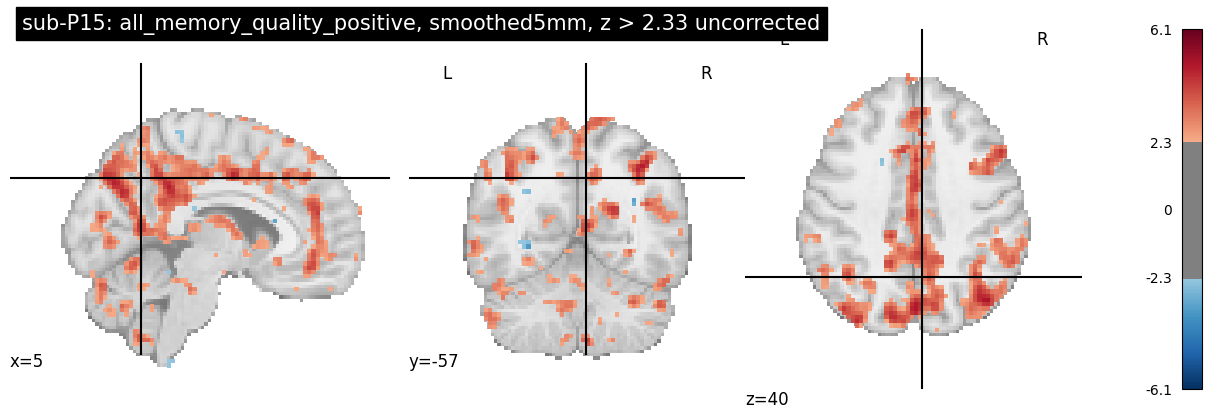

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/first_level_smoothed5mm/sub-P15_all_memory_quality_positive_smoothed5mm_uncorrected_z2.33.png


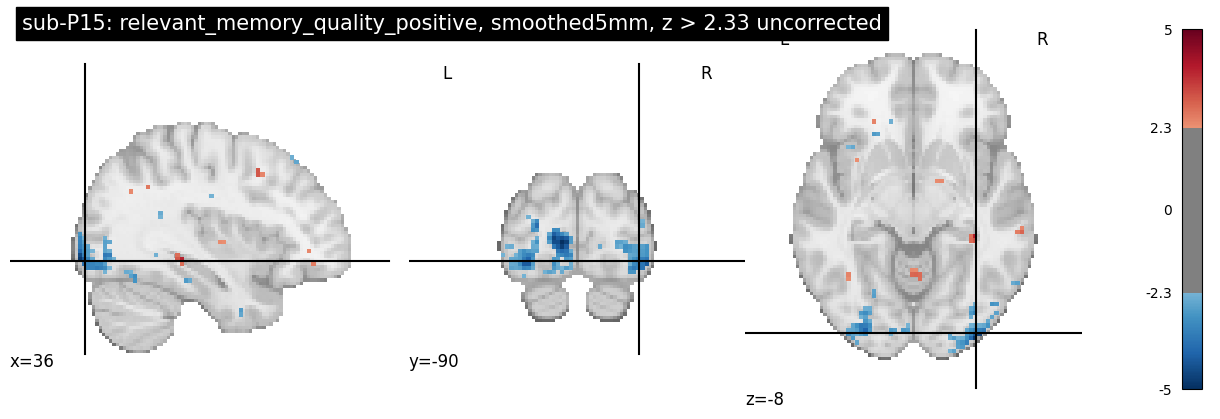

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/first_level_smoothed5mm/sub-P15_relevant_memory_quality_positive_smoothed5mm_uncorrected_z2.33.png


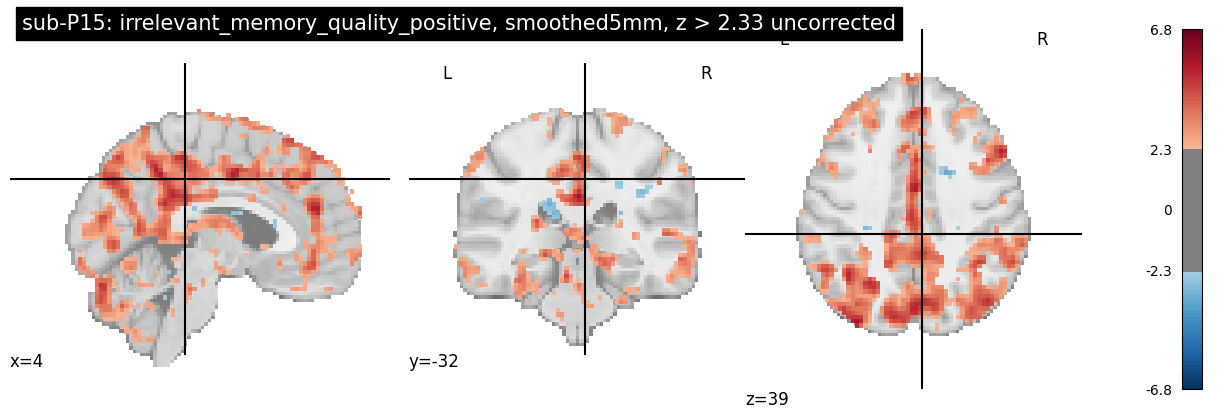

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/first_level_smoothed5mm/sub-P15_irrelevant_memory_quality_positive_smoothed5mm_uncorrected_z2.33.png


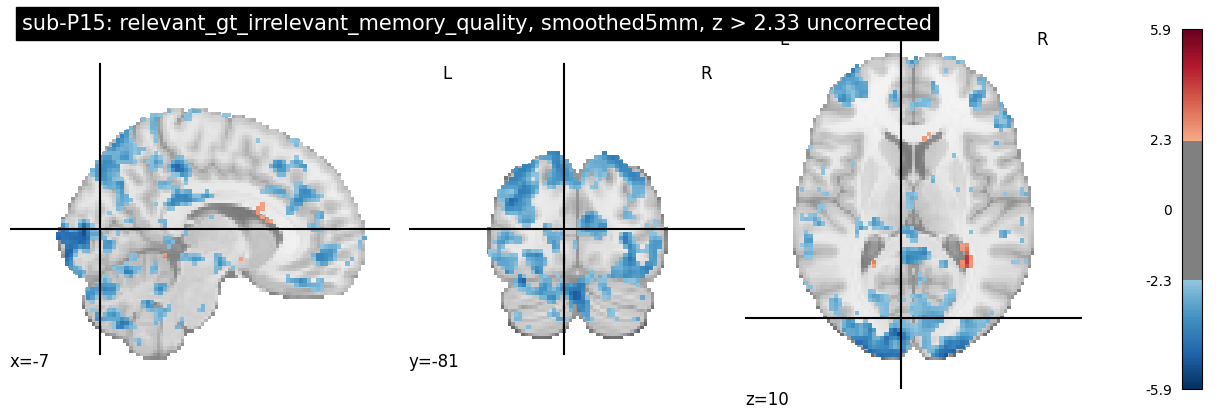

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/first_level_smoothed5mm/sub-P15_relevant_gt_irrelevant_memory_quality_smoothed5mm_uncorrected_z2.33.png


In [44]:
# ============================================================
# 40. Plot single-subject 5 mm smoothed maps
# ============================================================

EXPLORATORY_Z_THRESHOLD = 2.33

for contrast_name, outputs in single_smoothed_result["contrast_outputs"].items():
    z_map = outputs["z_map"]
    
    fig = plt.figure(figsize=(12, 4))
    
    stat_display = plot_stat_map(
        z_map,
        threshold=EXPLORATORY_Z_THRESHOLD,
        display_mode="ortho",
        cut_coords=None,
        title=(
            f"{test_smoothed_subject}: {contrast_name}, "
            f"{SMOOTHING_LABEL}, z > {EXPLORATORY_Z_THRESHOLD} uncorrected"
        ),
        figure=fig,
    )
    
    out_path = (
        FIRST_LEVEL_SMOOTHED_FIG_DIR
        / f"{test_smoothed_subject}_{contrast_name}_{SMOOTHING_LABEL}_uncorrected_z{EXPLORATORY_Z_THRESHOLD}.png"
    )
    
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    
    print("Saved:", out_path)

In [45]:
from IPython.display import display

In [46]:
# ============================================================
# 41. Run 5 mm smoothed first-level GLM for all primary subjects
# ============================================================

from datetime import datetime
import traceback

subjects_to_run_smoothed = primary_subjects_final.copy()

print("Running 5 mm smoothed first-level GLM for primary subjects")
print("=" * 80)
print("Number of subjects:", len(subjects_to_run_smoothed))
print(subjects_to_run_smoothed)

first_level_smoothed_qc_rows = []
first_level_smoothed_failures = []

for i, subject in enumerate(subjects_to_run_smoothed, start=1):
    print("\n" + "=" * 80)
    print(f"[{i}/{len(subjects_to_run_smoothed)}] Running {subject}")
    print(datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
    
    try:
        result = fit_first_level_subject_smoothed_5mm(
            subject,
            save_design=True,
            save_maps=True,
        )
        
        design_matrix = result["design_matrix"]
        event_cols = [
            col for col in design_matrix.columns
            if col.startswith("old_") or col == "new_image"
        ]
        
        row = {
            "subject": subject,
            "status": "success",
            "smoothing_fwhm_mm": SMOOTHING_FWHM,
            "n_scans": result["n_scans"],
            "tr": result["tr"],
            "n_design_columns": design_matrix.shape[1],
            "n_event_columns": len(event_cols),
            "event_columns": ";".join(event_cols),
            "has_new_image": "new_image" in design_matrix.columns,
            "has_old_relevant_memory_quality": "old_relevant_memory_quality" in design_matrix.columns,
            "has_old_irrelevant_memory_quality": "old_irrelevant_memory_quality" in design_matrix.columns,
            "has_old_relevant_valid_main": "old_relevant_valid_main" in design_matrix.columns,
            "has_old_irrelevant_valid_main": "old_irrelevant_valid_main" in design_matrix.columns,
            "has_old_seen_water_no_spatial_recall": "old_seen_water_no_spatial_recall" in design_matrix.columns,
            "has_old_other_no_memory_quality": "old_other_no_memory_quality" in design_matrix.columns,
        }
        
        for contrast_name, outputs in result["contrast_outputs"].items():
            row[f"{contrast_name}_zmap_exists"] = outputs["z_path"].exists()
            row[f"{contrast_name}_effect_exists"] = outputs["effect_path"].exists()
        
        first_level_smoothed_qc_rows.append(row)
        
        print(f"{subject}: success")
        print("Design matrix:", design_matrix.shape)
        print("Event columns:", event_cols)
        
    except Exception as exc:
        print(f"{subject}: FAILED")
        print(str(exc))
        
        first_level_smoothed_failures.append({
            "subject": subject,
            "error": str(exc),
            "traceback": traceback.format_exc(),
        })
        
        first_level_smoothed_qc_rows.append({
            "subject": subject,
            "status": "failed",
            "error": str(exc),
        })

first_level_smoothed_qc_df = pd.DataFrame(first_level_smoothed_qc_rows)
first_level_smoothed_failures_df = pd.DataFrame(first_level_smoothed_failures)

first_level_smoothed_qc_path = (
    TABLE_DIR / f"first_level_primary_glm_{SMOOTHING_LABEL}_qc.csv"
)
first_level_smoothed_failures_path = (
    TABLE_DIR / f"first_level_primary_glm_{SMOOTHING_LABEL}_failures.csv"
)

first_level_smoothed_qc_df.to_csv(first_level_smoothed_qc_path, index=False)
first_level_smoothed_failures_df.to_csv(first_level_smoothed_failures_path, index=False)

print("\n" + "=" * 80)
print("5 mm smoothed first-level GLM loop completed")
print("Successful subjects:", (first_level_smoothed_qc_df["status"] == "success").sum())
print("Failed subjects:", (first_level_smoothed_qc_df["status"] == "failed").sum())

display(first_level_smoothed_qc_df)

if len(first_level_smoothed_failures_df) > 0:
    print("\nFailures:")
    display(first_level_smoothed_failures_df)
else:
    print("\nNo failures.")

print("\nSaved:")
print(first_level_smoothed_qc_path)
print(first_level_smoothed_failures_path)

Running 5 mm smoothed first-level GLM for primary subjects
Number of subjects: 28
['sub-P10', 'sub-P12', 'sub-P13', 'sub-P14', 'sub-P15', 'sub-P16', 'sub-P17', 'sub-P18', 'sub-P19', 'sub-P21', 'sub-P22', 'sub-P23', 'sub-P25', 'sub-P27', 'sub-P31', 'sub-P34', 'sub-P35', 'sub-P36', 'sub-P37', 'sub-P41', 'sub-P42', 'sub-P43', 'sub-P44', 'sub-P45', 'sub-P47', 'sub-P48', 'sub-P50', 'sub-P51']

[1/28] Running sub-P10
2026-06-05 12:17:10
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
sub-P10: success
Design matrix: (1994, 72)
Event columns: ['new_image', 'old_irrelevant_memory_quality', 'old_irrelevant_valid_main', 'old_other_no_memory_quality', 'old_relevant_memory_quality', 'old_relevant_valid_main']

[2/28] Running sub-P12
2026-06-05 12:18:49
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
sub-P12: success
Design matrix: (1954, 71)
Event columns: ['new_image', 'old_irrelevant_memory_quality', 'old_irre

,subject,status,smoothing_fwhm_mm,n_scans,tr,n_design_columns,n_event_columns,event_columns,has_new_image,has_old_relevant_memory_quality,has_old_irrelevant_memory_quality,has_old_relevant_valid_main,has_old_irrelevant_valid_main,has_old_seen_water_no_spatial_recall,has_old_other_no_memory_quality,all_memory_quality_positive_zmap_exists,all_memory_quality_positive_effect_exists,relevant_memory_quality_positive_zmap_exists,relevant_memory_quality_positive_effect_exists,irrelevant_memory_quality_positive_zmap_exists,irrelevant_memory_quality_positive_effect_exists,relevant_gt_irrelevant_memory_quality_zmap_exists,relevant_gt_irrelevant_memory_quality_effect_exists
0,sub-P10,success,5.0,1994,1.3,72,6,new_image;old_irrelevant_memory_quality;old_ir...,True,True,True,True,True,False,True,True,True,True,True,True,True,True,True
1,sub-P12,success,5.0,1954,1.3,71,6,new_image;old_irrelevant_memory_quality;old_ir...,True,True,True,True,True,False,True,True,True,True,True,True,True,True,True
2,sub-P13,success,5.0,1957,1.3,71,6,new_image;old_irrelevant_memory_quality;old_ir...,True,True,True,True,True,False,True,True,True,True,True,True,True,True,True
3,sub-P14,success,5.0,1922,1.3,71,6,new_image;old_irrelevant_memory_quality;old_ir...,True,True,True,True,True,False,True,True,True,True,True,True,True,True,True
4,sub-P15,success,5.0,1995,1.3,72,6,new_image;old_irrelevant_memory_quality;old_ir...,True,True,True,True,True,True,False,True,True,True,True,True,True,True,True
5,sub-P16,success,5.0,1955,1.3,72,7,new_image;old_irrelevant_memory_quality;old_ir...,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
6,sub-P17,success,5.0,1946,1.3,71,6,new_image;old_irrelevant_memory_quality;old_ir...,True,True,True,True,True,False,True,True,True,True,True,True,True,True,True
7,sub-P18,success,5.0,1993,1.3,73,7,new_image;old_irrelevant_memory_quality;old_ir...,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
8,sub-P19,success,5.0,1945,1.3,72,7,new_image;old_irrelevant_memory_quality;old_ir...,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
9,sub-P21,success,5.0,1961,1.3,72,7,new_image;old_irrelevant_memory_quality;old_ir...,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True



No failures.

Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/first_level_primary_glm_smoothed5mm_qc.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/first_level_primary_glm_smoothed5mm_failures.csv


In [47]:
# ============================================================
# 42. Verify 5 mm smoothed first-level contrast map availability
# ============================================================

map_check_rows = []

for subject in primary_subjects_final:
    for contrast_name in PRIMARY_CONTRASTS.keys():
        z_path = (
            FIRST_LEVEL_SMOOTHED_MAPS_DIR
            / f"{subject}_{contrast_name}_{SMOOTHING_LABEL}_zmap.nii.gz"
        )
        effect_path = (
            FIRST_LEVEL_SMOOTHED_MAPS_DIR
            / f"{subject}_{contrast_name}_{SMOOTHING_LABEL}_effect.nii.gz"
        )
        
        map_check_rows.append({
            "subject": subject,
            "contrast": contrast_name,
            "smoothing_fwhm_mm": SMOOTHING_FWHM,
            "z_map_exists": z_path.exists(),
            "effect_map_exists": effect_path.exists(),
            "z_map_path": str(z_path),
            "effect_map_path": str(effect_path),
        })

first_level_smoothed_map_check = pd.DataFrame(map_check_rows)

print("5 mm smoothed first-level map availability:")
display(
    first_level_smoothed_map_check
    .groupby("contrast")
    .agg(
        n_subjects=("subject", "count"),
        n_z_maps=("z_map_exists", "sum"),
        n_effect_maps=("effect_map_exists", "sum"),
    )
    .reset_index()
)

missing_smoothed_maps = first_level_smoothed_map_check.loc[
    (~first_level_smoothed_map_check["z_map_exists"])
    | (~first_level_smoothed_map_check["effect_map_exists"])
].copy()

print("\nMissing smoothed maps:")
display(missing_smoothed_maps)

map_check_path = (
    TABLE_DIR / f"first_level_primary_glm_{SMOOTHING_LABEL}_map_availability.csv"
)
first_level_smoothed_map_check.to_csv(map_check_path, index=False)

print("\nSaved:")
print(map_check_path)

5 mm smoothed first-level map availability:


,contrast,n_subjects,n_z_maps,n_effect_maps
0,all_memory_quality_positive,28,28,28
1,irrelevant_memory_quality_positive,28,28,28
2,relevant_gt_irrelevant_memory_quality,28,28,28
3,relevant_memory_quality_positive,28,28,28



Missing smoothed maps:


,subject,contrast,smoothing_fwhm_mm,z_map_exists,effect_map_exists,z_map_path,effect_map_path



Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/first_level_primary_glm_smoothed5mm_map_availability.csv


In [48]:
# ============================================================
# 43. Define second-level helpers for 5 mm smoothed first-level maps
# ============================================================

SECOND_LEVEL_FROM_SMOOTHED_DIR = OUT_DIR / f"second_level_from_{SMOOTHING_LABEL}"
SECOND_LEVEL_FROM_SMOOTHED_MAPS_DIR = SECOND_LEVEL_FROM_SMOOTHED_DIR / "maps"
SECOND_LEVEL_FROM_SMOOTHED_FIG_DIR = FIG_DIR / f"second_level_from_{SMOOTHING_LABEL}"

for path in [
    SECOND_LEVEL_FROM_SMOOTHED_DIR,
    SECOND_LEVEL_FROM_SMOOTHED_MAPS_DIR,
    SECOND_LEVEL_FROM_SMOOTHED_FIG_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)


def get_smoothed_first_level_effect_map(subject, contrast_name):
    return (
        FIRST_LEVEL_SMOOTHED_MAPS_DIR
        / f"{subject}_{contrast_name}_{SMOOTHING_LABEL}_effect.nii.gz"
    )


def get_smoothed_first_level_z_map(subject, contrast_name):
    return (
        FIRST_LEVEL_SMOOTHED_MAPS_DIR
        / f"{subject}_{contrast_name}_{SMOOTHING_LABEL}_zmap.nii.gz"
    )


def load_second_level_inputs_from_smoothed_first_level(subjects, contrast_name):
    map_paths = []
    missing = []
    
    for subject in subjects:
        path = get_smoothed_first_level_effect_map(subject, contrast_name)
        
        if path.exists():
            map_paths.append(str(path))
        else:
            missing.append((subject, str(path)))
    
    if len(missing) > 0:
        raise FileNotFoundError(f"Missing smoothed first-level maps for {contrast_name}: {missing}")
    
    design_matrix = pd.DataFrame(
        {"intercept": np.ones(len(map_paths))}
    )
    
    return map_paths, design_matrix


def fit_second_level_from_smoothed_first_level(subjects, contrast_name):
    """
    Second-level one-sample test using 5 mm smoothed first-level effect maps.
    
    No additional second-level smoothing is applied here, because smoothing was
    already applied at first level.
    """
    map_paths, design_matrix = load_second_level_inputs_from_smoothed_first_level(
        subjects=subjects,
        contrast_name=contrast_name,
    )
    
    second_level_model = SecondLevelModel(
        smoothing_fwhm=None,
        n_jobs=1,
    )
    
    second_level_model = second_level_model.fit(
        second_level_input=map_paths,
        design_matrix=design_matrix,
    )
    
    z_map = second_level_model.compute_contrast(
        second_level_contrast="intercept",
        output_type="z_score",
    )
    
    effect_map = second_level_model.compute_contrast(
        second_level_contrast="intercept",
        output_type="effect_size",
    )
    
    return {
        "contrast_name": contrast_name,
        "subjects": subjects,
        "map_paths": map_paths,
        "design_matrix": design_matrix,
        "model": second_level_model,
        "z_map": z_map,
        "effect_map": effect_map,
    }


print("Second-level helpers for 5 mm smoothed first-level maps ready.")
print("Output directory:")
print(SECOND_LEVEL_FROM_SMOOTHED_DIR)

Second-level helpers for 5 mm smoothed first-level maps ready.
Output directory:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/second_level_from_smoothed5mm


In [49]:
# ============================================================
# 44. Run second-level GLM from 5 mm smoothed first-level maps
# ============================================================

second_level_from_smoothed_results = {}
second_level_from_smoothed_qc_rows = []

print("Running second-level GLM from 5 mm smoothed first-level maps")
print("=" * 80)
print("Subjects:", len(primary_subjects_final))

for contrast_name in PRIMARY_CONTRASTS.keys():
    print("\n" + "=" * 80)
    print("Second-level contrast:", contrast_name)
    
    result = fit_second_level_from_smoothed_first_level(
        subjects=primary_subjects_final.copy(),
        contrast_name=contrast_name,
    )
    
    z_path = (
        SECOND_LEVEL_FROM_SMOOTHED_MAPS_DIR
        / f"group_primary_{contrast_name}_from_{SMOOTHING_LABEL}_zmap.nii.gz"
    )
    effect_path = (
        SECOND_LEVEL_FROM_SMOOTHED_MAPS_DIR
        / f"group_primary_{contrast_name}_from_{SMOOTHING_LABEL}_effect.nii.gz"
    )
    
    result["z_map"].to_filename(z_path)
    result["effect_map"].to_filename(effect_path)
    
    second_level_from_smoothed_results[contrast_name] = result
    
    second_level_from_smoothed_qc_rows.append({
        "contrast": contrast_name,
        "n_subjects": len(primary_subjects_final),
        "input_map_type": "first_level_effect_size",
        "first_level_smoothing_fwhm_mm": SMOOTHING_FWHM,
        "second_level_smoothing_fwhm_mm": None,
        "z_map_path": str(z_path),
        "effect_map_path": str(effect_path),
        "z_map_exists": z_path.exists(),
        "effect_map_exists": effect_path.exists(),
    })
    
    print("Saved:")
    print("  z-map:     ", z_path)
    print("  effect-map:", effect_path)

second_level_from_smoothed_qc_df = pd.DataFrame(second_level_from_smoothed_qc_rows)

second_level_from_smoothed_qc_path = (
    TABLE_DIR / f"second_level_primary_glm_from_{SMOOTHING_LABEL}_qc.csv"
)
second_level_from_smoothed_qc_df.to_csv(second_level_from_smoothed_qc_path, index=False)

print("\nSecond-level from smoothed first-level QC:")
display(second_level_from_smoothed_qc_df)

print("\nSaved:")
print(second_level_from_smoothed_qc_path)

Running second-level GLM from 5 mm smoothed first-level maps
Subjects: 28

Second-level contrast: all_memory_quality_positive
Saved:
  z-map:      /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/second_level_from_smoothed5mm/maps/group_primary_all_memory_quality_positive_from_smoothed5mm_zmap.nii.gz
  effect-map: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/second_level_from_smoothed5mm/maps/group_primary_all_memory_quality_positive_from_smoothed5mm_effect.nii.gz

Second-level contrast: relevant_memory_quality_positive
Saved:
  z-map:      /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/second_level_from_smoothed5mm/maps/group_primary_relevant_memory_quality_positive_from_smoothed5mm_zmap.nii.gz
  effect-map: /media/RCPNAS/Data3/Alison_island/kroczak/island_s

,contrast,n_subjects,input_map_type,first_level_smoothing_fwhm_mm,second_level_smoothing_fwhm_mm,z_map_path,effect_map_path,z_map_exists,effect_map_exists
0,all_memory_quality_positive,28,first_level_effect_size,5.0,None,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True
1,relevant_memory_quality_positive,28,first_level_effect_size,5.0,None,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True
2,irrelevant_memory_quality_positive,28,first_level_effect_size,5.0,None,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True
3,relevant_gt_irrelevant_memory_quality,28,first_level_effect_size,5.0,None,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True



Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/second_level_primary_glm_from_smoothed5mm_qc.csv


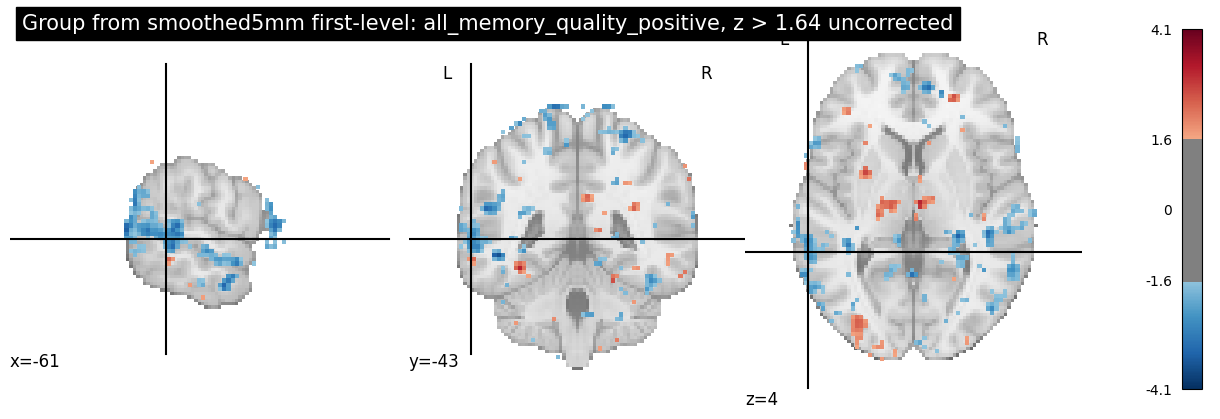

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/second_level_from_smoothed5mm/group_primary_all_memory_quality_positive_from_smoothed5mm_uncorrected_z1.64.png


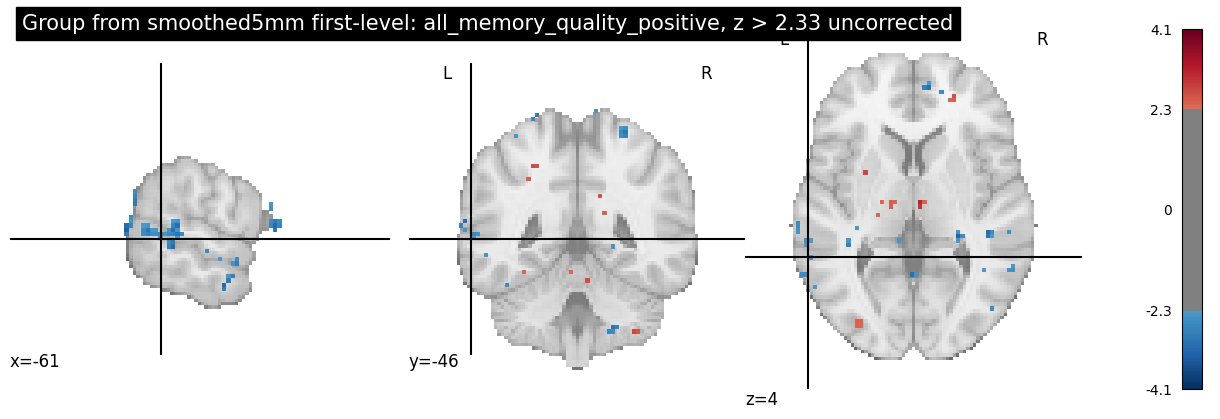

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/second_level_from_smoothed5mm/group_primary_all_memory_quality_positive_from_smoothed5mm_uncorrected_z2.33.png


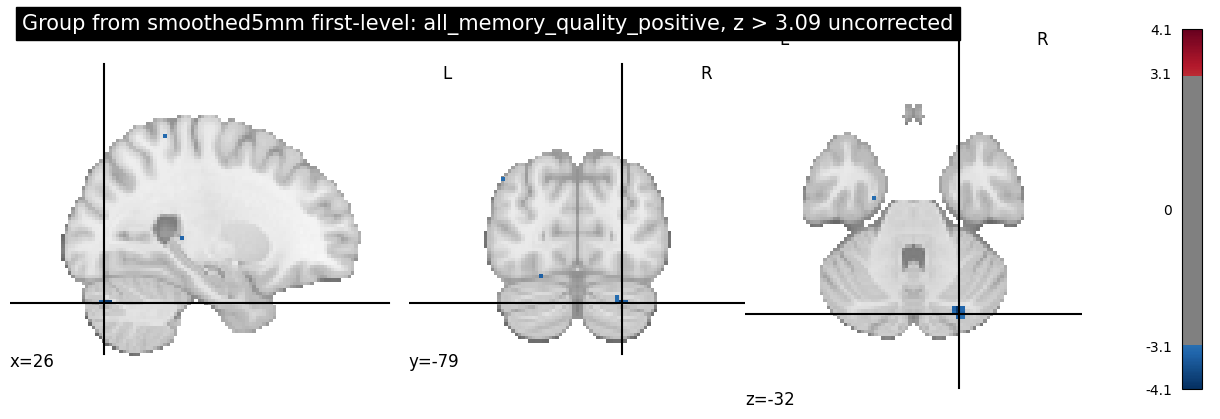

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/second_level_from_smoothed5mm/group_primary_all_memory_quality_positive_from_smoothed5mm_uncorrected_z3.09.png


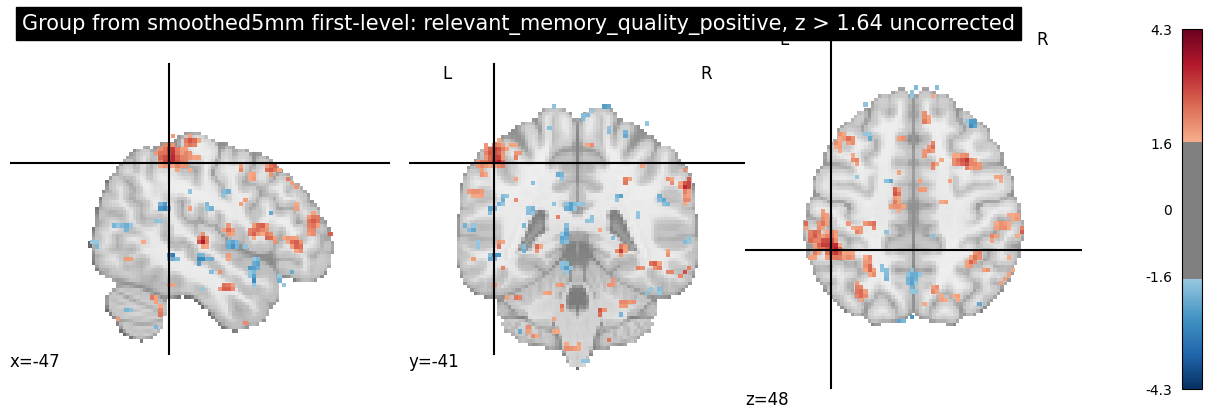

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/second_level_from_smoothed5mm/group_primary_relevant_memory_quality_positive_from_smoothed5mm_uncorrected_z1.64.png


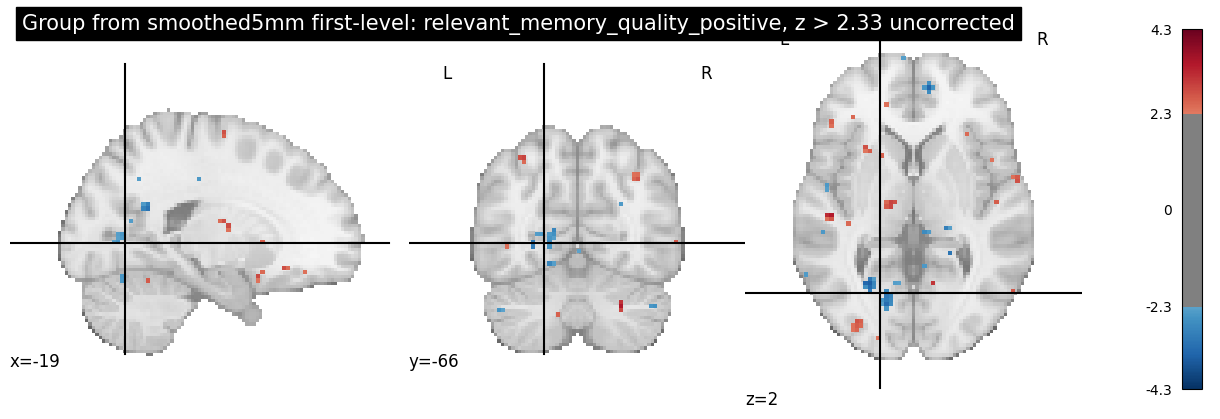

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/second_level_from_smoothed5mm/group_primary_relevant_memory_quality_positive_from_smoothed5mm_uncorrected_z2.33.png


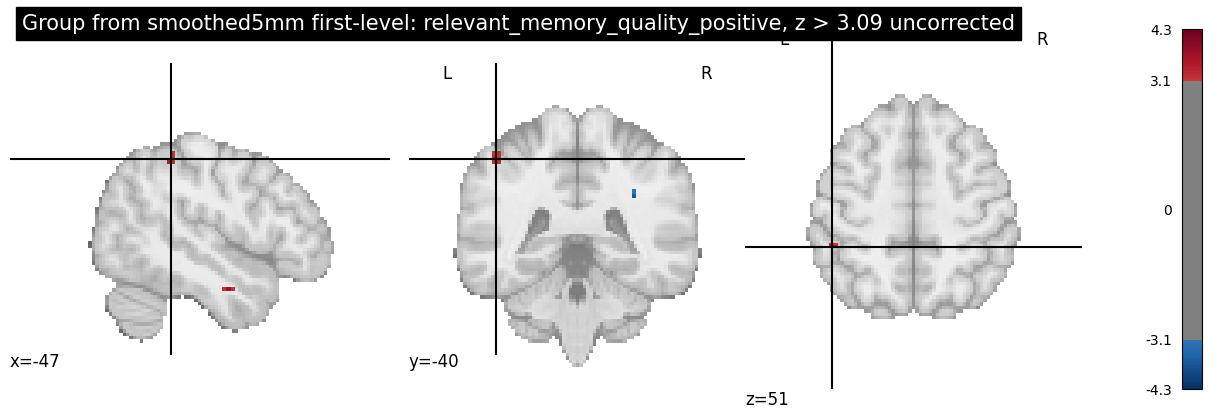

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/second_level_from_smoothed5mm/group_primary_relevant_memory_quality_positive_from_smoothed5mm_uncorrected_z3.09.png


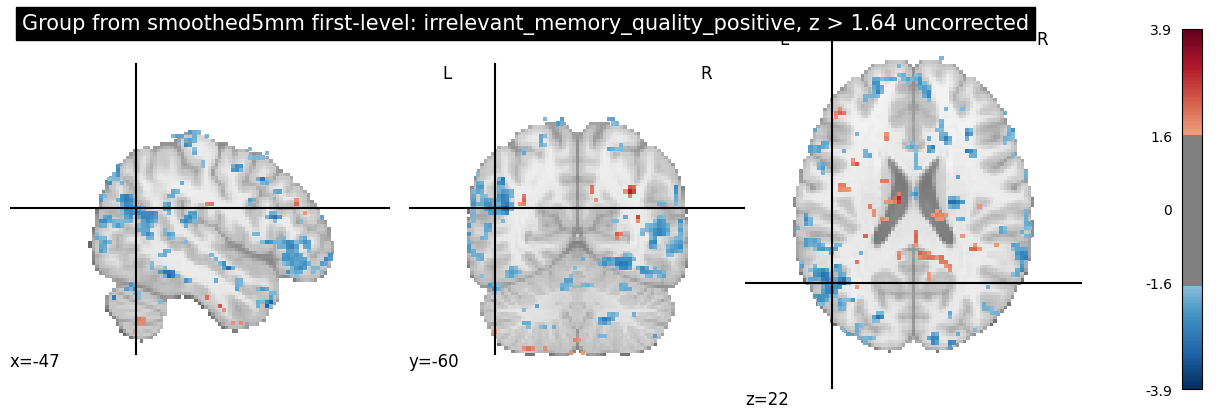

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/second_level_from_smoothed5mm/group_primary_irrelevant_memory_quality_positive_from_smoothed5mm_uncorrected_z1.64.png


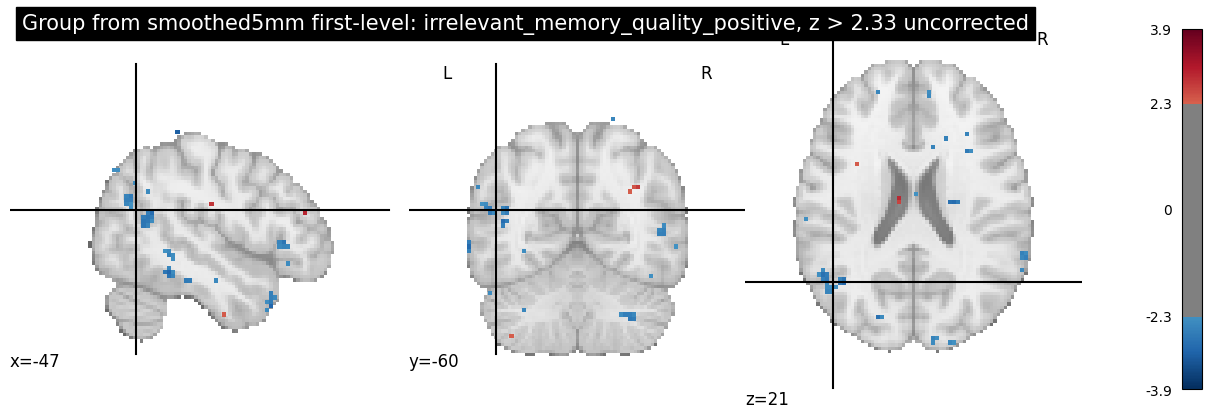

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/second_level_from_smoothed5mm/group_primary_irrelevant_memory_quality_positive_from_smoothed5mm_uncorrected_z2.33.png


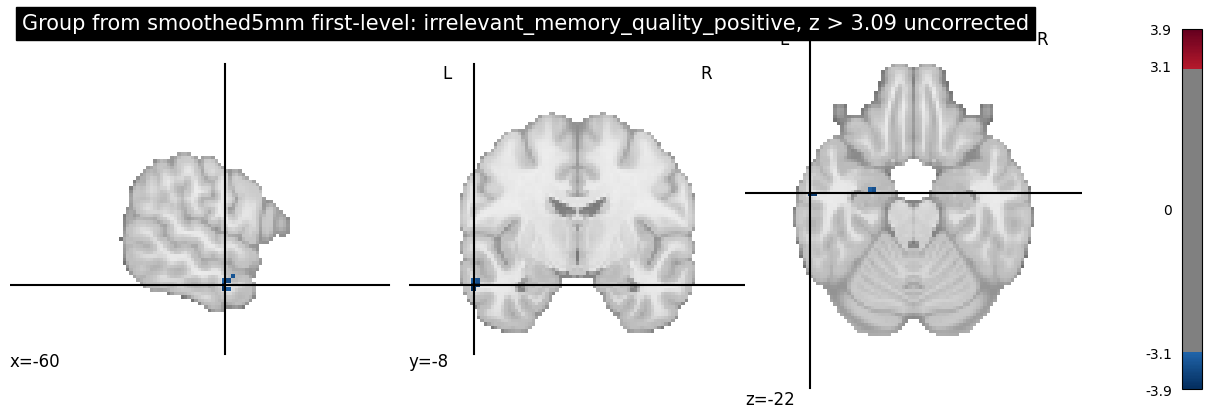

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/second_level_from_smoothed5mm/group_primary_irrelevant_memory_quality_positive_from_smoothed5mm_uncorrected_z3.09.png


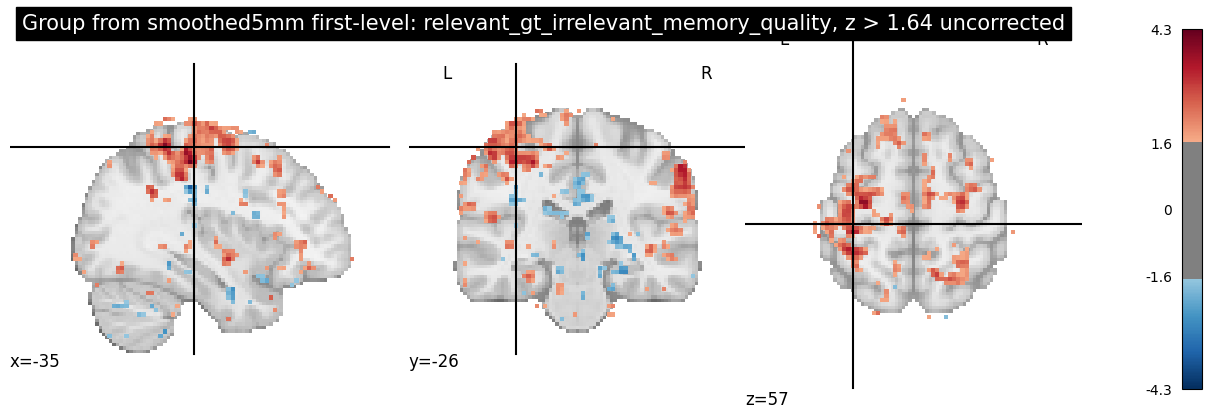

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/second_level_from_smoothed5mm/group_primary_relevant_gt_irrelevant_memory_quality_from_smoothed5mm_uncorrected_z1.64.png


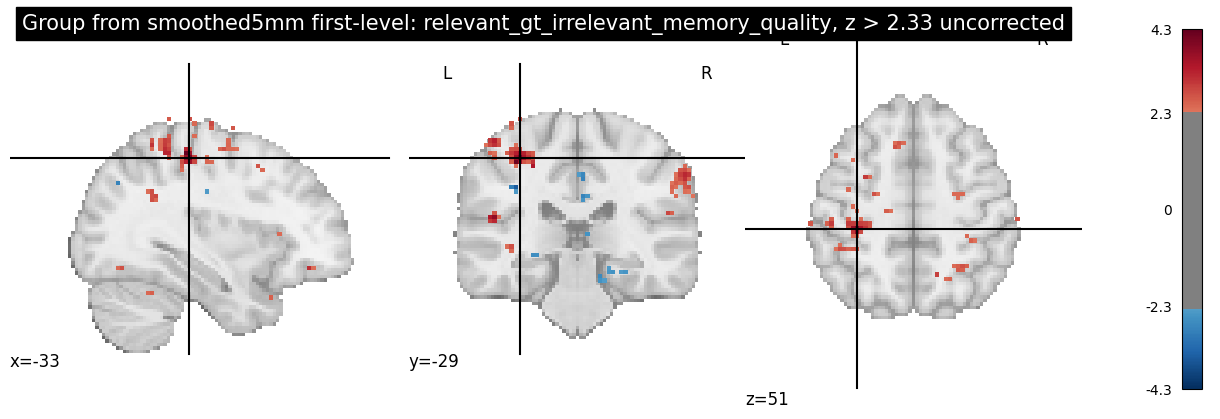

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/second_level_from_smoothed5mm/group_primary_relevant_gt_irrelevant_memory_quality_from_smoothed5mm_uncorrected_z2.33.png


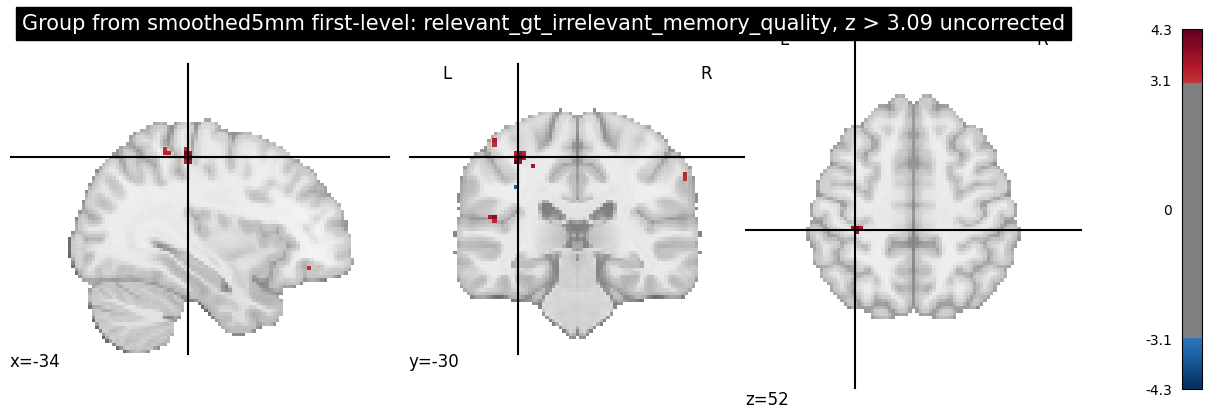

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/figures/second_level_from_smoothed5mm/group_primary_relevant_gt_irrelevant_memory_quality_from_smoothed5mm_uncorrected_z3.09.png


In [50]:
# ============================================================
# 45. Plot group maps from 5 mm smoothed first-level GLM
# ============================================================

EXPLORATORY_GROUP_THRESHOLDS = [1.64, 2.33, 3.09]

for contrast_name, result in second_level_from_smoothed_results.items():
    z_map = result["z_map"]
    
    for z_threshold in EXPLORATORY_GROUP_THRESHOLDS:
        fig = plt.figure(figsize=(12, 4))
        
        stat_display = plot_stat_map(
            z_map,
            threshold=z_threshold,
            display_mode="ortho",
            cut_coords=None,
            title=(
                f"Group from {SMOOTHING_LABEL} first-level: "
                f"{contrast_name}, z > {z_threshold} uncorrected"
            ),
            figure=fig,
        )
        
        out_path = (
            SECOND_LEVEL_FROM_SMOOTHED_FIG_DIR
            / f"group_primary_{contrast_name}_from_{SMOOTHING_LABEL}_uncorrected_z{z_threshold}.png"
        )
        
        fig.savefig(out_path, dpi=200, bbox_inches="tight")
        plt.show()
        
        print("Saved:", out_path)

In [51]:
# ============================================================
# 46. Cluster tables for group maps from 5 mm smoothed first-level GLM
# ============================================================

from nilearn.reporting import get_clusters_table

SMOOTHED_FIRST_LEVEL_CLUSTER_Z_THRESHOLD = 2.33
SMOOTHED_FIRST_LEVEL_CLUSTER_EXTENT_THRESHOLD = 10
SMOOTHED_FIRST_LEVEL_CLUSTER_MIN_DISTANCE = 8

smoothed_first_level_cluster_rows = []

for contrast_name, result in second_level_from_smoothed_results.items():
    z_map = result["z_map"]
    
    try:
        cluster_table = get_clusters_table(
            stat_img=z_map,
            stat_threshold=SMOOTHED_FIRST_LEVEL_CLUSTER_Z_THRESHOLD,
            cluster_threshold=SMOOTHED_FIRST_LEVEL_CLUSTER_EXTENT_THRESHOLD,
            min_distance=SMOOTHED_FIRST_LEVEL_CLUSTER_MIN_DISTANCE,
        )
        
        cluster_table["contrast"] = contrast_name
        cluster_table["z_threshold"] = SMOOTHED_FIRST_LEVEL_CLUSTER_Z_THRESHOLD
        cluster_table["cluster_extent_threshold_voxels"] = SMOOTHED_FIRST_LEVEL_CLUSTER_EXTENT_THRESHOLD
        cluster_table["first_level_smoothing_fwhm_mm"] = SMOOTHING_FWHM
        
        cluster_table_path = (
            TABLE_DIR
            / (
                f"second_level_from_{SMOOTHING_LABEL}_cluster_table_"
                f"{contrast_name}_z{SMOOTHED_FIRST_LEVEL_CLUSTER_Z_THRESHOLD}_"
                f"k{SMOOTHED_FIRST_LEVEL_CLUSTER_EXTENT_THRESHOLD}.csv"
            )
        )
        cluster_table.to_csv(cluster_table_path, index=False)
        
        print("\n" + "=" * 80)
        print(
            f"Cluster table from {SMOOTHING_LABEL}: {contrast_name}, "
            f"z > {SMOOTHED_FIRST_LEVEL_CLUSTER_Z_THRESHOLD}, "
            f"k >= {SMOOTHED_FIRST_LEVEL_CLUSTER_EXTENT_THRESHOLD} voxels"
        )
        display(cluster_table.head(20))
        print("Saved:", cluster_table_path)
        
        smoothed_first_level_cluster_rows.append({
            "contrast": contrast_name,
            "first_level_smoothing_fwhm_mm": SMOOTHING_FWHM,
            "z_threshold": SMOOTHED_FIRST_LEVEL_CLUSTER_Z_THRESHOLD,
            "cluster_extent_threshold_voxels": SMOOTHED_FIRST_LEVEL_CLUSTER_EXTENT_THRESHOLD,
            "n_peaks_or_clusters": len(cluster_table),
            "cluster_table_path": str(cluster_table_path),
        })
    
    except Exception as exc:
        print(f"Could not create cluster table for {contrast_name}: {exc}")
        smoothed_first_level_cluster_rows.append({
            "contrast": contrast_name,
            "first_level_smoothing_fwhm_mm": SMOOTHING_FWHM,
            "z_threshold": SMOOTHED_FIRST_LEVEL_CLUSTER_Z_THRESHOLD,
            "cluster_extent_threshold_voxels": SMOOTHED_FIRST_LEVEL_CLUSTER_EXTENT_THRESHOLD,
            "n_peaks_or_clusters": np.nan,
            "cluster_table_path": None,
            "error": str(exc),
        })

smoothed_first_level_cluster_summary_df = pd.DataFrame(smoothed_first_level_cluster_rows)

smoothed_first_level_cluster_summary_path = (
    TABLE_DIR / f"second_level_from_{SMOOTHING_LABEL}_cluster_table_summary.csv"
)
smoothed_first_level_cluster_summary_df.to_csv(
    smoothed_first_level_cluster_summary_path,
    index=False,
)

print("\nCluster table summary from 5 mm smoothed first-level GLM:")
display(smoothed_first_level_cluster_summary_df)

print("\nSaved:")
print(smoothed_first_level_cluster_summary_path)


Cluster table from smoothed5mm: all_memory_quality_positive, z > 2.33, k >= 10 voxels


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),contrast,z_threshold,cluster_extent_threshold_voxels,first_level_smoothing_fwhm_mm
0,1,6.5,-27.0,27.0,3.637435,281,all_memory_quality_positive,2.33,10,5.0
1,2,-38.5,-52.0,39.5,3.622403,296,all_memory_quality_positive,2.33,10,5.0
2,3,46.5,-32.0,-8.0,3.588984,218,all_memory_quality_positive,2.33,10,5.0
3,4,16.5,-22.0,9.5,3.539212,281,all_memory_quality_positive,2.33,10,5.0
4,5,-13.5,-14.5,-0.5,3.493516,296,all_memory_quality_positive,2.33,10,5.0
5,6,26.5,3.0,-8.0,2.956750,296,all_memory_quality_positive,2.33,10,5.0
6,6a,31.5,3.0,-0.5,2.797085,,all_memory_quality_positive,2.33,10,5.0
7,7,-28.5,3.0,7.0,2.875363,171,all_memory_quality_positive,2.33,10,5.0


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/second_level_from_smoothed5mm_cluster_table_all_memory_quality_positive_z2.33_k10.csv

Cluster table from smoothed5mm: relevant_memory_quality_positive, z > 2.33, k >= 10 voxels


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),contrast,z_threshold,cluster_extent_threshold_voxels,first_level_smoothing_fwhm_mm
0,1,14.0,-14.5,32.0,4.343043,156,relevant_memory_quality_positive,2.33,10,5.0
1,2,66.5,-44.5,34.5,3.944574,187,relevant_memory_quality_positive,2.33,10,5.0
2,3,-46.0,-7.0,-25.5,3.667358,156,relevant_memory_quality_positive,2.33,10,5.0
3,4,-41.0,-12.0,64.5,3.635385,171,relevant_memory_quality_positive,2.33,10,5.0
4,5,-28.5,18.0,4.5,3.461787,328,relevant_memory_quality_positive,2.33,10,5.0
5,6,-31.0,-12.0,57.0,3.409115,203,relevant_memory_quality_positive,2.33,10,5.0
6,7,-46.0,-42.0,49.5,3.395379,1031,relevant_memory_quality_positive,2.33,10,5.0
7,7a,-56.0,-37.0,54.5,3.059408,,relevant_memory_quality_positive,2.33,10,5.0
8,8,61.5,-27.0,42.0,3.321878,640,relevant_memory_quality_positive,2.33,10,5.0
9,8a,66.5,-34.5,34.5,2.900794,,relevant_memory_quality_positive,2.33,10,5.0


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/second_level_from_smoothed5mm_cluster_table_relevant_memory_quality_positive_z2.33_k10.csv

Cluster table from smoothed5mm: irrelevant_memory_quality_positive, z > 2.33, k >= 10 voxels


...

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/second_level_from_smoothed5mm_cluster_table_irrelevant_memory_quality_positive_z2.33_k10.csv

Cluster table from smoothed5mm: relevant_gt_irrelevant_memory_quality, z > 2.33, k >= 10 voxels


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),contrast,z_threshold,cluster_extent_threshold_voxels,first_level_smoothing_fwhm_mm
0,1,-33.5,-32.0,54.5,4.268709,3531,relevant_gt_irrelevant_memory_quality,2.33,10,5.0
1,1a,-28.5,-14.5,59.5,3.908293,,relevant_gt_irrelevant_memory_quality,2.33,10,5.0
2,1b,-38.5,-12.0,64.5,3.608744,,relevant_gt_irrelevant_memory_quality,2.33,10,5.0
3,1c,-26.0,-9.5,59.5,3.500761,,relevant_gt_irrelevant_memory_quality,2.33,10,5.0
4,2,26.5,5.5,-23.0,4.127168,421,relevant_gt_irrelevant_memory_quality,2.33,10,5.0
5,3,-36.0,-44.5,59.5,3.922052,1390,relevant_gt_irrelevant_memory_quality,2.33,10,5.0
6,3a,-28.5,-52.0,69.5,2.717606,,relevant_gt_irrelevant_memory_quality,2.33,10,5.0
7,3b,-26.0,-49.5,62.0,2.631239,,relevant_gt_irrelevant_memory_quality,2.33,10,5.0
8,4,-41.0,-62.0,19.5,3.910846,359,relevant_gt_irrelevant_memory_quality,2.33,10,5.0
9,5,-48.5,-29.5,17.0,3.794616,187,relevant_gt_irrelevant_memory_quality,2.33,10,5.0


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/second_level_from_smoothed5mm_cluster_table_relevant_gt_irrelevant_memory_quality_z2.33_k10.csv

Cluster table summary from 5 mm smoothed first-level GLM:


,contrast,first_level_smoothing_fwhm_mm,z_threshold,cluster_extent_threshold_voxels,n_peaks_or_clusters,cluster_table_path
0,all_memory_quality_positive,5.0,2.33,10,8,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
1,relevant_memory_quality_positive,5.0,2.33,10,18,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
2,irrelevant_memory_quality_positive,5.0,2.33,10,4,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
3,relevant_gt_irrelevant_memory_quality,5.0,2.33,10,55,/media/RCPNAS/Data3/Alison_island/kroczak/isla...



Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/second_level_from_smoothed5mm_cluster_table_summary.csv


### Exploratory whole-brain result: relevance modulation of memory-quality effects

The interaction contrast tested whether the trial-by-trial memory-quality effect was stronger for goal-relevant than goal-irrelevant images:

$$
C_{\text{relevant > irrelevant MQ}}
=
\beta_{\text{relevant MQ}}
-
\beta_{\text{irrelevant MQ}}
$$

At the exploratory uncorrected threshold \(z > 2.33\), this contrast produced the most spatially coherent whole-brain pattern among the primary contrasts. The strongest cluster was located in a left dorsal fronto-parietal region, with a peak at approximately \(x=-33.5, y=-32.0, z=54.5\). Additional clusters were observed in dorsal frontal/parietal and ventral anterior regions.

This suggests that the neural expression of memory quality during post-viewing may be stronger for goal-relevant than goal-irrelevant images. In other words, images that were behaviorally remembered with higher quality elicited stronger post-viewing activity particularly when they had been relevant to the participant's navigation goals.

Because these results are whole-brain and uncorrected, they are interpreted as exploratory. The hippocampal hypothesis will be tested directly using an a priori hippocampal ROI.